<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px; box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  <!-- Logo UNISON - Derecha -->
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  <!-- Imagen Izquierda -->
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  <!-- Título centrado -->
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">04</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Estrategias Evolutivas: Cuando el algoritmo aprende a mutar</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">De la representación binaria a la autoadaptación en espacios continuos</p>
    </div>
  </div>
  
<div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4 style="color: #24398A; margin-top: 0;"><strong>Presentación general</strong></h4>
    <p style="line-height: 1.7; color: #333;">
    Los algoritmos genéticos fueron, durante los años 90, la cara más visible de la computación evolutiva. Su intuición era poderosa y accesible: codificar soluciones como cromosomas, combinarlas con cruza y mutación, dejar que la selección natural hiciera el resto. Durante esa época dorada atrajeron una enorme atención académica e industrial, y siguen siendo una entrada natural al campo.
    </p>
    <p style="line-height: 1.7; color: #333;">
    Pero casi al mismo tiempo, en los laboratorios de ingeniería aeronáutica alemana de los años 60, nacía una familia de algoritmos con una pregunta diferente: ¿qué pasa si los propios parámetros que controlan la variación también evolucionan? Esa pregunta dio origen a las <strong>Estrategias Evolutivas (EE)</strong>—menos conocidas en su momento, pero que con el tiempo se han convertido en el estado del arte para optimización continua sin gradiente.
    </p>
  </div>
</div>

<div style="padding: 15px 20px; background-color: #f8f9fa; margin: 20px 0;">
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0 0 15px 0;">
        En la lección anterior construimos el AGS desde sus cimientos: representación binaria, selección por torneo, cruza de un punto, mutación por flip de bits. Lo aplicamos a Schwefel y a una función multimodal bidimensional y vimos que, pese a su simplicidad, logra aproximarse al óptimo global. También vimos su limitación central: los parámetros de variación son fijos. El algoritmo no aprende de su propio comportamiento.
    </p>
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0;">
        Las <strong>Estrategias Evolutivas</strong> presentan una alternativa a la computación evolutiv. La diferencia central es una sola, pero es profunda: en los algoritmos genéticos la intensidad de la mutación es fija, elegida por el diseñador antes de correr el algoritmo. Las EE hacen que esa intensidad sea parte del cromosoma y la dejan evolucionar junto con las variables del problema. El resultado es un algoritmo que <em>aprende a mutar mientras optimiza</em>. Esta lección recorre ese camino completo: desde la geometría de la mutación gaussiana y la autoadaptación lognormal, hasta CMA-ES—el algoritmo que hoy domina los benchmarks de optimización continua.
    </p>
</div>

In [1]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# Configuración estética
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

# Reproducibilidad
rng = np.random.default_rng(42)

print("Librerías cargadas exitosamente.\n")

Librerías cargadas exitosamente.



## 1. Del AGS a las EE

El AGS y las Estrategias Evolutivas comparten la misma estructura de alto nivel: inicializar una población, evaluar aptitud, seleccionar, variar, repetir. Pero difieren en casi todas las decisiones de diseño concretas. La siguiente tabla sitúa exactamente dónde.

| Aspecto | AGS (lección anterior) | Estrategias Evolutivas |
|---|---|---|
| **Representación** | Cadena binaria (genotipo → fenotipo) | Vector real de variables + vector de σ |
| **Espacio natural** | Discreto / combinatorio | Continuo, espacios de alta dimensión |
| **Variación principal** | Cruza de un punto + flip de bits | Mutación gaussiana $x' = x + \mathcal{N}(0, \sigma^2 I)$ |
| **Parámetros de variación** | Fijos (diseñados a priori) | **Evolucionan junto con las variables** |
| **Selección** | Torneo probabilístico | Determinista: los μ mejores de λ hijos |
| **Elitismo** | Opcional | Estructural: notación **(μ+λ)** o **(μ,λ)** |
| **Garantías teóricas** | Esquema de Holland (bloques de construcción) | Regla de 1/5, convergencia en esfera |
| **Caso de uso típico** | Problemas discretos, combinatorios, binarios | Optimización continua, ingeniería, calibración |

<br>

La diferencia clave está en el nivel más fundamental de la representación: el cromosoma de una EE tiene **dos capas**:

$$\text{individuo} = (\underbrace{x_1, x_2, \ldots, x_n}_{\text{variables del problema}}, \underbrace{\sigma_1, \sigma_2, \ldots, \sigma_n}_{\text{parámetros de estrategia}})$$

Los $x_i$ son la solución. Los $\sigma_i$ son instrucciones sobre *cómo mutar* esa solución. Ambos evolucionan simultáneamente.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Intuición central:</strong> En el AGS fijamos σ antes de correr el algoritmo, igual que un cocinero que decide de antemano cuánta sal usar en todos los platos. Las EE dejan que σ evolucione: el algoritmo prueba distintas intensidades de mutación y conserva las que producen mejores resultados. El algoritmo aprende a sazonar mientras cocina.
</div>

### El problema de σ fija

Observemos más de cerca lo que le ocurre a un optimizador con σ fija cuando el paisaje tiene zonas de distinta rugosidad. Para ello utilicemos un AGS sobre la función de Rosenbrock en 2D:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

<p align="center">
  <img src="images/rosenbrock_function.png" width="800">
</p>


Esta función tiene un valle curvo y estrecho que lleva al óptimo en $(1, 1)$. En esta imagen, a la izquierda (3D) se muestra la superficie en escala logarítmica para que tanto el fondo del valle como las paredes empinadas sean visibles a la vez. La línea dorada traza el valle $y=x^2$; el punto turquesa marca el único óptimo global en $(1,1)$. A la derecha, se muestra la vista que suele utilizarse para visualizar trayectorias de búsqueda. Las curvas muy juntas describen un gradiente fuerte (paredes); las curvas separadas alrededor de $(1,1)$ representan un fondo casi plano. Las tres anotaciones señalan los tres comportamientos problemáticos con σ fija: paredes empinadas (rebotes), curvatura del valle (dirección cambiante), y fondo plano (convergencia lenta). En ese valle, un σ grande salta por encima del fondo; un σ pequeño avanza demasiado lento en la entrada del valle.

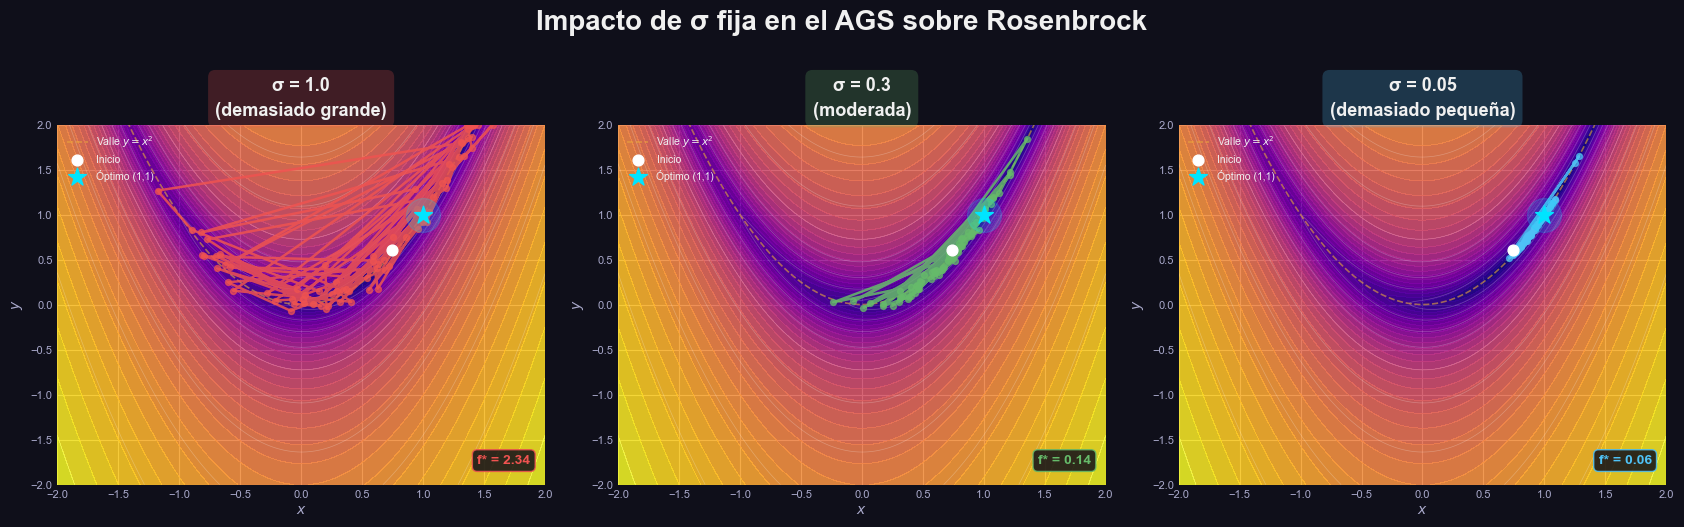

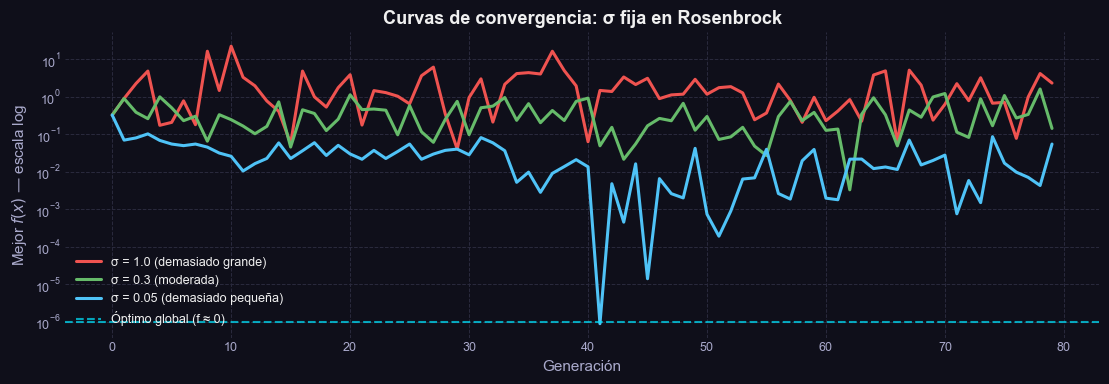

In [2]:
# ════════════════════════════════════════════════════════════════════════
# PROBLEMA DE σ FIJA EN ROSENBROCK
# ════════════════════════════════════════════════════════════════════════

def rosenbrock(xy):
    """Función objetivo: valle curvo con único óptimo en (1, 1)."""
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2

def ags_sigma_fija(sigma, n_gen=80, pop_size=30, seed=0):
    rng_local = np.random.default_rng(seed)
    
    pop = rng_local.uniform(-2, 2, (pop_size, 2))                       # INICIALIZAR: cada individuo es un vector x ∈ ℝ²
                                                                        #
    best_fitness, best_ind = [], []                                     #
    for _ in range(n_gen):                                              # PARA cada generación:
        fitness = np.array([-rosenbrock(ind) for ind in pop])           #    EVALUAR f(xᵢ) para toda la población
        best_idx = np.argmax(fitness)                                   #       ... y REGISTRAR mejor individuo de la generación
        best_fitness.append(-fitness[best_idx])                         #
        best_ind.append(pop[best_idx].copy())                           # 
                                                                        #
        new_pop = []                                                    #
        for _ in range(pop_size):                                       #     GENERAR un hijo a la vez
            idx = rng_local.choice(pop_size, 3, replace=False)          #        SELECCIONAR padre por torneo
            winner = pop[idx[np.argmax(fitness[idx])]]                  #           ... MEJOR candidato
                                                                        #
            child = winner + rng_local.normal(0, sigma, 2)              #        MUTAR: x' ← x + σ · 𝒩(0, I)
            child = np.clip(child, -2, 2)                               #           ... garantizando el rango
                                                                        #
            new_pop.append(child)                                       #           ... y agregar a la nueva población 
                                                                        #
        pop = np.array(new_pop)                                                
        
    return best_fitness, best_ind

# ── Paleta y configuración global ─────────────────────────────────────
DARK_BG  = '#0f0f1a'
GOLD     = '#EBA93B'
BLUE     = '#24398A'
WHITE    = '#f0f0f0'
GRAY     = '#aaaacc'

sigmas    = [1.0,              0.3,             0.05            ]
colores   = ['#EF5350',         '#66BB6A',        '#4FC3F7'      ]
etiquetas = ['σ = 1.0\n(demasiado grande)', 
             'σ = 0.3\n(moderada)', 
             'σ = 0.05\n(demasiado pequeña)']
etiquetas_leyenda = ['σ = 1.0 (demasiado grande)',
                     'σ = 0.3 (moderada)',
                     'σ = 0.05 (demasiado pequeña)']

# Ejecutrar el AGS utilizando los 3 valores fijos de σ
resultados = {s: ags_sigma_fija(s) for s in sigmas}

# Paisaje
xx, yy = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-2, 2, 300))
zz_log  = np.log1p((1 - xx)**2 + 100*(yy - xx**2)**2)

# ── Figura principal: trayectorias ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Impacto de σ fija en el AGS sobre Rosenbrock',
             color=WHITE, fontsize=20, fontweight='bold', y=1.01)

for ax, sigma, color, etiq in zip(axes, sigmas, colores, etiquetas):
    bf, traj = resultados[sigma]
    traj = np.array(traj)

    ax.set_facecolor(DARK_BG)
    ax.contourf(xx, yy, zz_log, levels=35, cmap='plasma', alpha=0.88)
    ax.contour (xx, yy, zz_log, levels=12, colors='white', alpha=0.25, linewidths=0.5)

    # Valle y = x²
    t = np.linspace(-2, 2, 300)
    ax.plot(t, t**2, '--', color=GOLD, lw=1.2, alpha=0.6, label='Valle $y=x^2$')

    # Trayectoria
    ax.plot(traj[:, 0], traj[:, 1], '-', color=color,
            linewidth=1.8, alpha=0.85)
    ax.scatter(traj[:, 0], traj[:, 1], color=color,
               s=18, zorder=4, alpha=0.7)
    ax.scatter(traj[0, 0], traj[0, 1], color='white',
               s=60, zorder=5, marker='o', label='Inicio')

    # Óptimo
    ax.scatter([1], [1], color='#00e5ff', s=180, zorder=6,
               marker='*', label='Óptimo (1,1)')
    ax.scatter([1], [1], color='#00e5ff', s=600, zorder=5, alpha=0.18)

    # Valor final
    ax.text(0.97, 0.05, f'f* = {bf[-1]:.2f}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', fc=DARK_BG,
                      ec=color, alpha=0.85))

    # Título con fondo de color del sigma
    ax.set_title(etiq, fontsize=13, color=WHITE, fontweight='bold',
                 linespacing=1.5,
                 bbox=dict(boxstyle='round,pad=0.4', fc=color,
                           alpha=0.22, ec='none'))

    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_xlabel('$x$', color=GRAY, fontsize=10)
    ax.set_ylabel('$y$', color=GRAY, fontsize=10)
    ax.tick_params(colors=GRAY, labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

    ax.legend(fontsize=7.5, loc='upper left',
              labelcolor=WHITE, framealpha=0.15,
              facecolor='#1a1a2e', edgecolor='none')

plt.tight_layout()
plt.show()

# ── Curvas de convergencia ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11.25, 4))
fig2.patch.set_facecolor(DARK_BG)
ax2.set_facecolor(DARK_BG)

for sigma, color, etiq in zip(sigmas, colores, etiquetas_leyenda):
    bf, _ = resultados[sigma]
    ax2.semilogy(bf, color=color, linewidth=2.2, label=etiq)

ax2.axhline(1e-6, color='#00e5ff', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Óptimo global (f ≈ 0)')

ax2.set_xlabel('Generación', color=GRAY, fontsize=11)
ax2.set_ylabel('Mejor $f(x)$ — escala log', color=GRAY, fontsize=11)
ax2.set_title('Curvas de convergencia: σ fija en Rosenbrock',
              color=WHITE, fontsize=13, fontweight='bold')

ax2.tick_params(colors=GRAY, labelsize=9)
for sp in ax2.spines.values():
    sp.set_edgecolor('#333355')
ax2.grid(True, color='#2a2a3e', linewidth=0.7, linestyle='--')

ax2.legend(fontsize=9, labelcolor=WHITE,
           facecolor='#1a1a2e', edgecolor='#333355',
           framealpha=0.9)

plt.tight_layout()
plt.show()

<br>
En estas gráficas se aprecia el comportamientos del AGS tratando de alcanzar el óptimo global en el mismo paisaje con tres valores diferentes de $σ$. 
<ul>
    <li>En la trayectoria sobre el mapa de contorno para $σ = 1.0$ (arriba a la izquierda), los saltos en la población son tan grandes que el algoritmo cruza el valle varias veces sin poder acercarse a su fondo estrecho; explora mucho pero no converge. En la curva de convergencia correspondiente (curva roja), vemos que el mejor fitness nunca se acerca al óptimo global.</li> 
    <li> Con $σ = 0.3$, el comportamiento mejora en la fase de exploración inicial, pero el tamaño de paso aún resulta excesivo cuando se necesita afinar cerca del óptimo. La curva verde nunca baja de forma sostenida: $σ$ moderada, al igual que $σ$ grande no logran meterse al fondo estrecho del valle.</li>
    <li> En el caso de $σ = 0.05$, el algoritmo avanza lentamente, acercándose localmente pero, al no poder seguir la curvatura del valle que cambia de dirección continuamente termina por volver a alejarse. Esto se aprecia claramente en la gráfica de convergencia azul: el algoritmo se aproxima, a la solución  alrededor de las generaciones 40–50 pero sólo para alejarse en la siguiente generación y terminar su tiempo de ejecución lejos del óptimo.</li> 
</ul>

<div style="background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 5px solid #e65100; padding: 18px; margin-top: 18px; border-radius: 5px;">
<strong>El dilema del parámetro fijo:</strong> ningún valor de σ es bueno en todas las fases. Se necesita una σ grande cuando el algoritmo explora las paredes del valle, y pequeña y bien direccionada cuando encuentra el fondo. Elegirla a mano requiere conocer de antemano la geometría del paisaje — pero si ya la conociéramos, no necesitaríamos el algoritmo. Las Estrategias Evolutivas rompen esta circularidad haciendo que σ sea parte del cromosoma y dejándola evolucionar junto con las variables del problema.
</div>
</div>

### Historia y motivación original

Las Estrategias Evolutivas nacieron entre 1963 y 1965 en la *Technische Universität Berlin* como parte de las tesis doctorales de ingeniería aeronáutica de Ingo Rechenberg y Hans-Paul Schwefel (***Alerta***: sus trabajos de tesis doctoral tardaron alrededor de 15 años). 

El objetivo principal de la tesis Rechenberg era demostrar que las leyes de la evolución biológica podían aplicarse para optimizar problemas de ingeniería compleja donde no existían fórmulas matemáticas. Su problema concreto era optimizar la forma de una placa articulada (compuesta por varios segmentos unidos por bisagras) sumergida en un flujo de agua para minimizar la resistencia al flujo. El resultado fue el algoritmo **(1+1)-ES**: un padre, un hijo, selección del mejor. En cada iteración, un único padre genera un único descendiente aplicando una mutación (normalmente mediante una distribución gaussiana o normal).
Se compara la aptitud del hijo con la del padre. Si el hijo es igual o mejor, reemplaza al padre para la siguiente generación; de lo contrario, se descarta. 


### El cromosoma extendido

La diferencia conceptual más profunda entre un Algoritmo Genético y una Estrategia Evolutiva está en la forma de representar a los individuos en una población. En un AG, el cromosoma está compuesto por genes cuyos valores corresponden directamente a un conjunto de valores o alelos que codifican una posible solución. Los parámetros que controlan *cómo* se genera la siguiente generación —la tasa de mutación, el tamaño del paso— los fija el diseñador antes de correr el algoritmo y permanecen constantes durante toda la búsqueda: son *variables externas* a la información genética.

En una EE, el cromosoma tiene dos capas. La primera son las variables del problema, igual que en el AG. La segunda son los **parámetros de estrategia** —típicamente las desviaciones estándar $\sigma$ que controlan la intensidad de la mutación. Ambas capas evolucionan simultáneamente:

$$\text{individuo} = \Big(\underbrace{x_1, x_2, \ldots, x_n}_{\text{variables del problema}},\ \underbrace{\sigma_1, \sigma_2, \ldots, \sigma_n}_{\text{parámetros de estrategia}}\Big)$$

Cuando este individuo se reproduce, genera un hijo en dos pasos ordenados. Primero mutan los parámetros de estrategia, luego las variables del problema —y ese orden no es accidental:

$$\sigma_i' = \sigma_i \cdot \exp\!\bigl(\tau' \cdot \mathcal{N}(0,1) + \tau \cdot \mathcal{N}_i(0,1)\bigr)$$

$$x_i' = x_i + \sigma_i' \cdot \mathcal{N}_i(0,1)$$

Los parámetros $\tau'$ y $\tau$ controlan cuánto puede cambiar $\sigma$ en cada generación: $\tau'$ aplica una perturbación global común a todas las dimensiones, y $\tau$ aplica una perturbación individual por dimensión. 

La lógica es elegante: las $\sigma_i$ mutan primero y luego guían la mutación de las $x_i$. Si el hijo es bueno, sus $\sigma_i'$ —las que produjeron esa buena solución— sobreviven y se heredan. Si es malo, esas $\sigma_i'$ desaparecen junto con él. **Las instrucciones de mutación que funcionan se propagan; las que no, se extinguen.**

El resultado es un mecanismo de **autoadaptación**: el algoritmo no solo busca buenas soluciones, sino que aprende —generación a generación— con qué intensidad conviene mutar en cada región del espacio. Un individuo que muta con el $\sigma$ adecuado produce mejores hijos, sobrevive más, y propaga tanto su solución como su estrategia de búsqueda.

### Comparación

Consideremos el siguiente experimento, cuyo objetivo es visualizar la diferencia estructural entre utilizar una tasa de mutación σ como parámetro externo y fijo (como en el AGS) e incluir σ como parte del cromosoma y, por lo tanto, permitir que evolucione junto con las variables (como en una EE).

En el AGS:

```
individuo = [ 0 1 1 0 1 0 0 1 | 1 0 0 1 1 1 0 0 | 0 0 1 1 0 1 1 0 | 1 1 0 0 0 1 0 1 ]
             ←─────  x₁  ────→ ←─────  x₂  ────→ ←─────  x₃  ────→  ←─────  x₄ ────→
               
            (32 bits en total, sin información sobre cómo mutar)
```

En una EE:

```
individuo = [ 2.31  -0.87   1.54   0.23   |   0.41    0.12    0.38    0.09  ]
               x₁,    x₂,    x₃,    x₄         σ₁,      σ₂,     σ₃,     σ₄ 
             ←───────  variables  ───────→  ←── parámetros de estrategia ──→
             
             (las variables del problema)  (instrucciones para mutar cada variable)
```


Para visualizar la dinámica en ambas aproximaciones, introducimos una curva de referencia:

$$
\sigma_{opt} = 0.8 \cdot e^{-\frac{\text{g}}{30}} + 0.03
$$
siendo $g$ la generación en curso.

<p align="center">
  <img src="images/decaimiento_tasa_mutacion.png" width="600">
</p>

Esta función describe una trayectoria idealizada del comportamiento esperado de una tasa de mutación “óptima” en numerosos procesos de optimización continua.

- Al inicio de la búsqueda, σ es relativamente grande, favoreciendo la exploración amplia del espacio.  
- Conforme avanzan las generaciones, σ decrece progresivamente.  
- Finalmente, converge hacia un valor pequeño (≈ 0.03), consistente con un régimen de explotación fina en torno a una solución prometedora.

La forma exponencial decreciente formaliza esta intuición: alta variabilidad inicial seguida de una reducción gradual conforme el proceso converge.

> **Nota:** Esta curva no proviene de la ejecución de un algoritmo específico; es únicamente una referencia teórica para contrastar el comportamiento de una σ fija frente a una σ autoadaptativa.

Observemos ahora qué ocurre al evolucionar las poblaciones de ejemplo.

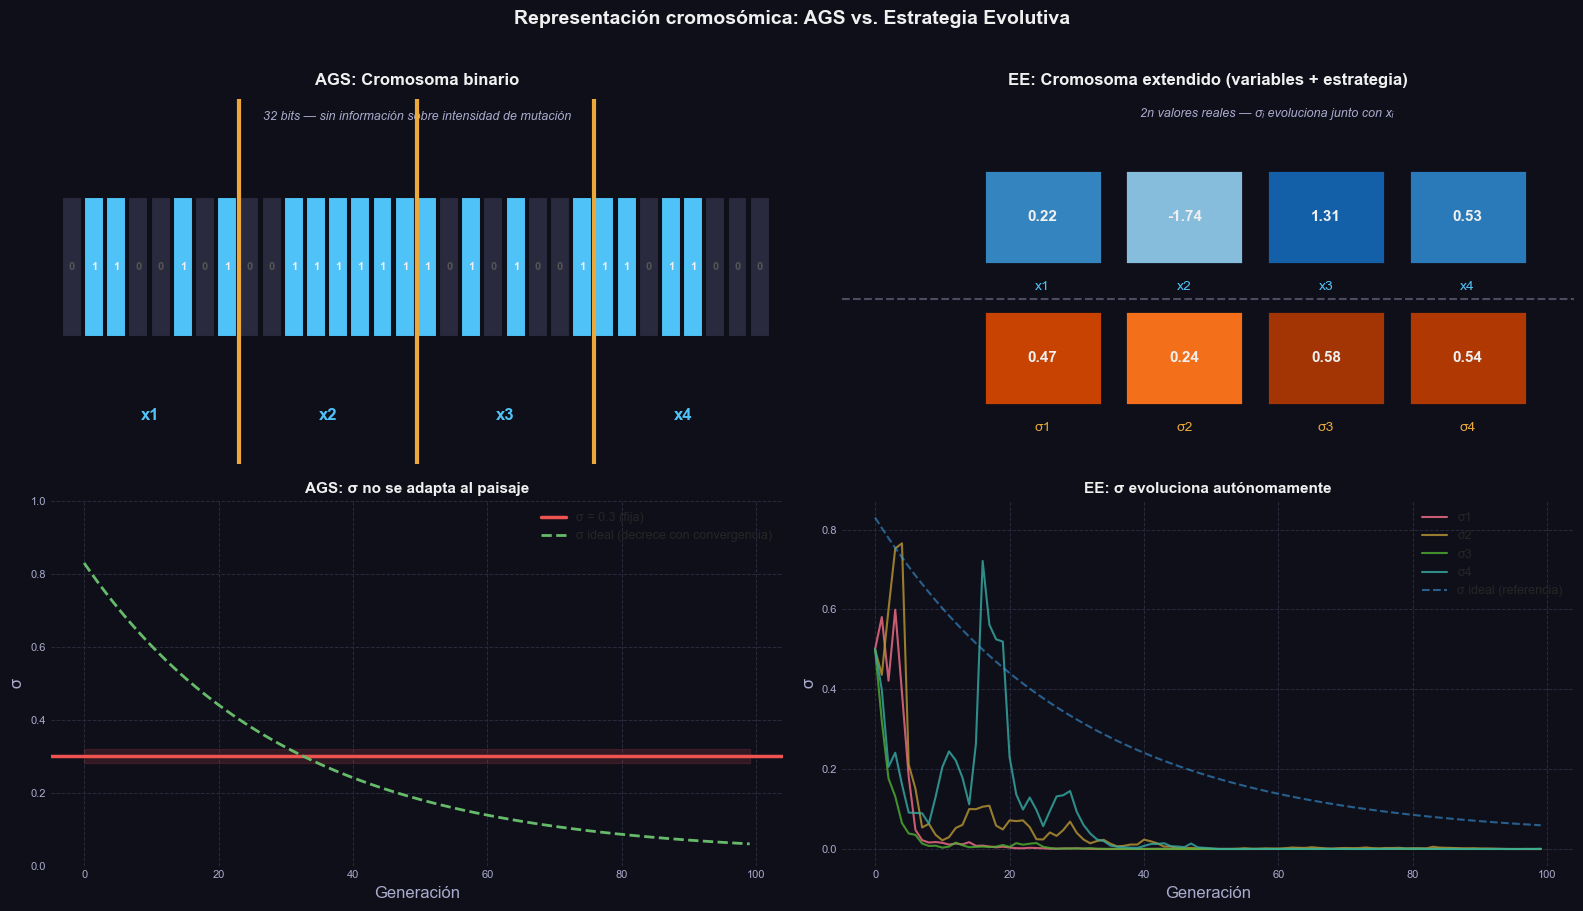

In [3]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN COMPARATIVA: CROMOSOMA AGS vs. EE
# ════════════════════════════════════════════════════════════════════════

# DEFINIR esquema visual
DARK_BG = '#0f0f1a'
GOLD    = '#EBA93B'
BLUE    = '#24398A'
WHITE   = '#f0f0f0'
GRAY    = '#aaaacc'

# CREAR figura 2×2
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Representación cromosómica: AGS vs. Estrategia Evolutiva',
             fontsize=14, fontweight='bold', color=WHITE, y=1.01)

# DEFINIR generaciones y curva σ ideal (referencia teórica)
gens       = np.arange(100)
sigma_opt  = 0.8 * np.exp(-gens / 30) + 0.03   # σ decreciente con convergencia


# ────────────────────────────────────────────────────────────────────────
# PANEL 1: AGS — CROMOSOMA BINARIO
# ────────────────────────────────────────────────────────────────────────

ax = axes[0, 0]
ax.set_facecolor(DARK_BG)

n_bits = 32
bits   = rng.integers(0, 2, n_bits)      # GENERAR individuo binario aleatorio

for i, bit in enumerate(bits):           # PARA cada gen del cromosoma:
    color = '#4FC3F7' if bit == 1 else '#2a2a3e'
    
    # DIBUJAR gen como bloque visual
    rect  = plt.Rectangle([i, 0], 0.9, 1,
                           facecolor=color, edgecolor='#0f0f1a', linewidth=1.5)
    ax.add_patch(rect)
    
    # ESCRIBIR valor del alelo
    ax.text(i + 0.45, 0.5, str(bit), ha='center', va='center',
            fontsize=8, color=WHITE if bit == 1 else '#555', fontweight='bold')

# SEPARAR variables (8 bits por variable)
for sep in [8, 16, 24]:
    ax.axvline(sep, color=GOLD, linewidth=3, zorder=5)

# ETIQUETAR variables del problema
for i, var in enumerate(['x1', 'x2', 'x3', 'x4']):
    ax.text(i*8 + 4, -0.5, var, ha='center', va='top',
            fontsize=12, color='#4FC3F7', fontweight='bold')

# CONFIGURAR panel
ax.set_xlim(-0.5, n_bits + 0.5)
ax.set_ylim(-0.9, 1.7)
ax.set_title('AGS: Cromosoma binario', fontsize=12,
             fontweight='bold', color=WHITE, pad=10)
ax.axis('off')

# ANOTAR propiedad estructural
ax.text(16, 1.55, '32 bits — sin información sobre intensidad de mutación',
        ha='center', fontsize=9, color=GRAY, style='italic')


# ────────────────────────────────────────────────────────────────────────
# PANEL 2: EE — CROMOSOMA EXTENDIDO (x + σ)
# ────────────────────────────────────────────────────────────────────────

ax = axes[0, 1]
ax.set_facecolor(DARK_BG)

n      = 4
x_vals = rng.uniform(-2, 2, n)          # INICIALIZAR variables reales
s_vals = rng.uniform(0.05, 0.6, n)      # INICIALIZAR parámetros σ

cmap_x = plt.cm.Blues
cmap_s = plt.cm.Oranges

# DIBUJAR bloque superior: variables del problema
for i, xv in enumerate(x_vals):
    norm_val = (xv + 2) / 4             # NORMALIZAR para color
    rect = plt.Rectangle([i*1.2, 1.2], 1.0, 0.8,
                          facecolor=cmap_x(0.4 + 0.5*norm_val),
                          edgecolor='#0f0f1a', linewidth=2)
    ax.add_patch(rect)
    
    ax.text(i*1.2 + 0.5, 1.6, f'{xv:.2f}', ha='center', va='center',
            fontsize=11, color=WHITE, fontweight='bold')
    ax.text(i*1.2 + 0.5, 1.05, f'x{i+1}', ha='center', va='top',
            fontsize=10, color='#4FC3F7')

# DIBUJAR bloque inferior: parámetros estratégicos σ
for i, sv in enumerate(s_vals):
    norm_val = sv / 0.6
    rect = plt.Rectangle([i*1.2, 0.0], 1.0, 0.8,
                          facecolor=cmap_s(0.4 + 0.5*norm_val),
                          edgecolor='#0f0f1a', linewidth=2)
    ax.add_patch(rect)
    
    ax.text(i*1.2 + 0.5, 0.4, f'{sv:.2f}', ha='center', va='center',
            fontsize=11, color=WHITE, fontweight='bold')
    ax.text(i*1.2 + 0.5, -0.15, f'σ{i+1}', ha='center', va='top',
            fontsize=10, color=GOLD)

# SEPARAR visualmente variables y estrategia
ax.axhline(0.9, color=GRAY, linestyle='--', linewidth=1.5, alpha=0.4)

ax.set_xlim(-1.2, n*1.2 + 0.2)
ax.set_ylim(-0.5, 2.6)
ax.set_title('EE: Cromosoma extendido (variables + estrategia)', fontsize=12,
             fontweight='bold', color=WHITE, pad=10)
ax.axis('off')

ax.text(n*0.6, 2.45, '2n valores reales — σᵢ evoluciona junto con xᵢ',
        ha='center', fontsize=9, color=GRAY, style='italic')


# ────────────────────────────────────────────────────────────────────────
# PANEL 3: AGS — σ FIJA
# ────────────────────────────────────────────────────────────────────────

ax = axes[1, 0]
ax.set_facecolor(DARK_BG)

# REPRESENTAR σ constante
ax.axhline(0.3, color='#EF5350', linewidth=2.5, label='σ = 0.3 (fija)')
ax.fill_between(gens, 0.28, 0.32, alpha=0.15, color='#EF5350')

# COMPARAR contra σ ideal
ax.plot(gens, sigma_opt, color='#66BB6A', linewidth=2,
        linestyle='--', label='σ ideal (decrece con convergencia)')

ax.set_xlabel('Generación', color=GRAY)
ax.set_ylabel('σ', color=GRAY)
ax.set_title('AGS: σ no se adapta al paisaje', fontsize=11,
             color=WHITE, fontweight='bold')
ax.tick_params(colors=GRAY, labelsize=8)
ax.grid(True, color='#2a2a3e', linewidth=0.7, linestyle='--')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)


# ────────────────────────────────────────────────────────────────────────
# PANEL 4: EE — σ AUTOADAPTATIVA
# ────────────────────────────────────────────────────────────────────────

ax = axes[1, 1]
ax.set_facecolor(DARK_BG)

tau       = 1 / np.sqrt(2 * np.sqrt(4))                                           # PARÁMETRO local
tau_prime = 1 / np.sqrt(2 * 4)                                                    # PARÁMETRO global
                                                                                  # 
sigma_ee  = np.zeros((4, 100))                                                    #
sigma_ee[:, 0] = 0.5                                                              # INICIALIZAR σ₀
                                                                                  # 
rng_local = np.random.default_rng(7)                                              # 
                                                                                  # 
for t in range(1, 100):                                                           # PARA cada generación:
    global_noise = rng_local.normal(0, 1)                                         #    GENERAR ruido global
    
    for i in range(4):                                                            #    PARA cada σᵢ:
        local_noise   = rng_local.normal(0, 1)                                    #       GENERAR ruido para σᵢ
                                                                                  # 
        sigma_ee[i,t] = max(                                                      #       ACTUALIZAR σᵢ mediante regla log-normal
            sigma_ee[i,t-1] * np.exp(tau_prime*global_noise + tau*local_noise),   #       
            1e-4)                                                                 #       ... valor mínimo de sigma
                                                                                  # 

# GRAFICAR trayectorias evolutivas
for i in range(4):
    ax.plot(sigma_ee[i], linewidth=1.5, alpha=0.8, label=f'σ{i+1}')

ax.plot(gens, sigma_opt, linestyle='--', alpha=0.55,
        label='σ ideal (referencia)')

ax.set_xlabel('Generación', color=GRAY)
ax.set_ylabel('σ', color=GRAY)
ax.set_title('EE: σ evoluciona autónomamente', fontsize=11,
             color=WHITE, fontweight='bold')
ax.tick_params(colors=GRAY, labelsize=8)
ax.grid(True, color='#2a2a3e', linewidth=0.7, linestyle='--')
ax.legend(fontsize=9)


# ────────────────────────────────────────────────────────────────────────
# FINALIZAR
# ────────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.show()


Los cuatro paneles sintetizan la diferencia estructural entre los dos enfoques.

En la fila superior se contrasta la arquitectura del cromosoma. El AGS almacena únicamente bits que codifican los valores de las variables; no hay espacio en el cromosoma para información sobre cómo mutar. La EE, en cambio, lleva una segunda capa que contiene los parámetros de estrategia: cada variable tiene su propio $σ$ asociado, y ambas capas evolucionan juntas.

En la fila inferior se ve la consecuencia dinámica de esta diferencia. El AGS mantiene σ constante a lo largo de todas las generaciones, independientemente de si el algoritmo está explorando zonas nuevas o afinando una solución casi convergida. La curva punteada verde marca la intensidad de mutación que sería óptima en cada fase: alta al principio, baja al final. La línea roja del AGS nunca coincide con ella.

Las trayectorias de $σ$ en la EE muestran el comportamiento opuesto: cada componente del vector de estrategia sigue su propia trayectoria, respondiendo a la geometría local del paisaje en esa dirección. La convergencia hacia valores pequeños no es programada — emerge del propio proceso evolutivo.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
Nótese que los <strong>$σ$ de cada dimensión convergen de diferente manera</strong>. Esto no es un defecto — es precisamente la señal de que el algoritmo ha aprendido que diferentes direcciones del espacio requieren diferentes intensidades de exploración. 
</div>

----

## 2. Mutación gaussiana y su geometría

En las Estrategias Evolutivas, la variación de los individuos se realiza mediante **perturbaciones continuas** sobre el vector de variables. A diferencia de los operadores discretos típicos de los Algoritmos Genéticos —como el *bit flip*—, aquí la mutación se define directamente en el espacio continuo $\mathbb{R}^n$. Como consecuencia, la **distribución estadística de la perturbación determina la geometría de la exploración** en el espacio de búsqueda. 

Podemos distinguir tres variantes:

#### Variante 1 — Isótropa ($\sigma$ escalar): La operación básica 

Dado un individuo $\mathbf{x} \in \mathbb{R}^n$, su hijo se obtiene mediante:

$$
\mathbf{x}' = \mathbf{x} + \sigma \cdot \mathbf{z}, \qquad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_n)
$$

El vector de perturbación $\sigma\mathbf{z}$ sigue la distribución $\mathcal{N}(\mathbf{0},\, \sigma^2\mathbf{I})$. Geométricamente, esto significa que los descendientes se distribuyen dentro de una **esfera** centrada en el individuo padre, cuyo radio característico está determinado por $\sigma$. Todas las direcciones del espacio son equiprobables.

**Características:**
1. **Simetría direccional (esfera perfecta)** — la distribución no privilegia ninguna dirección del espacio de búsqueda.  
2. **Estabilidad bajo suma** — la suma de perturbaciones gaussianas sigue siendo gaussiana, lo que mantiene propiedades estadísticas consistentes a lo largo de las iteraciones.  
3. **Conveniencia analítica** — su forma matemática permite estudiar con mayor facilidad el comportamiento y la convergencia del algoritmo.
4. **Parámetro de control:** un escalar $\sigma \in \mathbb{R}^+$.
5. **Adecuada cuando:** el problema está bien escalado y no existen diferencias importantes entre dimensiones.


<br>

#### Variante 2 — Anisótropa (vector $\boldsymbol{\sigma}$)

En este caso, cada hijo se obtiene como

$$
\mathbf{x}' = \mathbf{x} + \boldsymbol{\sigma} \odot \mathbf{z},
\qquad 
\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_n)
$$

donde $\odot$ denota **producto elemento a elemento** o producto de Hadamard.

Equivalentemente, por componentes:

$$
x_i' = x_i + \sigma_i z_i,
\qquad 
z_i \sim \mathcal{N}(0,1),
\quad i = 1,\ldots,n
$$

Esto implica que cada coordenada del descendiente se obtiene perturbando la coordenada del padre con una variable normal independiente escalada por su desviación estándar de mutación.

De forma equivalente, también puede escribirse como:

$$
x_i' \sim \mathcal{N}(x_i, \sigma_i^2)
$$
**Características:**
1. **Nube de hijos:** elipsoide con ejes alineados a las coordenadas.
2. **Parámetros de control:** $n$ escalares — uno por dimensión.
3. **Adecuada cuando:** las variables del problema tienen escalas diferentes pero no presentan correlaciones fuertes.


<br>

#### Variante 3 — Covarianza completa (CMA-ES)
Esta opción la discutiremos más adelante; es la opción más poderosa utilizada en CMA-ES.

$$
\mathbf{x}' = \mathbf{x} + \sigma\,\mathbf{z}, \qquad \mathbf{z}\sim\mathcal{N}(\mathbf{0},\,\mathbf{C})
$$

Aquí $\mathbf{C} \in \mathbb{R}^{n\times n}$ es una matriz de covarianza simétrica definida positiva que el algoritmo **adapta durante la búsqueda**.

- **Nube de hijos:** elipsoide rotado en direcciones arbitrarias.  
- **Parámetros de control:** $1 + \frac{n(n+1)}{2}$, por lo que el costo crece cuadráticamente con $n$.  
- **Adecuada cuando:** existen correlaciones entre variables (por ejemplo, valles diagonales o funciones mal condicionadas).


<br>

### Tabla comparativa

| Variante | Distribución de $\mathbf{z}$ | Forma de la nube | Parámetros libres | Coste por gen. |
|:---|:---:|:---:|:---:|:---:|
| Isótropa | $\mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I})$ | Esfera | $1$ | $O(n)$ |
| Anisótropa | $\mathcal{N}(\mathbf{0},\, \operatorname{diag}(\boldsymbol{\sigma}^2))$ | Elipsoide axial | $n$ | $O(n)$ |
| Covarianza completa | $\mathcal{N}(\mathbf{0},\, \sigma^2\mathbf{C})$ | Elipsoide rotado | $1+\tfrac{n(n+1)}{2}$ | $O(n^2)$ |

> **Maldición de la dimensionalidad del modelo:** aprender $\mathbf{C}$ requiere estimar $O(n^2)$ parámetros. Para $n=100$ son $\approx 5\,000$ entradas — necesitamos muestras suficientes.

<br>

### Visualización

Veamos cómo actúan estas variantes en la función de Schwefel 2D:

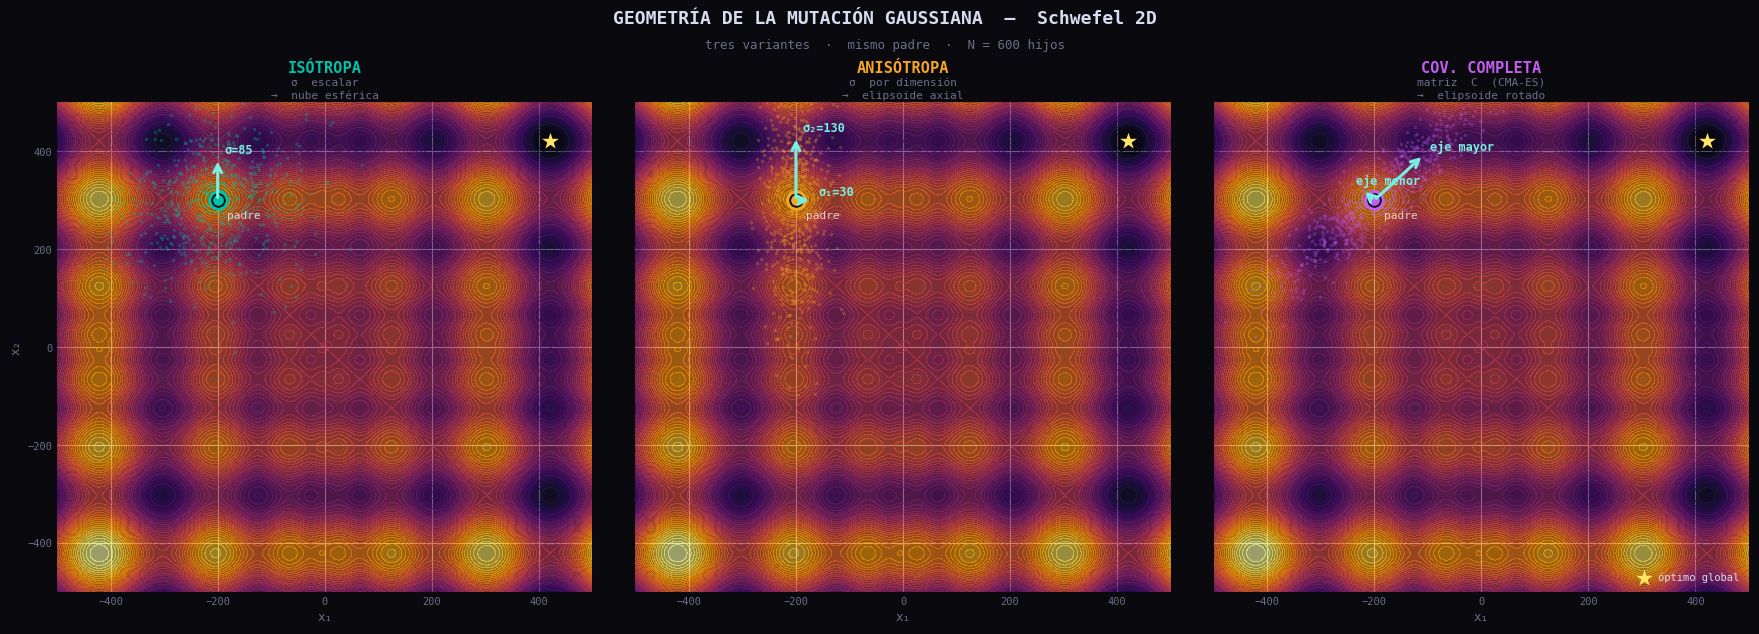

In [4]:
# ════════════════════════════════════════════════════════════════════════
# GEOMETRÍA DE LA MUTACIÓN GAUSSIANA: ESFERA, ELIPSOIDE Y ROTADO
#
# Objetivo : comparar visualmente las tres variantes de mutación
#            gaussiana sobre el paisaje de Schwefel 2D.
#
# Schwefel 2D: mínimo global en (420.97, 420.97) ≈ 0
#              Muchos óptimos locales —paisaje "engañoso"—
#              ideal para ilustrar la importancia de la geometría.
# ════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LogNorm

# ── Paleta ────────────────────────────────────────────────────────────
CBKG    = '#09090E'          # fondo figura
CPANEL  = '#111118'          # fondo ejes
CGRID   = '#1C1C28'          # líneas de grilla suaves
C_ISO   = '#00C2A8'          # cian mineral  → isótropa
C_ANISO = '#F5A623'          # ámbar         → anisótropa
C_ROT   = '#C45EF0'          # lavanda neón  → covarianza completa
C_PADRE = '#FFFFFF'
C_OPT   = '#FFE566'
C_ARROW = '#78F0E0'
C_TEXT  = '#D8DCF0'
C_DIM   = '#6B6F88'

plt.rcParams.update({
    'font.family'      : 'monospace',
    'text.color'       : C_TEXT,
    'axes.labelcolor'  : C_DIM,
    'xtick.color'      : C_DIM,
    'ytick.color'      : C_DIM,
    'axes.edgecolor'   : '#2A2A3A',
    'figure.facecolor' : CBKG,
    'axes.facecolor'   : CPANEL,
})

# ════════════════════════════════════════════════════════════════════════
# 1. FUNCIÓN DE PAISAJE
# ════════════════════════════════════════════════════════════════════════
def schwefel_2d(x, y):
    """
    Schwefel 2D: f(x,y) = 418.9829·2 − [x·sin(√|x|) + y·sin(√|y|)]
    Mínimo global ≈ 0  en  (420.97, 420.97)
    Rango habitual del dominio: [-500, 500]
    """
    return 418.9829 * 2 - (x * np.sin(np.sqrt(np.abs(x))) +
                            y * np.sin(np.sqrt(np.abs(y))))

# Malla del paisaje
LIM    = 500
res    = 350
xg     = np.linspace(-LIM, LIM, res)
yg     = np.linspace(-LIM, LIM, res)
XX, YY = np.meshgrid(xg, yg)
ZZ     = schwefel_2d(XX, YY)

# ════════════════════════════════════════════════════════════════════════
# 2. PADRE Y PARÁMETROS DE MUTACIÓN
# ════════════════════════════════════════════════════════════════════════
padre     = np.array([-200.0, 300.0])   # punto de partida (no en el óptimo)
N_HIJOS   = 600
rng_local = np.random.default_rng(seed=42)

# ── 2a. ISÓTROPA: σ escalar → nube esférica ──────────────────────────
#   x' = x + σ·z,   z ~ N(0, I)
sigma_iso  = 85.0
hijos_iso  = padre + sigma_iso * rng_local.standard_normal((N_HIJOS, 2))

# ── 2b. ANISÓTROPA: σ vector → elipsoide alineado con ejes ───────────
#   x'_i = x_i + σ_i · z_i,   z_i ~ N(0,1)
#   Equivale a C = diag(σ₁², σ₂²)
sigma_vec   = np.array([30.0, 130.0])   # σ₁ << σ₂ → explora más en y
hijos_aniso = padre + sigma_vec * rng_local.standard_normal((N_HIJOS, 2))

# ── 2c. COVARIANZA COMPLETA: C = LLᵀ → elipsoide rotado 45° ─────────
#   z ~ N(0, C)  se muestrea como  z = L · ξ,  ξ ~ N(0,I)
#   donde L es la descomposición de Cholesky de C.
#
#   Construimos C manualmente: rotamos 45° con semiejes [130, 30].
theta = np.radians(45)
R     = np.array([[np.cos(theta), -np.sin(theta)],   # matriz de rotación
                  [np.sin(theta),  np.cos(theta)]])
D     = np.diag([130.0, 30.0])    # semiejes de la elipse (σ_mayor, σ_menor)
L     = R @ D                     # L tal que C ≈ LLᵀ  (Cholesky simplificado)
# Muestreo: x' = x + L · ξ
hijos_rot = padre + (L @ rng_local.standard_normal((2, N_HIJOS))).T

# ════════════════════════════════════════════════════════════════════════
# 3. FIGURA
# ════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6.8), facecolor=CBKG)

# GridSpec: tres columnas simétricas
gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    left=0.04, right=0.98,
    top=0.82,  bottom=0.10,
    wspace=0.08
)

configs = [
    # (hijos,       color,    etiqueta del σ,              título largo)
    (hijos_iso,   C_ISO,   [('σ=85', (0, 85))],
     'ISÓTROPA',   'σ  escalar\n→  nube esférica'),
    (hijos_aniso, C_ANISO, [('σ₁=30', (30, 0)), ('σ₂=130', (0, 130))],
     'ANISÓTROPA', 'σ  por dimensión\n→  elipsoide axial'),
    (hijos_rot,   C_ROT,   [('eje mayor', (L[0,0], L[1,0])), ('eje menor', (L[0,1], L[1,1]))],
     'COV. COMPLETA', 'matriz  C  (CMA-ES)\n→  elipsoide rotado'),
]

axes = []
for col, (hijos, color, flechas, tag_corto, tag_largo) in enumerate(configs):
    ax = fig.add_subplot(gs[col])
    axes.append(ax)

    # — Paisaje (contourf + contorno suave) —
    ax.contourf(XX, YY, ZZ,
                levels=np.linspace(ZZ.min(), ZZ.max(), 45),
                cmap='inferno', alpha=0.60, zorder=1)
    ax.contour(XX, YY, ZZ,
               levels=14, colors='white', alpha=0.08,
               linewidths=0.4, zorder=2)

    # — Nube de hijos —
    ax.scatter(hijos[:, 0], hijos[:, 1],
               color=color, s=6, alpha=0.28, zorder=3,
               linewidths=0)

    # — Padre —
    ax.scatter(*padre, s=160, color=CBKG, zorder=6,
               edgecolors=color, linewidths=2.2)
    ax.scatter(*padre, s=45, color=color, zorder=7)

    # — Óptimo global Schwefel —
    ax.scatter(420.97, 420.97, s=160, marker='*',
               color=C_OPT, zorder=8, linewidths=0,
               label='óptimo global')

    # — Flechas de dirección —
    for lbl, (dx, dy) in flechas:
        ax.annotate(
            '', xy=(padre[0]+dx, padre[1]+dy), xytext=padre,
            arrowprops=dict(arrowstyle='->', color=C_ARROW,
                            lw=2.2, mutation_scale=14),
            zorder=9
        )
        # etiqueta al lado de la punta
        off_x = 12 if dx >= 0 else -12
        off_y = 10 if dy >= 0 else -18
        ax.text(padre[0]+dx+off_x, padre[1]+dy+off_y,
                lbl, color=C_ARROW, fontsize=8.5,
                fontweight='bold', zorder=10)

    # — Etiqueta "padre" —
    ax.text(padre[0]+18, padre[1]-38, 'padre',
            color=C_PADRE, fontsize=8, alpha=0.75)

    # — Límites y ejes —
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.tick_params(labelsize=7.5)
    ax.set_xlabel('x₁', labelpad=3, fontsize=9)
    if col == 0:
        ax.set_ylabel('x₂', labelpad=3, fontsize=9)
    else:
        ax.set_yticklabels([])

    # — Leyenda mínima solo en el último panel —
    if col == 2:
        ax.legend(fontsize=7.5,
                  facecolor='#111118', labelcolor=C_TEXT,
                  edgecolor='#2A2A3A', loc='lower right',
                  handletextpad=0.4)

    # — Título del panel: etiqueta + descripción —
    ax.text(0.5, 1.055, tag_corto,
            transform=ax.transAxes,
            ha='center', va='bottom',
            color=color, fontsize=11, fontweight='bold')
    ax.text(0.5, 1.004, tag_largo,
            transform=ax.transAxes,
            ha='center', va='bottom',
            color=C_DIM, fontsize=8, linespacing=1.4)

# — Título global —
fig.text(0.5, 0.93,
         'GEOMETRÍA DE LA MUTACIÓN GAUSSIANA  —  Schwefel 2D',
         ha='center', va='bottom',
         color=C_TEXT, fontsize=13, fontweight='bold')
fig.text(0.5, 0.895,
         'tres variantes  ·  mismo padre  ·  N = 600 hijos',
         ha='center', va='bottom',
         color=C_DIM, fontsize=9)

plt.show()



<br>

La figura anterior muestra **600 hijos** generados desde el mismo padre  bajo las tres variantes de mutación, superpuestos sobre el paisaje de Schwefel 2D. El óptimo global (★ amarillo) está en $(420.97,\, 420.97)$, lejos del padre.

#### Panel izquierdo — Isótropa (σ escalar)

La nube forma una **corona circular** centrada en el padre: la densidad de hijos cae simétricamente en todas las direcciones a medida que nos alejamos. No hay dirección privilegiada. El algoritmo explora con la misma intensidad hacia el óptimo que en cualquier otra dirección. Funciona bien cuando el paisaje no tiene una orientación preferente, pero no puede aprovechar ninguna estructura geométrica del problema.

#### Panel central — Anisótropa (σ₁ ≠ σ₂)

La nube es ahora un **elipsoide alineado con los ejes coordenados**: estrecha en $x_1$ ($\sigma_1 = 30$) y alargada en $x_2$ ($\sigma_2 = 130$). Las flechas de cian marcan los semiejes.

La forma de la nube es perfectamente predecible a partir de la relación $\sigma_2/\sigma_1 \approx 4.3$: la extensión vertical es 4.3 veces la horizontal. Si el valle del paisaje estuviera alineado verticalmente, esta variante convergiría considerablemente más rápido que la isótropa. Si el valle es diagonal, la ventaja desaparece.


#### Panel derecho — Covarianza completa (CMA-ES)

Aquí, el elipsoide está **rotado aproximadamente 45°** respecto a los ejes coordenados. Esto significa que su eje principal (la dirección en la que la nube de puntos es más larga) no coincide con los ejes $x$ o $y$, sino que apunta en dirección diagonal.

La diferencia respecto al panel central no está en el *tamaño* de la nube sino en su *orientación*: el mismo número de hijos ahora cubre preferentemente la dirección diagonal. Si el paisaje tiene un valle en esa dirección —como ocurre en el experimento siguiente— la mayoría de los hijos caen cerca de la región prometedora, no desperdiciados en direcciones de poco descenso.

---

## 3. La Regla de 1/5 de Rechenberg 

En 1973, Rechenberg propuso un criterio empírico para adaptar el tamaño de mutación $\sigma$ en las Estrategias Evolutivas, conocido como la **regla de 1/5** (o regla del éxito del 20 %). Esta regla se formuló originalmente para el esquema **$(1+1)$-ES**.

La idea se basa en la siguiente observación experimental: al optimizar la función esfera

$$f(\mathbf{x}) = \|\mathbf{x}\|^2$$

la tasa de éxito óptima de las mutaciones, $p_s$, —es decir, la fracción de descendientes que **mejoran el fitness del padre**— tiende a estabilizarse alrededor de

$$p_s \approx \frac{1}{5} = 0.2$$


<p align="center">
  <img src="images/regla_1-5.png" width="90%">
</p>

La gráfica de la izquierda, en la imagen anterior, muestra la **tasa de éxito** $p_s$, es decir, la proporción de mutaciones que producen un hijo con mejor *fitness* que su padre (para la función esfera). La línea horizontal indica el valor **$1/5 = 0.2$** propuesto por la regla empírica de Rechenberg.

- Cuando **$\sigma$ es muy pequeño** $p_s > 1/5$, es decir, se obtienen **tasas de éxito altas**, cercanas a 0.5: las mutaciones son muy conservadoras y los hijos suelen estar muy cerca del padre, por lo que con frecuencia mejoran ligeramente la solución, pero el avance en el espacio de búsqueda es lento (muchos hijos son suficientemente buenos para mejorar a su padre, pero no para aguantar las mejoras de sus propios hijos).

- Cuando **$\sigma$ es muy grande**, $p_s < 1/5$; las mutaciones generan saltos demasiado amplios en el espacio de búsqueda. La mayoría de los descendientes empeoran la solución, por lo que la **tasa de éxito cae rápidamente** hacia cero.

- **Si $p_s \approx 1/5$**, entonces $\sigma$ (*el tamaño de paso*) está aproximadamente bien ajustado.

Para mantener esta tasa de éxito, el algoritmo ajusta periódicamente el valor de $\sigma$. Cada $k$ iteraciones se calcula la tasa de éxito observada y se actualiza el tamaño de mutación según

$$
\sigma \leftarrow
\begin{cases}
\sigma / c & \text{si } p_s > 1/5 \quad (\textsf{aumentar el tamaño de paso}) \\
\sigma \cdot c & \text{si } p_s < 1/5 \quad (\textsf{reducir el tamaño de paso}) \\
\sigma & \text{si } p_s = 1/5
\end{cases}
$$

donde $c < 1$ es un factor constante. Rechenberg sugirió el valor

$c \approx 0.817$

de modo que dividir por $c$ aumenta $\sigma$ y multiplicar por $c$ lo reduce. 

<br>

La gráfica de la derecha muestra una cantidad más importante para la optimización: el **progreso esperado por evaluación**.

Aquí se mide **cuánto mejora en promedio la función objetivo en cada intento de mutación**.

El resultado es una curva con forma de campana:

- Con **$\sigma$ pequeño**, casi todas las mutaciones tienen éxito, pero el avance es **muy corto**.
- Con **$\sigma$ grande**, los saltos son grandes, pero **casi nunca mejoran** la solución.
- Entre ambos extremos aparece un **máximo**, donde el algoritmo progresa más rápido.

En la simulación, el máximo ocurre cerca de:

$$\sigma \approx 5.4$$

y la tasa de éxito en ese punto es aproximadamente

$$p_s \approx 0.39$$

En esencia, la regla busca mantener un **equilibrio entre exploración y explotación**, que es lo que maximiza la velocidad de convergencia del algoritmo.

<br>

#### Límites de la regla 1/5
Observemos ahora el siguiente experimento sobre la función de Schwefel 2D:

σ fija  : f* = 238.8742  |  σ final = 100.0000
Regla 1/5: f* = 335.5780  |  σ final = 0.0018


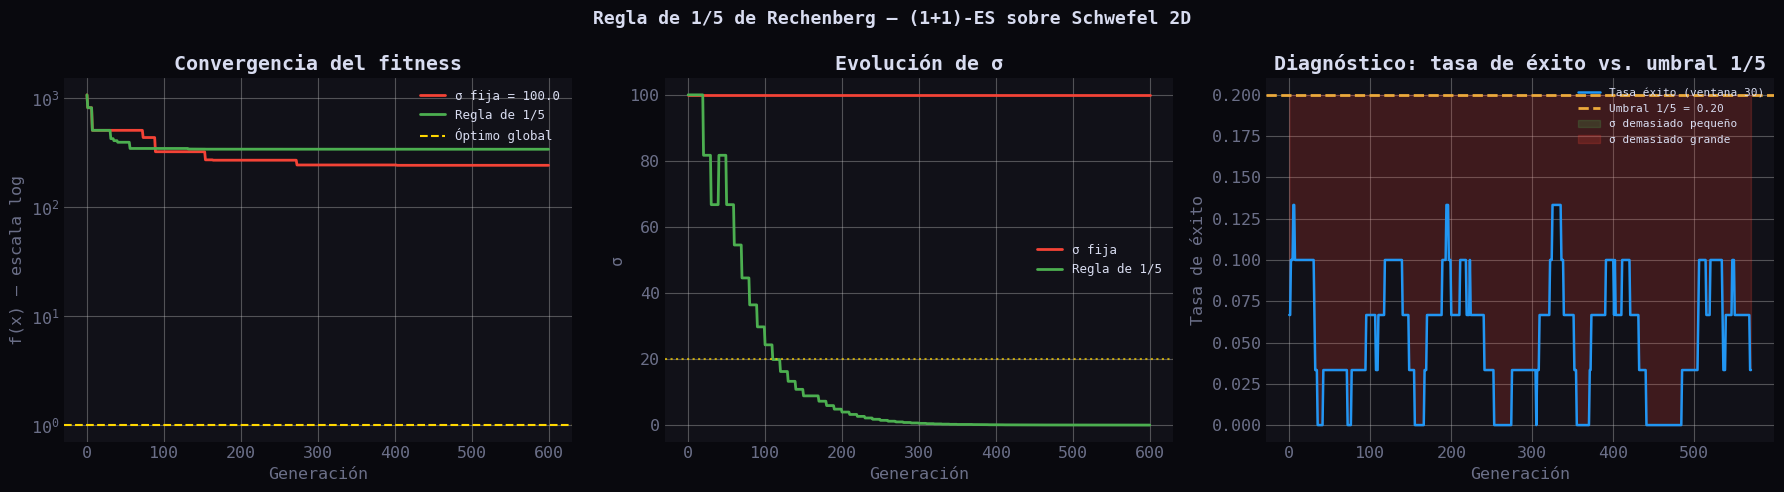

In [5]:
# ════════════════════════════════════════════════════════════════════════
# DEMOSTRACIÓN DE LA REGLA DE 1/5
# Comparamos (1+1)-ES con σ fija vs. (1+1)-ES con Regla de 1/5
# sobre la función de Schwefel 2D
# ════════════════════════════════════════════════════════════════════════

def schwefel(xy):
    return 418.9829*len(xy) - np.sum(xy * np.sin(np.sqrt(np.abs(xy))))


def es_1_1_sigma_fija(sigma0, n_gen=500, seed=0):
    """(1+1)-ES con σ fija."""
    rng_l = np.random.default_rng(seed)
    x = rng_l.uniform(-500, 500, 2)
    f = schwefel(x)
    sigma = sigma0
    hist_f, hist_s = [f], [sigma]

    for _ in range(n_gen):
        hijo = x + sigma * rng_l.standard_normal(2)
        hijo = np.clip(hijo, -500, 500)
        f_hijo = schwefel(hijo)
        if f_hijo <= f:
            x, f = hijo, f_hijo
        hist_f.append(f)
        hist_s.append(sigma)

    return np.array(hist_f), np.array(hist_s)


def es_1_1_regla_1_5(sigma0, c=0.817, k=10, n_gen=500, seed=0):
    """(1+1)-ES con Regla de 1/5 de Rechenberg."""
    rng_l = np.random.default_rng(seed)
    x = rng_l.uniform(-500, 500, 2)
    f = schwefel(x)
    sigma = sigma0
    hist_f, hist_s = [f], [sigma]
    exitos_ventana = []

    for gen in range(n_gen):
        hijo = x + sigma * rng_l.standard_normal(2)
        hijo = np.clip(hijo, -500, 500)
        f_hijo = schwefel(hijo)
        exito = f_hijo <= f
        exitos_ventana.append(int(exito))
        if exito:
            x, f = hijo, f_hijo

        # Ajuste de σ cada k generaciones
        if (gen + 1) % k == 0 and len(exitos_ventana) >= k:
            ps = np.mean(exitos_ventana[-k:])
            if ps > 1/5:
                sigma = sigma / c
            elif ps < 1/5:
                sigma = sigma * c
            sigma = np.clip(sigma, 1e-4, 1000)

        hist_f.append(f)
        hist_s.append(sigma)

    return np.array(hist_f), np.array(hist_s)


# ── Ejecutar experimentos ─────────────────────────────────────────────
SIGMA0 = 100.0
N_GEN  = 600

f_fija, s_fija     = es_1_1_sigma_fija(SIGMA0, N_GEN)
f_regla, s_regla   = es_1_1_regla_1_5(SIGMA0, n_gen=N_GEN)

SCHWEFEL_OPT = 0.0

print(f'σ fija  : f* = {f_fija[-1]:.4f}  |  σ final = {s_fija[-1]:.4f}')
print(f'Regla 1/5: f* = {f_regla[-1]:.4f}  |  σ final = {s_regla[-1]:.4f}')

# ── Figura ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regla de 1/5 de Rechenberg — (1+1)-ES sobre Schwefel 2D', 
             fontsize=13, fontweight='bold')
gens = np.arange(N_GEN + 1)

# Convergencia
ax = axes[0]
ax.semilogy(gens, f_fija + 1,   color='#F44336', linewidth=2, label=f'σ fija = {SIGMA0}')
ax.semilogy(gens, f_regla + 1,  color='#4CAF50', linewidth=2, label='Regla de 1/5')
ax.axhline(SCHWEFEL_OPT + 1, color='gold', linestyle='--', linewidth=1.5, label='Óptimo global')
ax.set_xlabel('Generación'); ax.set_ylabel('f(x) — escala log')
ax.set_title('Convergencia del fitness', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# Evolución de σ
ax = axes[1]
ax.plot(gens, s_fija,  color='#F44336', linewidth=2, label='σ fija')
ax.plot(gens, s_regla, color='#4CAF50', linewidth=2, label='Regla de 1/5')
ax.axhline(1/5 * SIGMA0, color='gold', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Generación'); ax.set_ylabel('σ')
ax.set_title('Evolución de σ', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# Tasa de éxito a lo largo del tiempo (Regla 1/5)
ax = axes[2]
ventana = 30
exitos = []
rng_check = np.random.default_rng(0)
x_tmp = rng_check.uniform(-500, 500, 2)
f_tmp = schwefel(x_tmp)
s_tmp = SIGMA0
for _ in range(N_GEN):
    hijo = x_tmp + s_tmp * rng_check.standard_normal(2)
    hijo = np.clip(hijo, -500, 500)
    f_h = schwefel(hijo)
    ok = f_h <= f_tmp
    exitos.append(int(ok))
    if ok: x_tmp, f_tmp = hijo, f_h
    if (len(exitos)) % 10 == 0:
        ps = np.mean(exitos[-10:])
        s_tmp = s_tmp / 0.817 if ps > 0.2 else s_tmp * 0.817
        s_tmp = np.clip(s_tmp, 1e-4, 1000)

ps_rolling = np.convolve(exitos, np.ones(ventana)/ventana, mode='valid')
ax.plot(ps_rolling, color='#2196F3', linewidth=1.8, label=f'Tasa éxito (ventana {ventana})')
ax.axhline(1/5, color='#EBA93B', linestyle='--', linewidth=2, label='Umbral 1/5 = 0.20')
ax.fill_between(range(len(ps_rolling)), 1/5, ps_rolling,
                where=ps_rolling > 1/5, alpha=0.2, color='#4CAF50', label='σ demasiado pequeño')
ax.fill_between(range(len(ps_rolling)), ps_rolling, 1/5,
                where=ps_rolling < 1/5, alpha=0.2, color='#F44336', label='σ demasiado grande')
ax.set_xlabel('Generación'); ax.set_ylabel('Tasa de éxito')
ax.set_title('Diagnóstico: tasa de éxito vs. umbral 1/5', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

<br>
Esta figura compara dos configuraciones:

- **$\sigma$ fijo** (línea roja)
- **$\sigma$ adaptativo usando la Regla de 1/5 de Rechenberg** (línea verde)

El primer panel muestra la evolución del valor de la función objetivo $f(x)$ en escala logarítmica.

- Con **$\sigma$ fijo**, el algoritmo mejora rápidamente al inicio pero pronto *se estanca* en una región subóptima.
- Con **$\sigma$ adaptativo**, el algoritmo realiza descensos más pronunciados durante las primeras generaciones, pero termina congelando la búsqueda demasiado pronto.

Esto ilustra un aspecto importante:  
la regla de 1/5 **no garantiza un mejor resultado en todos los paisajes**, especialmente en funciones multimodales como Schwefel.

<br>
El segundo panel muestra cómo cambia el tamaño de paso durante la ejecución.

- En el caso de **$\sigma$ fijo**, el valor permanece constante.
- Con la **regla de 1/5**, $\sigma$ comienza grande y se reduce gradualmente conforme la tasa de éxito observada es baja.

El resultado es una disminución progresiva del tamaño de paso, que eventualmente lleva a valores muy pequeños.  
En ese punto el algoritmo sigue mutando, pero los cambios son tan pequeños que el progreso se vuelve prácticamente nulo.

<br>

El tercer panel muestra la tasa de éxito de las mutaciones en una ventana deslizante. La línea horizontal marca el umbral teórico de $1/5 = 0.2$. Podemos observar que la tasa de éxito, para esta función objetivo, está muy por debajo del umbral, es decir, $p_s \ll 1/5$, lo que provoca que el mecanismo de adaptación siga reduciendo $\sigma$. El algoritmo interpreta que los pasos son demasiado grandes, aunque en realidad el problema es la estructura del paisaje de la función, que hace difícil encontrar mejoras.


> 1. La regla de 1/5 funciona bien en paisajes suaves y convexos (como la función esfera).
> 2. En funciones multimodales o irregulares, la tasa de éxito puede ser baja incluso cuando el tamaño de paso es adecuado.

Por esta razón, los métodos modernos —como **CMA-ES**— utilizan mecanismos de adaptación más sofisticados que no dependen únicamente de la tasa de éxito.

---

## 4. Autoadaptación de parámetros de estrategia

La regla de 1/5 es un mecanismo de control externo: el algoritmo debe medir periódicamente la tasa de éxito de las mutaciones y ajustar el tamaño de paso $\sigma$ en consecuencia.

La **autoadaptación lognormal** propone una idea diferente: los *parámetros de estrategia* se incorporan al cromosoma del individuo y evolucionan junto con las variables del problema. De esta manera, la selección natural actúa no solo sobre las soluciones $x$, sino también sobre los valores de $\sigma$ que determinan cómo se generan las mutaciones.

### El principio: evolución de los tamaños de paso

Cada individuo se representa como

$$(x_1,\ldots,x_n \mid \sigma_1,\ldots,\sigma_n)$$

o, en el caso isotrópico,

$$(x_1,\ldots,x_n \mid \sigma)$$

Si un individuo posee un valor de $\sigma$ que produce descendientes de buena calidad, ese individuo tendrá mayor probabilidad de sobrevivir y reproducirse. Como consecuencia, ese valor de $\sigma$ tenderá a propagarse en la población.

Por el contrario, tamaños de paso inadecuados —demasiado grandes o demasiado pequeños para el paisaje actual— generarán descendientes de menor calidad y desaparecerán gradualmente por efecto de la selección.

En este esquema no existe una regla explícita de ajuste (como 1/5): el comportamiento adecuado de $\sigma$ emerge del proceso evolutivo.


### Mutación lognormal de los parámetros de estrategia

Los parámetros $\sigma$ también se mutan en cada generación. En lugar de utilizar una perturbación aditiva gaussiana, se emplea una **mutación multiplicativa lognormal**.

Hay dos razones principales:

1. **Positividad:** el tamaño de paso debe cumplir $\sigma > 0$. La transformación exponencial garantiza esta propiedad.
2. **Escala relativa:** en optimización continua es más natural que los cambios en $\sigma$ sean relativos (por ejemplo, duplicar o reducir a la mitad el tamaño de paso) que absolutos.

### Caso isótropo: esfera

Para el caso **isótropo** (un único $\sigma$ por individuo), la regla de mutación es

$$\sigma' = \sigma \cdot \exp\left(\tau\,\mathcal{N}(0,1)\right)$$

donde $\tau$ es el **parámetro de aprendizaje** que controla la magnitud de los cambios en $\sigma$.

Un valor comúnmente utilizado es

$$\tau = \frac{1}{\sqrt{n}}$$

donde $n$ es la dimensión del problema. En dimensiones altas, los cambios en $\sigma$ se vuelven más graduales.

> **Nota**: En estas ecuaciones, $\mathcal{N}(0,1)$ es una normal estándar. Si aplicamos logaritmos en la ecuación $\sigma' = \sigma \cdot \exp\left(\tau\,\mathcal{N}(0,1)\right)$ obtenemos:
 $$\log \sigma' = \log \sigma + \tau \mathcal{N}(0,1)$$
Esto significa que el logaritmo del nuevo parámetro es normal, porque es la suma de una constante y una variable normal. Por definición, si
> $$\log X \approx \mathcal{N}(\mu,\sigma^2)$$
entonces $X$ sigue una distribución lognormal.


### Caso anisótropo: un tamaño de paso por dimensión

Cuando cada variable posee su propio parámetro de estrategia $\sigma$, la mutación se realiza en dos niveles:

$$
\sigma_i' =
\sigma_i \cdot
\exp\left(
\tau' \mathcal{N}(0,1) +
\tau \mathcal{N}_i(0,1)
\right)
$$

con

$$
\tau' = \frac{1}{\sqrt{2n}},
\qquad
\tau = \frac{1}{\sqrt{2\sqrt{n}}}
$$

Aquí aparecen dos componentes:

- **Ruido global** $\mathcal{N}(0,1)$: el mismo para todas las dimensiones del individuo, que permite modificar la escala global de exploración.
- **Ruido local** $\mathcal{N}_i(0,1)$: independiente para cada dimensión, que permite ajustes específicos por eje.

Esta separación permite que el algoritmo adapte simultáneamente la **intensidad global de la búsqueda** y la **escala relativa de cada variable**.

### El orden de las operaciones

Un detalle importante del protocolo de autoadaptación es el orden de las mutaciones:

1. Primero se mutan los **parámetros de estrategia** $\sigma$.
2. Después se mutan las **variables del problema**  $x $ utilizando el nuevo valor $\sigma$.

Es decir,

$$
\sigma \rightarrow \sigma'
\quad\Rightarrow\quad
x' = x + \sigma' z
$$

Este orden permite que la selección evalúe conjuntamente el par $(x',\sigma')$. Si se mutara primero $x$ usando el $\sigma$ antiguo, la selección no podría atribuir correctamente el éxito o fracaso de un descendiente al valor de $\sigma$, y el mecanismo de autoadaptación perdería efectividad.

---

## 5. Estrategias Evolutivas $(\mu + \lambda)$-ES

La forma más simple de una Estrategia Evolutiva es el esquema **$(1+1)$-ES**, en el que un único individuo genera un descendiente mediante mutación, y el mejor de ambos sobrevive a la siguiente iteración. Este modelo minimalista captura la idea fundamental de **selección por supervivencia**, pero su capacidad exploratoria es limitada al operar sobre un solo punto del espacio de búsqueda.

La generalización natural consiste en trabajar con poblaciones. En este caso, una población de **$\mu$ padres** genera una descendencia de **$\lambda$ hijos** mediante operadores de variación. El rasgo distintivo de las Estrategias Evolutivas es que **la población no se reemplaza completamente entre generaciones**. En la naturaleza, los nuevos individuos coexisten con generaciones anteriores y compiten por recursos; de forma análoga, en el modelo **$(\mu + \lambda)$-ES** los descendientes compiten directamente con sus progenitores. El símbolo **`+`** indica un esquema de **selección elitista**, precisamene ese en el que padres e hijos se consideran conjuntamente para formar la siguiente generación. Formalmente:

$$
\text{Población}_{t+1} =
\text{seleccionar}_{\mu \text{ mejores}}
\left(
\underbrace{\cal{P}_t}_{\mu \text{ padres}}
\cup
\underbrace{\cal{O}_t}_{\lambda \text{ hijos}}
\right)
$$

Este mecanismo garantiza que **los mejores individuos encontrados hasta el momento nunca se pierden**, ya que siempre participan en la selección de supervivientes. Si ningún descendiente mejora a los padres, los individuos originales permanecen en la población.

Como consecuencia, el **mejor valor de fitness de la población es no decreciente a lo largo de las generaciones**, lo que introduce estabilidad en el proceso de búsqueda y favorece la convergencia hacia regiones prometedoras del espacio de soluciones.



### Algoritmo básico

1. **Inicialización:** Se genera una población inicial de $\mu$ individuos. En una EE, cada individuo incluye tanto las **variables del problema** como sus **parámetros de estrategia** (por ejemplo, desviaciones estándar de mutación).

2. **Generación de descendencia:** A partir de los $\mu$ padres se producen $\lambda$ hijos mediante recombinación (opcional) y mutación. Los parámetros de estrategia también se heredan y mutan, permitiendo **auto-adaptación**.

3. **Evaluación:** Cada descendiente es evaluado mediante la función de *fitness* del problema.

4. **Selección de supervivientes:** De la unión de los $\mu$ padres y los $\lambda$ hijos se seleccionan los **$\mu$ individuos con mejor aptitud**, que conformarán la población de la siguiente generación.

5. **Iteración:** El proceso se repite hasta satisfacer un criterio de parada (número máximo de generaciones, convergencia o valor objetivo alcanzado).

<br>

| Símbolo | Nombre | Rol |
|:---:|:---|:---|
| $\mu$ | **Mu** | Tamaño de la población de **padres** — los que sobreviven cada generación |
| $\lambda$ | **Lambda** | Número de **hijos** generados — nuevas soluciones candidatas por mutación |
| **`+`** | **Operador elitista** | La selección actúa sobre la **unión** $\text{padres} \cup \text{hijos}$ |

La relación $\lambda / \mu \approx 7$ es una regla empírica clásica y su objetivo es generar suficiente diversidad sin desperdiciar evaluaciones.

### Ejercicio: Calibración de un modelo epidémico SIR con (μ+λ)-ES

Un epidemiólogo recibe datos de campo de un brote infeccioso que consiste en la serie temporal del número de **infectados** medida durante 60 días con ruido de observación. Su tarea es estimar los parámetros del modelo SIR que mejor explican los datos.

---

#### El modelo SIR (Susceptibles, Infectados y Recuperados)

El modelo SIR (**Susceptibles-Infectados-Recuperados**) es un modelo matemático utilizado en epidemiología para estudiar la propagación de enfermedades contagiosas. En su forma más simple, divide a la población en tres compartimentos: los que pueden contraer la enfermedad, los que están infectados y los que se han recuperado. Se utiliza para predecir la evolución de epidemias y evaluar el impacto de medidas sanitarias. 

| Compartimento | Significado |
|---|---|
| **S(t)** | Susceptibles — pueden infectarse |
| **I(t)** | Infectados — transmiten la enfermedad |
| **R(t)** | Recuperados (o removidos) — ya no participan en la transmisión |

El modelo se describe mediante un sistema de **dinámico no lineal de EDOs acopladas**, donde las tasas de cambio de cada compartimento se determinan exclusivamente por el estado actual del sistema en el tiempo $t$:

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

donde $N = S + I + R$ es la población total, que se asume constante.

Los parámetros del modelo son:

- **$\beta$ (tasa de transmisión):** controla la velocidad a la que ocurren nuevos contagios. Representa la probabilidad efectiva de transmisión cuando un individuo susceptible entra en contacto con uno infectado.

- **$\gamma$ (tasa de recuperación):** es aproximadamente el inverso de la **duración media del periodo infeccioso** $D$, es decir

$$
\gamma \approx \frac{1}{D}
$$

- **$R_0$ (número básico de reproducción):**

$$
R_0 = \frac{\beta}{\gamma}
$$

representa el número promedio de casos secundarios producidos por un infectado en una población completamente susceptible.

<p align="center">
<img src="images/sir_modelo.jpeg" width="500">
</p>

---


#### Validez y Limitaciones

Aunque el modelo SIR es una herramienta clásica de la epidemiología matemática, su utilidad depende del grado en que se cumplan sus supuestos.

##### Puntos fuertes 

- **Brotes localizados:** es útil para modelar brotes relativamente cortos en poblaciones cerradas (escuelas, campus, comunidades pequeñas).

- **Estimación del pico epidémico:** permite estimar aproximadamente cuándo se alcanzará el máximo número de infectados y, por lo tanto, la mayor presión sobre el sistema de salud.

##### Limitaciones 

1. **Homogeneidad de la población**: El modelo supone que todos los individuos tienen la misma probabilidad de interactuar entre sí, ignorando estructura social, edad o geografía.

2. **Inmunidad temporal**: El modelo SIR asume inmunidad permanente. Para enfermedades donde la inmunidad disminuye con el tiempo se usa el modelo **SIRS**, que introduce un flujo adicional $R \rightarrow S$

3. **Dinámica demográfica**: No considera nacimientos ni muertes por causas externas a la enfermedad, lo que limita su uso en estudios de largo plazo.

4. **Periodo de incubación**: El modelo no distingue entre individuos **infectados pero aún no contagiosos**. Para modelar esta fase se usa el modelo **SEIR**, que introduce un compartimento adicional **E (Expuestos)**.

5. **Falta de resolución espacial**: Al ser un modelo de parámetros concentrados (EDO), el SIR ignora la propagación geográfica. Para modelar la difusión física de un virus en un territorio, la matemática convencional recurre a **Ecuaciones Diferenciales en Derivadas Parciales (EDP)**. Esta transición aumenta drásticamente la complejidad del espacio de búsqueda, haciendo que los métodos analíticos tradicionales sean insuficientes y haciendo necesario el uso de metaheurísticas para optimizar los parámetros en escenarios de alta dimensionalidad.


---

#### Datos observados

En la práctica el epidemiólogo **no observa directamente la trayectoria real de infectados** $I(t)$.

Los sistemas de vigilancia epidemiológica registran únicamente el número de **casos reportados**, que suele ser una fracción de los casos reales y además contiene ruido de conteo.

En este ejercicio utilizamos **datos sintéticos**, generados mediante el siguiente proceso:

1. Se simula un brote epidémico con el modelo SIR usando parámetros que serían desconocidos para el epidemiólogo.

2. La trayectoria real $I(t)$ se muestrea en intervalos discretos de tiempo.

3. Cada observación se genera mediante un proceso de conteo de Poisson:

$$
\hat I_t \sim \text{Poisson}(\rho I(t))
$$

donde

- $\hat I_t$ es el número de **casos reportados**
- $\rho \in (0,1)$ es la **tasa de reporte**
- $I(t)$ es el número real de infectados.

Como resultado, el epidemiólogo observa una serie temporal **ruidosa y parcialmente observada** de la dinámica epidémica.

---


Parámetros verdaderos:  β=0.3, γ=0.07, R₀=4.29

Población N=10,000  |  Infectados iniciales I₀=10
Observaciones en 61 puntos temporales (cada 2 días)
Tasa de reporte simulada ρ = 0.85



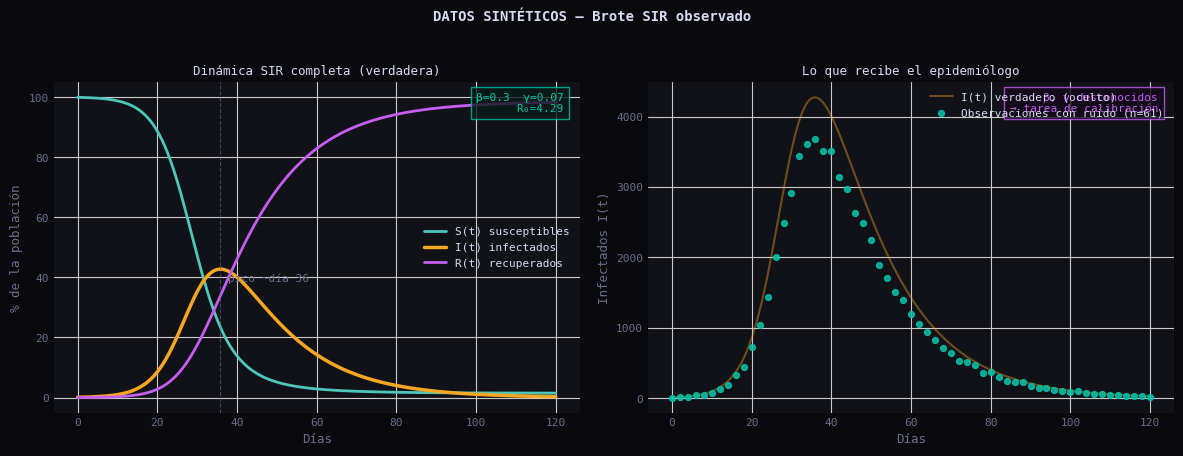


Pico real de infectados: 4273  (42.7%)
Máximo observado:        3684



In [6]:
# ════════════════════════════════════════════════════════════════════════
# DATOS SINTÉTICOS
#
# Simulamos el "brote verdadero" con parámetros conocidos, añadimos ruido
# de Poisson (realista para conteos epidémicos) y guardamos sólo I(t).
# Estos son los datos que recibiría el epidemiólogo en campo.
# ════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

# ── Paleta del curso ──────────────────────────────────────────────────
CBKG   = '#09090E'
CPANEL = '#111118'
C_CYN  = '#00C2A8'
C_AMB  = '#F5A623'
C_LAV  = '#C45EF0'
C_DIM  = '#6B6F88'
C_TXT  = '#D8DCF0'

plt.rcParams.update({
    'font.family'     : 'monospace',
    'text.color'      : C_TXT,
    'axes.labelcolor' : C_DIM,
    'xtick.color'     : C_DIM,
    'ytick.color'     : C_DIM,
    'axes.edgecolor'  : '#2A2A3A',
    'figure.facecolor': CBKG,
    'axes.facecolor'  : CPANEL,
})

# ── Parámetros VERDADEROS (el "ground truth" que la ES deberá encontrar) 
BETA_TRUE  = 0.30   # tasa de transmisión  [día⁻¹]
GAMMA_TRUE = 0.07   # tasa de recuperación [día⁻¹]
R0_TRUE    = BETA_TRUE / GAMMA_TRUE
N          = 10_000  # población total
I0         = 10      # infectados iniciales
S0         = N - I0
R0_init    = 0

T_DIAS = 120         # duración de la simulación
T_OBS  = np.arange(0, T_DIAS + 1, 2)   # observaciones cada 2 días

print(f"\nParámetros verdaderos:  β={BETA_TRUE}, γ={GAMMA_TRUE}, R₀={R0_TRUE:.2f}")
print(f"\nPoblación N={N:,}  |  Infectados iniciales I₀={I0}")
print(f"Observaciones en {len(T_OBS)} puntos temporales (cada 2 días)")

# ── Integrador SIR ────────────────────────────────────────────────────
def sir_ode(t, y, beta, gamma, N):
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

def simular_sir(beta, gamma, t_eval=None):
    """Integra el modelo SIR y devuelve (t, S, I, R)."""
    sol = solve_ivp(
        sir_ode,
        t_span=(0, T_DIAS),
        y0=[S0, I0, R0_init],
        args=(beta, gamma, N),
        method='RK45',
        t_eval=t_eval if t_eval is not None else np.linspace(0, T_DIAS, 500),
        rtol=1e-8, atol=1e-8,
        dense_output=False
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# ── Brote limpio ───────────────────────────────────────────────────────
t_cont, S_true, I_true, R_true = simular_sir(BETA_TRUE, GAMMA_TRUE)

# ── Observaciones ruidosas (modelo epidemiológico) ─────────────────────
rng = np.random.default_rng(seed=2019)

# Tasa de reporte (subregistro)
RHO_REPORT = 0.85   # sólo se reporta el 85% de los casos
print(f"Tasa de reporte simulada ρ = {RHO_REPORT}\n")

# Infectados reales en los tiempos de observación
_, _, I_obs_clean, _ = simular_sir(BETA_TRUE, GAMMA_TRUE, t_eval=T_OBS)

# Observación epidemiológica:
#   Y_t ~ Poisson(ρ I_t)
I_obs = rng.poisson(RHO_REPORT * I_obs_clean).astype(float)

# ── Visualización ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=CBKG)
fig.suptitle('DATOS SINTÉTICOS — Brote SIR observado',
             color=C_TXT, fontsize=10, fontweight='bold', y=1.01)

# Panel izquierdo: dinámica completa SIR
ax1 = axes[0]
ax1.set_facecolor(CPANEL)
ax1.plot(t_cont, S_true / N * 100, color='#4DC7BA', lw=2, label='S(t) susceptibles')
ax1.plot(t_cont, I_true / N * 100, color=C_AMB,    lw=2.5, label='I(t) infectados')
ax1.plot(t_cont, R_true / N * 100, color=C_LAV,    lw=2, label='R(t) recuperados')
ax1.set_xlabel('Días', fontsize=9)
ax1.set_ylabel('% de la población', fontsize=9)
ax1.set_title('Dinámica SIR completa (verdadera)', fontsize=9, color=C_TXT, pad=6)
ax1.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
           edgecolor='#2A2A3A')
ax1.tick_params(labelsize=8)
for sp in ax1.spines.values():
    sp.set_edgecolor('#2A2A3A')

# Anotación R₀
pico_dia = t_cont[np.argmax(I_true)]
ax1.axvline(pico_dia, color=C_DIM, lw=0.8, ls='--', alpha=0.6)
ax1.text(pico_dia + 2, I_true.max() / N * 100 * 0.9,
         f'pico ~día {pico_dia:.0f}', color=C_DIM, fontsize=8)
ax1.text(0.97, 0.97,
         f'β={BETA_TRUE}  γ={GAMMA_TRUE}\nR₀={R0_TRUE:.2f}',
         transform=ax1.transAxes, ha='right', va='top',
         color=C_CYN, fontsize=8,
         bbox=dict(facecolor='#0A1A18', edgecolor=C_CYN, alpha=0.8, pad=4))

# Panel derecho: lo que "observa" el epidemiólogo
ax2 = axes[1]
ax2.set_facecolor(CPANEL)
ax2.plot(t_cont, I_true, color=C_AMB, lw=1.5, alpha=0.4,
         label='I(t) verdadero (oculto)')
ax2.scatter(T_OBS, I_obs, s=18, color=C_CYN, zorder=5, alpha=0.85,
            label=f'Observaciones con ruido (n={len(T_OBS)})')
ax2.set_xlabel('Días', fontsize=9)
ax2.set_ylabel('Infectados I(t)', fontsize=9)
ax2.set_title('Lo que recibe el epidemiólogo', fontsize=9, color=C_TXT, pad=6)
ax2.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
           edgecolor='#2A2A3A')
ax2.tick_params(labelsize=8)
for sp in ax2.spines.values():
    sp.set_edgecolor('#2A2A3A')

ax2.text(0.97, 0.97,
         'β, γ desconocidos\n→ tarea de calibración',
         transform=ax2.transAxes, ha='right', va='top',
         color=C_LAV, fontsize=8,
         bbox=dict(facecolor='#140A1A', edgecolor=C_LAV, alpha=0.8, pad=4))

plt.tight_layout()
plt.show()

print(f"\nPico real de infectados: {I_true.max():.0f}  ({I_true.max()/N*100:.1f}%)")
print(f"Máximo observado:        {I_obs.max():.0f}\n")

#### Parámetros a calibrar en el experimento

| Parámetro | Significado biológico | Rango típico |
|---|---|---|
| **β** | Tasa de transmisión (contactos × probabilidad de infección) | (0.1, 1.0) día⁻¹ |
| **γ** | Tasa de recuperación | (0.01, 0.5) día⁻¹ |

El número reproductivo básico es

$$
R_0 = \frac{\beta}{\gamma}
$$

Si $R_0 > 1$ ocurre un brote epidémico.  
Si $R_0 < 1$ la infección tiende a extinguirse.

---


#### La tarea de optimización

Dado un vector de observaciones ruidosas $\hat I_t$, buscamos los parámetros que minimizan el error entre el modelo y los datos observados:

$$
(\beta^*, \gamma^*) =
\arg\min_{\beta,\gamma} \; \mathcal{L}(\beta,\gamma)
$$

donde

$$
\mathcal{L}(\beta,\gamma)
=
\sum_t
\left(
I(t;\beta,\gamma)-\hat I_t
\right)^2
$$

Aquí

- $I(t;\beta,\gamma)$ es la solución del modelo SIR
- $\hat I_t$ corresponde a las observaciones con ruido.

---


#### Dificultad del problema

El paisaje de la función de pérdida $\mathcal{L}(\beta,\gamma)$ suele presentar una **cresta diagonal estrecha**.  

Esto ocurre porque $\beta$ y $\gamma$ están **fuertemente correlacionados** a través del número reproductivo básico:

$$
R_0 = \frac{\beta}{\gamma}
$$

Diferentes combinaciones de parámetros pueden producir trayectorias epidémicas similares si mantienen aproximadamente constante el valor de $R_0$.

Como consecuencia:

- La **mutación isótropa simple** explora el espacio de parámetros de forma ineficiente.
- las **estrategias evolutivas con autoadaptación** pueden ajustar dinámicamente las escalas de mutación.

#### Estrategia Evolutiva para calibrar el modelo

Para estimar los parámetros del modelo utilizaremos una **Estrategia Evolutiva $(\mu+\lambda)$ con autoadaptación de mutaciones**.

Cada individuo representa una posible parametrización del modelo junto con sus escalas de mutación:

$$
x = (\beta,\gamma,\sigma_\beta,\sigma_\gamma)
$$

donde

- $\beta$ : tasa de transmisión  
- $\gamma$ : tasa de recuperación  
- $\sigma_\beta$ : desviación estándar de mutación para $\beta$  
- $\sigma_\gamma$ : desviación estándar de mutación para $\gamma$

Las escalas de mutación **evolucionan junto con los parámetros del modelo**.

---

Para evaluar un individuo se ejecutan los siguientes pasos:

1. **Simulación del modelo**: Se resuelve el sistema de EDO del modelo SIR usando los parámetros $(\beta,\gamma)$. Esto produce una trayectoria simulada:

$$
I(t;\beta,\gamma)
$$

2. **Comparación con datos**: Se compara la trayectoria simulada con las observaciones ruidosas:

$$
\hat{I}_t
$$

3. **Cálculo del fitness**: La calidad del individuo se mide mediante el error cuadrático total (Nota: *como todos los individuos de una población se prueban contra el mismo número de casos de prueba, la jerarquía -quién sobrevive y quién no- es idéntica usando TSE o MSE):

$$
\mathcal{L}(\beta,\gamma)
=
\sum_t
\left(I(t;\beta,\gamma)-\hat{I}_t\right)^2
$$

El objetivo es **minimizar** esta función.


L(β_true, γ_true) = 70995.8823  ← referencia (mínimo esperado)
L(0.5, 0.1)       = 1923462.0
L(0.1, 0.3)       = 2294552.0

Computando paisaje 2D (esto tarda ~20 segundos)...


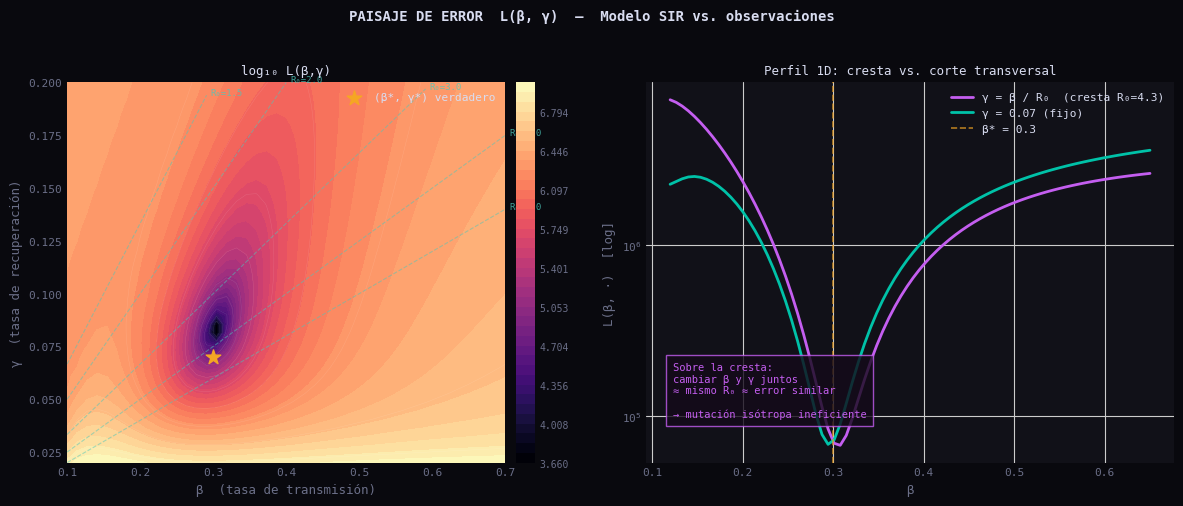


Mínimo en la grilla: L = 4567.27
L en (β_true, γ_true): L = 70995.88


In [7]:
# ════════════════════════════════════════════════════════════════════════
# FUNCIÓN OBJETIVO Y PAISAJE DE ERROR
#
# Antes de optimizar, exploramos el paisaje de pérdida L(β, γ).
# Observaremos la cresta diagonal característica del modelo SIR:
# muchas combinaciones (β, γ) con el mismo R₀ dan errores parecidos,
# pero sólo una explica bien la VELOCIDAD del brote.
# ════════════════════════════════════════════════════════════════════════

# ── Función objetivo (MSE sobre infectados observados) ────────────────
def funcion_objetivo(params, t_obs=T_OBS, I_obs=I_obs, N=N):
    """
    Evalúa el error cuadrático medio entre el modelo SIR y las obs.
    
    params : array [β, γ]
    retorna: float MSE (escalar a minimizar)
    """
    beta, gamma = params
    # Penalizar valores fuera del dominio biológico
    if beta <= 0 or gamma <= 0 or beta > 2 or gamma > 1:
        return 1e12
    
    try:
        _, _, I_model, _ = simular_sir(beta, gamma, t_eval=t_obs)
        mse = np.mean((I_model - I_obs) ** 2)
        return float(mse)
    except Exception:
        return 1e12

# ── Verificación rápida ───────────────────────────────────────────────
L_verdadero = funcion_objetivo([BETA_TRUE, GAMMA_TRUE])
print(f"L(β_true, γ_true) = {L_verdadero:.4f}  ← referencia (mínimo esperado)")
print(f"L(0.5, 0.1)       = {funcion_objetivo([0.5, 0.1]):.1f}")
print(f"L(0.1, 0.3)       = {funcion_objetivo([0.1, 0.3]):.1f}")

# ── Malla 2D para visualizar el paisaje ───────────────────────────────
print("\nComputando paisaje 2D (esto tarda ~20 segundos)...")

N_GRID  = 45
betas   = np.linspace(0.10, 0.70, N_GRID)
gammas  = np.linspace(0.02, 0.20, N_GRID)
BB, GG  = np.meshgrid(betas, gammas)
LL      = np.zeros_like(BB)

for i in range(N_GRID):
    for j in range(N_GRID):
        LL[i, j] = funcion_objetivo([BB[i, j], GG[i, j]])

LL_log = np.log10(np.maximum(LL, 1))   # escala log para visualizar

# ── Líneas de R₀ constante ────────────────────────────────────────────
R0_lines = [1.5, 2.0, 3.0, 4.0, 5.0]

# ── Figura ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=CBKG)
fig.suptitle('PAISAJE DE ERROR  L(β, γ)  —  Modelo SIR vs. observaciones',
             color=C_TXT, fontsize=10, fontweight='bold', y=1.01)

# Panel izquierdo: mapa de calor del error
ax1 = axes[0]
ax1.set_facecolor(CPANEL)
cf = ax1.contourf(BB, GG, LL_log,
                  levels=np.linspace(LL_log.min(), LL_log.max(), 40),
                  cmap='magma')
ax1.contour(BB, GG, LL_log,
            levels=12, colors='white', linewidths=0.3, alpha=0.15)

# Líneas de R₀ = cte
for r0 in R0_lines:
    g_line = betas / r0
    mask   = (g_line >= gammas.min()) & (g_line <= gammas.max())
    ax1.plot(betas[mask], g_line[mask],
             color='#4DC7BA', lw=0.8, ls='--', alpha=0.5)
    if mask.any():
        idx = np.where(mask)[0][-1]
        ax1.text(betas[mask][idx] + 0.005, g_line[mask][idx],
                 f'R₀={r0}', color='#4DC7BA', fontsize=6.5, alpha=0.8)

# Mínimo verdadero
ax1.scatter(BETA_TRUE, GAMMA_TRUE, s=120, color=C_AMB,
            marker='*', zorder=10, label='(β*, γ*) verdadero')
ax1.set_xlabel('β  (tasa de transmisión)', fontsize=9)
ax1.set_ylabel('γ  (tasa de recuperación)', fontsize=9)
ax1.set_title('log₁₀ L(β,γ)', fontsize=9, color=C_TXT, pad=6)
ax1.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
           edgecolor='#2A2A3A', loc='upper right')
ax1.tick_params(labelsize=8)
for sp in ax1.spines.values():
    sp.set_edgecolor('#2A2A3A')

cbar = fig.colorbar(cf, ax=ax1, pad=0.02)
cbar.ax.tick_params(colors=C_DIM, labelsize=7)
cbar.ax.yaxis.label.set_color(C_DIM)

# Panel derecho: perfil 1D a lo largo de la cresta R₀ = R₀_true
ax2 = axes[1]
ax2.set_facecolor(CPANEL)

# Perfil sobre β, con γ = β / R₀_true  (a lo largo de la cresta)
betas_perfil = np.linspace(0.12, 0.65, 80)
L_cresta     = np.array([funcion_objetivo([b, b / R0_TRUE]) for b in betas_perfil])
L_fijo_gamma = np.array([funcion_objetivo([b, GAMMA_TRUE]) for b in betas_perfil])

ax2.semilogy(betas_perfil, L_cresta,
             color=C_LAV, lw=2, label=f'γ = β / R₀  (cresta R₀={R0_TRUE:.1f})')
ax2.semilogy(betas_perfil, L_fijo_gamma,
             color=C_CYN, lw=2, label=f'γ = {GAMMA_TRUE} (fijo)')
ax2.axvline(BETA_TRUE, color=C_AMB, lw=1.2, ls='--', alpha=0.7,
            label=f'β* = {BETA_TRUE}')

ax2.set_xlabel('β', fontsize=9)
ax2.set_ylabel('L(β, ·)  [log]', fontsize=9)
ax2.set_title('Perfil 1D: cresta vs. corte transversal', fontsize=9,
              color=C_TXT, pad=6)
ax2.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
           edgecolor='#2A2A3A')
ax2.tick_params(labelsize=8)
for sp in ax2.spines.values():
    sp.set_edgecolor('#2A2A3A')

# Anotación didáctica
ax2.text(0.05, 0.12,
         'Sobre la cresta:\ncambiar β y γ juntos\n≈ mismo R₀ ≈ error similar\n\n→ mutación isótropa ineficiente',
         transform=ax2.transAxes, color=C_LAV, fontsize=7.5,
         bbox=dict(facecolor='#140A1A', edgecolor=C_LAV, alpha=0.8, pad=5))

plt.tight_layout()
plt.show()

print(f"\nMínimo en la grilla: L = {LL.min():.2f}")
print(f"L en (β_true, γ_true): L = {L_verdadero:.2f}")


<br>

**Observación clave**: El paisaje muestra un valle alarga diagonalmente. Esto significa que existe una fuerte correlación entre $\beta$ y $\gamma$ que la autoadaptación de σ deberá navegar.

Las líneas punteadas corresponden a valores constantes del número reproductivo básico del modelo epidemiológico:

$$R_0 = \frac{\beta}{\gamma}$$

El paisaje sugiere algo muy importante: El error depende mucho más de $R_0$ que de los parámetros individuales. Es decir, diferentes pares de parámetros $(\beta,\gamma)$ con el mismo $R_0$ producen dinámicas epidémicas similares, generando un valle alargado que dificulta la optimización mediante mutaciones isotrópicas. Ahora bien, si la dinámica del modelo dependiera únicamente de $R_0$ el paisaje de error presentaría una degeneración perfecta: el mínimo se extendería a lo largo de la línea iso-$R_0^*$, siendo $R_0^*$ el valor óptimo de $R_0$. En la práctica, la cresta observada se alinea aproximadamente con estas curvas, indicando que $R_0$ es el parámetro mejor identificado, mientras que $\beta$ y $\gamma$ presentan una fuerte correlación.

---

#### Calibración del modelo

Primero se mutan las tasas de mutación mediante **mutación lognormal**:

$$
\sigma_i' =
\sigma_i \cdot
\exp\left(
\tau' \mathcal{N}(0,1) +
\tau \mathcal{N}_i(0,1)
\right)
$$


En estrategias evolutivas clásicas se suele elegir

$$
\tau' = \frac{1}{\sqrt{2n}},
\qquad
\tau = \frac{1}{\sqrt{2\sqrt{n}}}
$$

donde $n$ es la dimensionalidad del vector de parámetros. En este problema $n = 2$.


Posteriormente se mutan los parámetros del modelo:

$$
\beta' = \beta + \sigma_\beta' N(0,1)
$$

$$
\gamma' = \gamma + \sigma_\gamma' N(0,1)
$$

De forma vectorial:

$$
\mathbf{x}' =
\mathbf{x}
+
\boldsymbol{\sigma}'
\odot
\mathbf{z},
\qquad
\mathbf{z} \sim \mathcal{N}(0,\mathbf{I})
$$

donde $\odot$ representa el **producto de Hadamard**.

In [8]:
# ════════════════════════════════════════════════════════════════════════
# (μ+λ)-ES  CALIBRANDO EL MODELO SIR
#
# Ejecutamos la ES con autoadaptación lognormal y registramos la
# trayectoria completa para poder visualizar cómo navega el paisaje.
# ════════════════════════════════════════════════════════════════════════

# ── Parámetros de la ES ───────────────────────────────────────────────
MU      = 10         # tamaño de la población de padres
LAM     = 70         # hijos por generación  (ratio 7:1)
N_GEN   = 120        # generaciones máximas
N_DIM   = 2          # β y γ
TAU       = 1 / np.sqrt(2 * np.sqrt(N_DIM)) # ruido local por dimensión
TAU_PRIME = 1 / np.sqrt(2 * N_DIM)          # ruido global

# Dominio de búsqueda
LIMITES = np.array([[0.05, 1.00],   # β
                    [0.01, 0.50]])  # γ

SIGMA0  = 0.15       # σ inicial (isótropo)
SEED    = 42

# ── Inicialización ────────────────────────────────────────────────────
rng_es = np.random.default_rng(seed=SEED)

# Población inicial distribuida por el dominio
padres = rng_es.uniform(LIMITES[:, 0], LIMITES[:, 1], size=(MU, N_DIM))
sigmas = np.full((MU, N_DIM), SIGMA0)

# ── Historial para visualización ──────────────────────────────────────
hist_best_f  = []   # mejor fitness por generación
hist_mean_f  = []   # fitness medio de los padres
hist_sigma   = []   # σ medio de los padres
hist_best_xy = []   # (β*, γ*) por generación

# ── Bucle principal ───────────────────────────────────────────────────
print(f"Ejecutando (μ={MU}+λ={LAM})-ES\n{N_GEN} generaciones\n")
print(f"τ = {TAU:.4f}\nσ₀ = {SIGMA0}")
print("\n" + "═" * 80)

for gen in range(N_GEN):

    # ── 1. REPRODUCCIÓN ──────────────────────────────────────────────
    hijos   = np.zeros((LAM, N_DIM))
    sig_hij = np.zeros((LAM, N_DIM))
    
    for k in range(LAM):
    
        idx = rng_es.integers(0, MU)
    
        x_parent = padres[idx]
        s_parent = sigmas[idx]
    
        # ruido global
        z_global = rng_es.standard_normal()
    
        # ruido local
        z_local = rng_es.standard_normal(N_DIM)
    
        # autoadaptación lognormal completa
        s_new = s_parent * np.exp(
            TAU_PRIME * z_global +
            TAU * z_local
        )
    
        s_new = np.maximum(s_new, 1e-9)
    
        sig_hij[k] = s_new
    
        # mutación
        z = rng_es.standard_normal(N_DIM)
    
        hijo = x_parent + s_new * z
    
        hijos[k] = hijo

    # ── 2. EVALUACIÓN del pool completo (μ+λ) ────────────────────────
    pool_x = np.vstack([padres, hijos])
    pool_s = np.vstack([sigmas, sig_hij])
    fitness = np.array([funcion_objetivo(ind) for ind in pool_x])

    # ── 3. SELECCIÓN por truncamiento ─────────────────────────────────
    orden   = np.argsort(fitness)
    sel_idx = orden[:MU]

    padres  = pool_x[sel_idx]
    sigmas  = pool_s[sel_idx]

    # ── 4. Registro ───────────────────────────────────────────────────
    best_f = fitness[sel_idx[0]]
    hist_best_f.append(best_f)
    hist_mean_f.append(fitness[sel_idx].mean())
    hist_sigma.append(sigmas.mean())
    hist_best_xy.append(padres[0].copy())

    # Reporte cada 20 generaciones
    if (gen + 1) % 20 == 0 or gen == 0:
        b, g = padres[0]
        print(f"  gen {gen+1:3d}  |  L = {best_f:10.2f}  "
              f"|  β={b:.4f}  γ={g:.4f}  "
              f"|  R₀={b/g:.2f}  |  σ̄={sigmas.mean():.5f}")

# ── Resultado final ────────────────────────────────────────────────────
beta_est, gamma_est = padres[0]
R0_est = beta_est / gamma_est

# Guardar trayectoria para la celda siguiente
trayectoria_es = np.array(hist_best_xy)

Ejecutando (μ=10+λ=70)-ES
120 generaciones

τ = 0.5946
σ₀ = 0.15

════════════════════════════════════════════════════════════════════════════════
  gen   1  |  L =  391652.14  |  β=0.3661  γ=0.1265  |  R₀=2.90  |  σ̄=0.13952
  gen  20  |  L =    3102.05  |  β=0.3033  γ=0.0829  |  R₀=3.66  |  σ̄=0.00008
  gen  40  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen  60  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen  80  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen 100  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen 120  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000


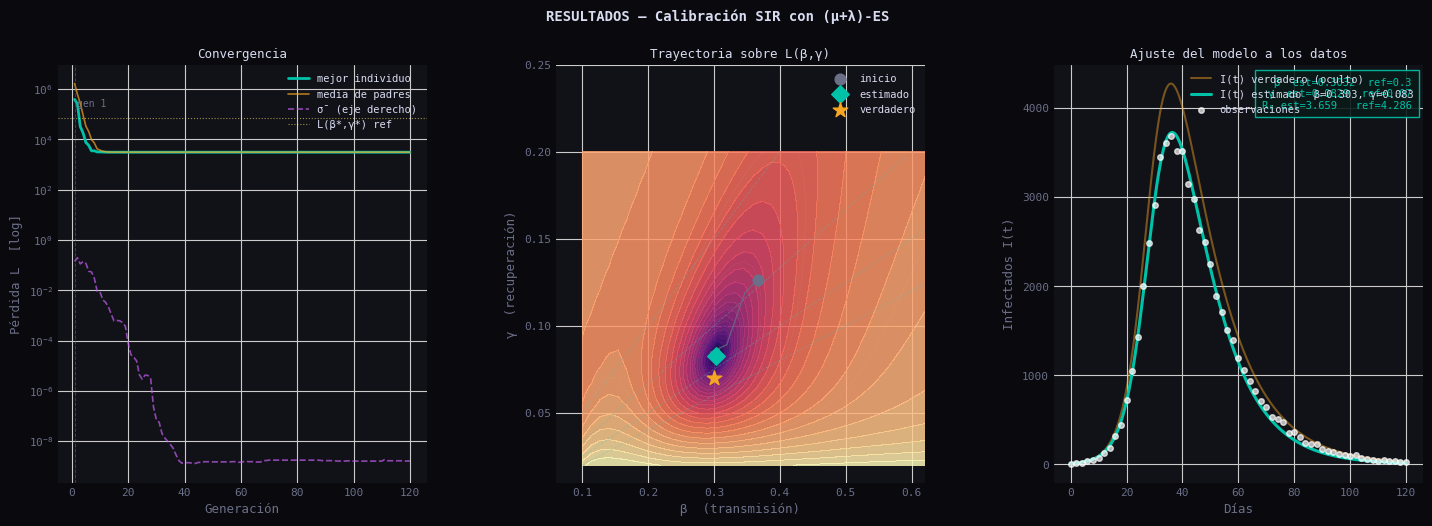


════════════════════════════════════════════════════════════
RESULTADO FINAL
════════════════════════════════════════════════════════════
  Parámetro      Estimado  Verdadero  Error %
  β               0.30325    0.30000    1.08%
  γ               0.08288    0.07000   18.40%
  R₀               3.6590     4.2857   14.62%

  Evaluaciones de L: 9,600  (120 gens × 80 individuos/gen)
  L mínimo:  3102.0504


In [9]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE RESULTADOS
#
# Tres paneles:
#   A. Convergencia del error a lo largo de las generaciones
#   B. Trayectoria de la ES sobre el paisaje L(β,γ)
#   C. Curva SIR estimada vs. datos observados
# ════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 5.5), facecolor=CBKG)
gs  = plt.GridSpec(1, 3, figure=fig,
                   left=0.06, right=0.97,
                   top=0.88, bottom=0.12,
                   wspace=0.35)

ax_conv  = fig.add_subplot(gs[0])   # convergencia
ax_tray  = fig.add_subplot(gs[1])   # trayectoria sobre paisaje
ax_fit   = fig.add_subplot(gs[2])   # curva ajustada

for ax in [ax_conv, ax_tray, ax_fit]:
    ax.set_facecolor(CPANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2A2A3A')
    ax.tick_params(labelsize=8, colors=C_DIM)

fig.suptitle('RESULTADOS — Calibración SIR con (μ+λ)-ES',
             color=C_TXT, fontsize=10, fontweight='bold')

gens = np.arange(1, N_GEN + 1)

# ── Panel A: Convergencia ─────────────────────────────────────────────
ax_conv.semilogy(gens, hist_best_f,  color=C_CYN, lw=2,   label='mejor individuo')
ax_conv.semilogy(gens, hist_mean_f,  color=C_AMB, lw=1.2,
                 alpha=0.7, label='media de padres')
ax_conv.semilogy(gens, hist_sigma,   color=C_LAV, lw=1.2,
                 ls='--', alpha=0.7, label='σ̄ (eje derecho)')

# Línea de referencia: L en el óptimo verdadero
ax_conv.axhline(L_verdadero, color='#FFE566', lw=0.8, ls=':',
                alpha=0.6, label=f'L(β*,γ*) ref')

ax_conv.set_xlabel('Generación', fontsize=9)
ax_conv.set_ylabel('Pérdida L  [log]', fontsize=9)
ax_conv.set_title('Convergencia', fontsize=9, color=C_TXT, pad=5)
ax_conv.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A', loc='upper right')

# Anotar generación donde L < 10 × L_verdadero
for i, lf in enumerate(hist_best_f):
    if lf < 10 * L_verdadero:
        ax_conv.axvline(i + 1, color=C_DIM, lw=0.7, ls='--', alpha=0.5)
        ax_conv.text(i + 2, hist_best_f[0] * 0.5,
                     f'gen {i+1}', color=C_DIM, fontsize=7)
        break

# ── Panel B: Trayectoria sobre el paisaje ────────────────────────────
# Reutilizamos LL_log del paisaje calculado en la celda 3
cf = ax_tray.contourf(BB, GG, LL_log,
                      levels=np.linspace(LL_log.min(), LL_log.max(), 35),
                      cmap='magma', alpha=0.85)
ax_tray.contour(BB, GG, LL_log,
                levels=10, colors='white', linewidths=0.3, alpha=0.1)

# Líneas iso-R₀
for r0 in [2.0, 3.0, 4.0, 5.0]:
    g_line = betas / r0
    mask = (g_line >= gammas.min()) & (g_line <= gammas.max())
    ax_tray.plot(betas[mask], g_line[mask],
                 color='#4DC7BA', lw=0.6, ls='--', alpha=0.35)

# Trayectoria de la ES
tray_b = trayectoria_es[:, 0]
tray_g = trayectoria_es[:, 1]

# Colorear por generación: del gris al cian
n = len(tray_b)
for i in range(n - 1):
    t = i / (n - 1)
    color_t = (
        int(0x6B + t * (0x00 - 0x6B)),
        int(0x6F + t * (0xC2 - 0x6F)),
        int(0x88 + t * (0xA8 - 0x88)),
    )
    hex_c = '#{:02X}{:02X}{:02X}'.format(*color_t)
    ax_tray.plot(tray_b[i:i+2], tray_g[i:i+2],
                 color=hex_c, lw=1.0, alpha=0.7)

# Inicio y fin
ax_tray.scatter(tray_b[0],  tray_g[0],  s=60, color=C_DIM,
                marker='o', zorder=8, label='inicio')
ax_tray.scatter(tray_b[-1], tray_g[-1], s=80, color=C_CYN,
                marker='D', zorder=9, label='estimado')
ax_tray.scatter(BETA_TRUE,  GAMMA_TRUE, s=120, color=C_AMB,
                marker='*', zorder=10, label='verdadero')

ax_tray.set_xlabel('β  (transmisión)', fontsize=9)
ax_tray.set_ylabel('γ  (recuperación)', fontsize=9)
ax_tray.set_title('Trayectoria sobre L(β,γ)', fontsize=9, color=C_TXT, pad=5)
ax_tray.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A', loc='upper right')

# Zoom al área relevante
margin = 0.08
ax_tray.set_xlim(max(0.05, BETA_TRUE - margin * 3),
                 min(0.70, BETA_TRUE + margin * 4))
ax_tray.set_ylim(max(0.01, GAMMA_TRUE - margin * 1.5),
                 min(0.25, GAMMA_TRUE + margin * 2.5))

# ── Panel C: Curva ajustada vs. datos ────────────────────────────────
# Simulamos con los parámetros estimados
t_c, _, I_est, _ = simular_sir(beta_est, gamma_est)

ax_fit.plot(t_cont, I_true, color=C_AMB, lw=1.5, alpha=0.45,
            label='I(t) verdadero (oculto)')
ax_fit.plot(t_c,    I_est,  color=C_CYN, lw=2.2,
            label=f'I(t) estimado  β={beta_est:.3f}, γ={gamma_est:.3f}')
ax_fit.scatter(T_OBS, I_obs, s=16, color='white', alpha=0.7, zorder=5,
               label='observaciones')

ax_fit.set_xlabel('Días', fontsize=9)
ax_fit.set_ylabel('Infectados I(t)', fontsize=9)
ax_fit.set_title('Ajuste del modelo a los datos', fontsize=9, color=C_TXT, pad=5)
ax_fit.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
              edgecolor='#2A2A3A')

# Tabla resumen
tabla = (f"β  est={beta_est:.4f}  ref={BETA_TRUE}\n"
         f"γ  est={gamma_est:.4f}  ref={GAMMA_TRUE}\n"
         f"R₀ est={R0_est:.3f}   ref={R0_TRUE:.3f}")
ax_fit.text(0.97, 0.97, tabla,
            transform=ax_fit.transAxes, ha='right', va='top',
            color=C_CYN, fontsize=7.5, family='monospace',
            bbox=dict(facecolor='#0A1A18', edgecolor=C_CYN, alpha=0.9, pad=5))

plt.show()

# ── Resumen numérico final ────────────────────────────────────────────

print("\n" + "═" * 60)
print("RESULTADO FINAL")
print("═" * 60)
print(f"  {'Parámetro':12s} {'Estimado':>10s} {'Verdadero':>10s} {'Error %':>8s}")
print(f"  {'β':12s} {beta_est:>10.5f} {BETA_TRUE:>10.5f} "
      f"{abs(beta_est-BETA_TRUE)/BETA_TRUE*100:>7.2f}%")
print(f"  {'γ':12s} {gamma_est:>10.5f} {GAMMA_TRUE:>10.5f} "
      f"{abs(gamma_est-GAMMA_TRUE)/GAMMA_TRUE*100:>7.2f}%")
print(f"  {'R₀':12s} {R0_est:>10.4f} {R0_TRUE:>10.4f} "
      f"{abs(R0_est-R0_TRUE)/R0_TRUE*100:>7.2f}%")
print(f"\n  Evaluaciones de L: {N_GEN * (MU + LAM):,}  "
      f"({N_GEN} gens × {MU+LAM} individuos/gen)")
print(f"  L mínimo:  {hist_best_f[-1]:.4f}")


#### Análisis de resultados

La estrategia evolutiva $(\mu+\lambda)$ se utilizó para calibrar los parámetros del modelo SIR a partir de datos observados de infectados.  
El algoritmo explora el espacio de parámetros $(\beta,\gamma)$ mediante mutaciones gaussianas con **autoadaptación lognormal de los tamaños de paso**.

Después de **120 generaciones** (9600 evaluaciones de la función objetivo), el algoritmo encontró la siguiente estimación:

| Parámetro | Estimado | Verdadero | Error |
|-----------|----------|-----------|-------|
| $\beta$ | 0.303 | 0.300 | 1.08% |
| $\gamma$ | 0.083 | 0.070 | 18.40% |
| $R_0=\beta/\gamma$ | 3.66 | 4.29 | 14.62% |

Observamos que el algoritmo recupera **muy bien el parámetro de transmisión $\beta$**, mientras que el parámetro de recuperación $\gamma$ presenta un error mayor.

Esto ocurre porque en el modelo SIR ambos parámetros están **fuertemente correlacionados**: diferentes combinaciones de $(\beta,\gamma)$ pueden producir curvas epidemiológicas muy similares.

En consecuencia, el problema presenta **identificabilidad imperfecta**, lo que genera un paisaje de pérdida con una **región alargada de soluciones casi equivalentes**.


La gráfica de la izquierda muestra la evolución de la función de pérdida durante la optimización.

Se observan tres elementos importantes:

- **Mejor individuo**: desciende rápidamente durante las primeras generaciones.
- **Media de los padres**: sigue una tendencia similar, indicando convergencia poblacional.
- **$\bar{\sigma}$ (tamaño de paso medio)**: disminuye progresivamente, reflejando la autoadaptación del algoritmo.

Este comportamiento es típico de las Estrategias Evolutivas:

1. exploración amplia al inicio  
2. reducción progresiva del tamaño de mutación  
3. refinamiento local alrededor del óptimo


La gráfica central muestra el **paisaje de pérdida $L(\beta,\gamma)$** junto con la trayectoria del mejor individuo a lo largo de la optimización.

Se observan tres puntos clave:

- punto inicial de la búsqueda
- parámetro verdadero del modelo
- solución estimada por la ES

El contorno del paisaje revela una **estructura en forma de valle o cresta inclinada**.  
Esto significa que múltiples combinaciones de $(\beta,\gamma)$ producen pérdidas similares.

El algoritmo primero **se mueve rápidamente hacia la región de baja pérdida**, y posteriormente **se desplaza a lo largo de la cresta del paisaje** hasta estabilizarse cerca del mínimo.

Este comportamiento explica por qué el algoritmo puede estimar bien $\beta$ pero no recuperar exactamente $\gamma$.


La gráfica de la derecha compara:

- datos observados (con ruido)
- curva generada por el modelo con parámetros estimados
- curva del modelo verdadero (oculto)

A pesar de las diferencias en los parámetros, el modelo calibrado reproduce **muy bien la dinámica del brote**:

- crecimiento inicial
- momento del pico
- descenso posterior

Esto demuestra que **diferentes combinaciones de parámetros pueden explicar adecuadamente los datos**, lo cual es una característica común en la calibración de modelos epidemiológicos.

---

#### Conclusiones

Este experimento ilustra varias propiedades importantes de las Estrategias Evolutivas:

1. **Capacidad de optimización en paisajes complejos**  
   La ES encuentra rápidamente regiones de baja pérdida incluso cuando el paisaje presenta correlaciones entre parámetros.

2. **Autoadaptación efectiva de los tamaños de paso**  
   La reducción progresiva de $\sigma$ permite pasar de exploración global a refinamiento local.

3. **Robustez frente a problemas de identificabilidad**  
   Aunque el algoritmo no recupera exactamente todos los parámetros, encuentra combinaciones que reproducen correctamente la dinámica observada.

4. **Interpretación geométrica del proceso de búsqueda**  
   La trayectoria sobre el paisaje muestra cómo la población evolutiva se desplaza hacia regiones de menor pérdida y luego explora las crestas del paisaje.

En conjunto, este ejercicio muestra cómo las Estrategias Evolutivas pueden utilizarse para **calibrar modelos dinámicos cuando el paisaje de optimización es irregular, correlacionado o difícil de derivar analíticamente**.

----

## 6. Estrategias Evolutivas $(\mu, \lambda)$-ES

$(\mu + \lambda)$-ES garantiza que los mejores individuos encontrados nunca se descarten. Aunque el elitismo suena deseable, esconde un problema estructural que se vuelve visible en paisajes complejos: Cuando un individuo excepcionalmente bueno entra en la población, la autoadaptación de $\sigma$ que lleva consigo tenderá a propagarse a sus descendientes. Si ese individuo se encuentra en el fondo de un mínimo local, sus $\sigma$ reducidos contaminan a las generaciones siguientes con un sesgo hacia la explotación local. El algoritmo queda atrapado en la memoria de una buena solución pasada.

Para resolver este problema potencial, la estrategia $(\mu, \lambda)$-ES elimina el criterio de elitismo: cada generación se construye únicamenrte a partir de los $\lambda$ hijos, es decir, **los padres no participan en la selección**; La función de los $\mu$ individuos de la generación actual es producir la generación que los reemplazará:

$$
\text{Población}_{t+1} =
\text{seleccionar}_{\mu \text{ mejores}}
\left(
\underbrace{\mathcal{O}_t}_{\lambda \text{ hijos}}
\right)
\qquad \lambda > \mu
$$

Ahora, la condición $\lambda > \mu$ es virtualmente obligatoria: si se producen tantos hijos como padres o menos, la selección no ejercería ninguna presión y el algoritmo degeneraría. En la práctica se recomienda la relación $\lambda / \mu \approx 7$, como antes, sólo que ahora se vuelve fundamental.

La consecuencia más importante de este esquema es que los parámetros de estrategia $\sigma$ pueden aumentar drásticamente. En $(\mu + \lambda)$-ES, un padre con $\sigma$ pequeño sobrevive indefinidamente si su fitness es alto, frenando la exploración. En $(\mu, \lambda)$-ES, ese padre desaparece en la siguiente generación: sus hijos heredan $\sigma$s mutados, y si el paisaje exige mutaciones más grandes, los individuos con $\sigma$ más alto serán seleccionados. La población olvida *deliberadamente* el pasado para adaptarse al nuevo paisaje local.

Este olvido tiene un costo importante: $(\mu, \lambda)$-ES puede perder temporalmente la mejor solución encontrada. En términos teóricos, no garantiza monotonicidad en la convergencia. Pero ese coste se compensa dos ventajas difíciles de obtener de otra forma: **mayor capacidad de escapar de mínimos locales** y **seguimiento de óptimos móviles** en problemas dinámicos donde la función objetivo cambia con el tiempo.


### Comparación entre $(\mu, \lambda)$ y  $(\mu + \lambda)$

Las Estrategias Evolutivas distinguen entre dos grupos de individuos: padres e hijos, y la diferencia entre variantes es la forma en que participan en la definición de la nueva generación. En una estrategia $(\mu, \lambda)$ los padres compiten con sus descendientes por sobrevivir, produciendo un comportamiento elitista y estable. En contraste, en una estrategia $(\mu + \lambda)$ sólo los hijos pueden sobrevivir, lo que introduce mayor exploración y presión evolutiva.

<p align="center">
  <img src="images/EE_comparacion.png" width="800">
</p>

>**NFL-T:** Ninguna elección es universalmente mejor que la otra — todo depende de la forma del paisaje de búsqueda, de los parámetros elegidos y, en aplicaciones modernas, de las heurísticas que complementen o extiendan el algoritmo base. Este es precisamente el mensaje central de las metaheurísticas: las variantes canónicas son puntos de partida, no recetas. Un método aparentemente más simple puede superar a uno más sofisticado si se entiende bien qué restricción está limitando el desempeño — y se tiene la creatividad para atacarla.

Comparemos las formas canónicas de estas variantes sobre la función de Rosenbrock:

In [10]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN COMPARATIVA: (μ+λ)-ES vs. (μ,λ)-ES
#
# Objetivo: mostrar visualmente la diferencia en presión selectiva
# y comportamiento de convergencia entre los dos esquemas.
# Función de prueba: Rosenbrock 2D (conocida de la sección anterior)
# ════════════════════════════════════════════════════════════════════════

def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100*(y - x**2)**2


def ee_step(padres, sigma_padres, mu, lam, modo='plus', rng_local=None):
    """
    Una generación de EE con autoadaptación lognormal isótropa (σ escalar).
    modo: 'plus'  → (μ+λ): selección de padres ∪ hijos
          'comma' → (μ,λ): selección solo de hijos
    """
    n = padres.shape[1]
    tau = 1 / np.sqrt(2 * n)  # parámetro lognormal global

    # ── Generar λ hijos ──────────────────────────────────────────────
    hijos = np.zeros((lam, n))
    sigma_hijos = np.zeros(lam)

    for k in range(lam):
        # Seleccionar padre al azar (recombinación uniforme implícita)
        idx = rng_local.integers(0, mu)
        padre = padres[idx]
        s = sigma_padres[idx]

        # Autoadaptación de σ
        s_new = max(s * np.exp(tau * rng_local.standard_normal()), 1e-6)
        sigma_hijos[k] = s_new

        # Mutación gaussiana
        hijos[k] = padre + s_new * rng_local.standard_normal(n)

    # ── Selección ─────────────────────────────────────────────────────
    if modo == 'plus':
        pool_x = np.vstack([padres, hijos])
        pool_s = np.concatenate([sigma_padres, sigma_hijos])
    else:  # comma
        pool_x = hijos
        pool_s = sigma_hijos

    fitness = np.array([rosenbrock(ind) for ind in pool_x])
    idx_sorted = np.argsort(fitness)[:mu]  # minimizamos

    return pool_x[idx_sorted], pool_s[idx_sorted], fitness[idx_sorted[0]]


def run_ee(mu, lam, modo, n_gen=150, seed=42):
    """Ejecuta una EE completa y devuelve historial de convergencia."""
    rng_local = np.random.default_rng(seed)
    padres = rng_local.uniform(-2, 2, (mu, 2))
    sigma  = np.full(mu, 0.5)
    hist_fitness = []
    hist_sigma   = []
    hist_best    = []

    for _ in range(n_gen):
        padres, sigma, best_f = ee_step(padres, sigma, mu, lam, modo, rng_local)
        hist_fitness.append(best_f)
        hist_sigma.append(sigma.mean())
        hist_best.append(padres[0].copy())

    return np.array(hist_fitness), np.array(hist_sigma), np.array(hist_best)


# ── Ejecutar los cuatro escenarios ────────────────────────────────────
MU, LAM = 5, 35  # ratio 7:1 clásico
N_GEN   = 150
SEED = 42

f_plus,  s_plus,  traj_plus  = run_ee(MU, LAM, 'plus',  N_GEN, SEED)
f_comma, s_comma, traj_comma = run_ee(MU, LAM, 'comma', N_GEN, SEED)

print(f'(μ+λ)-ES: mejor f = {f_plus[-1]:.12f}  |  σ final = {s_plus[-1]:.8f}')
print(f'(μ,λ)-ES: mejor f = {f_comma[-1]:.12f}  |  σ final = {s_comma[-1]:.8f}')


(μ+λ)-ES: mejor f = 0.000000001759  |  σ final = 0.00118197
(μ,λ)-ES: mejor f = 0.000000003228  |  σ final = 0.00000110


De acuerdo con estos resultados, ambas variantes alcanzan valores de fitness prácticamente indistinguibles (~10⁻⁹), y la
diferencia más visible es el paso de mutación final:

| Variante | f* final | σ̄ final |
|---|---|---|
| (μ+λ)-ES | ~1.8×10⁻⁹ | ~1.2×10⁻³ |
| (μ,λ)-ES | ~3.2×10⁻⁹ | ~1.1×10⁻⁶ |

$(\mu, \lambda)$-ES llega al óptimo con un $\sigma$ tres órdenes de magnitud menor. Esto es consecuencia de eliminar el elitismo: sin padres que "anclen" el paso de mutación en el pool de selección, los hijos que sobreviven son aquellos que redujeron agresivamente $\sigma$ al acercarse al óptimo. La autoadaptación opera sin el freno conservador que introduce el elitismo.

Ahora, ¿qué ocurre si cambiamos la semilla del proceso aleatorio? ¿El resultado es el consistente? 

Haciendo otros experimentos con otros valores de semilla, con 150 generaciones, $\mu=5$ y $\lambda=35$. Obtenemos los siguientes resultados:

**Tabla 1 — Calidad de la solución final**

| Semilla | Variante | f\* final | σ̄ final |
|:---:|---|---:|---:|
| 42 | (μ+λ)-ES | 1.76×10⁻⁹ | 1.18×10⁻³ |
| | (μ,λ)-ES | 3.23×10⁻⁹ | 1.10×10⁻⁶ |
| 7 | (μ+λ)-ES | 2.59×10⁻⁸ | 3.08×10⁻⁵ |
| | (μ,λ)-ES | 2.24×10⁻³ | 7.65×10⁻⁴ |
| 13 | (μ+λ)-ES | 2.70×10⁻¹³ | 3.66×10⁻⁶ |
| | (μ,λ)-ES | 3.27×10⁻³ | 1.00×10⁻³ |
| 99 | (μ+λ)-ES | 3.41×10⁻⁸ | 9.84×10⁻⁶ |
| | (μ,λ)-ES | 9.37×10⁻³ | 1.27×10⁻³ |
| 2024 | (μ+λ)-ES | 2.46×10⁻¹¹ | 1.58×10⁻⁶ |
| | (μ,λ)-ES | 3.12×10⁻³ | 7.14×10⁻⁴ |


**Tabla 2 — Velocidad de convergencia**: Generación en que f\* cruza cada umbral de calidad (>150 = no convergió)

| Semilla | Variante | f < 10⁻² | f < 10⁻⁴ | f < 10⁻⁶ | f < 10⁻⁸ |
|:---:|---|:---:|:---:|:---:|:---:|
| 42 | (μ+λ)-ES | 4 | 8 | 66 | 150 |
| | (μ,λ)-ES | 5 | 9 | 17 | **83** |
| 7 | (μ+λ)-ES | 14 | 53 | 86 | >150 |
| | (μ,λ)-ES | 48 | >150 | >150 | >150 |
| 13 | (μ+λ)-ES | 10 | 37 | 65 | **71** |
| | (μ,λ)-ES | 89 | >150 | >150 | >150 |
| 99 | (μ+λ)-ES | 43 | 109 | 124 | >150 |
| | (μ,λ)-ES | 142 | >150 | >150 | >150 |
| 2024 | (μ+λ)-ES | 31 | 47 | 54 | **100** |
| | (μ,λ)-ES | 89 | >150 | >150 | >150 |

> **Nota — semilla 42:** es la única corrida donde (μ,λ) no solo converge
> sino que alcanza f < 10⁻⁸ más rápido (gen 83 vs 150). En las otras
> cuatro semillas (μ,λ) no cruza 10⁻⁴. Una sola corrida puede dar
> una imagen completamente distinta del comportamiento típico.

En este y otros benchmarks $(\mu+ \lambda)$ resulta claramente superior a $(\mu, \lambda)$, ¿entonces por qué es esta última el estándar en la literatura?

Veamos otro caso, el ejemplo SIR.

----

### Estrategia Evolutiva $(\mu,\lambda)$ para calibrar el modelo SIR

La tarea de optimización es la que ya conocemos: Dado un vector de observaciones ruidosas de personas infectadas $\hat I_t$, buscamos los parámetros que minimizan el error entre el modelo SIR y los datos observados:

$$
(\beta^*, \gamma^*) =
\arg\min_{\beta,\gamma} \; \mathcal{L}(\beta,\gamma)
$$

donde

$$
\mathcal{L}(\beta,\gamma)
=
\sum_t
\left(
I(t;\beta,\gamma)-\hat I_t
\right)^2
$$

estima el error entre la solución del modelo SIR, $I(t)$, y la serie de observaciones $\hat I_t$.

La representación del individuo es idéntica a la variante anterior: cada candidato lleva los parámetros del modelo junto con sus propias escalas de mutación,

$$
x = (\beta,\,\gamma,\,\sigma_\beta,\,\sigma_\gamma)
$$


Lo que cambia en este ejercicio es **la regla de selección**: en cada generación, los $\mu$ padres son descartados por completo y la siguiente población se elige exclusivamente entre los $\lambda$ hijos.

---

Como antes, el ciclo de una generación tiene cuatro pasos:

**1. Autoadaptación de $\sigma$.**  Cada hijo muta primero sus propios tamaños de paso mediante perturbación lognormal:

$$
\sigma_i' = \sigma_i \cdot \exp\!\left(\tau'\,\mathcal{N}(0,1) + \tau\,\mathcal{N}_i(0,1)\right)
$$

con $\tau' = \tfrac{1}{\sqrt{2n}}$ y $\tau = \tfrac{1}{\sqrt{2\sqrt{n}}}$, siendo $n=2$ para este caso.

**2. Mutación de parámetros.** Con los $\sigma'$ recién generados se perturban los parámetros del modelo:

$$
\mathbf{x}' = \mathbf{x} + \boldsymbol{\sigma}' \odot \mathbf{z},
\qquad \mathbf{z} \sim \mathcal{N}(0,\mathbf{I})
$$

**3. Evaluación.** Cada hijo se simula integrando el sistema SIR y se compara con los datos observados:

$$
\mathcal{L}(\beta,\gamma) = \sum_t \left(I(t;\beta,\gamma) - \hat{I}_t\right)^2
$$

**4. Selección $(\mu,\lambda)$.** Se conservan los $\mu$ hijos con menor $\mathcal{L}$. Los padres no participan.

$$
\text{Población}_{t+1} = \text{seleccionar}_{\mu\,\text{mejores}}\!\left(\mathcal{O}_t\right)
$$


---

El problema de calibración es el mismo — mismos datos, misma función objetivo, misma representación — pero el cambio de operador de selección tiene consecuencias concretas sobre la forma en que el algoritmo navega el paisaje de pérdida.

**El paisaje SIR tiene una cresta diagonal.** La región de mínimo se extiende a lo largo de combinaciones $(\beta,\gamma)$ con $R_0 = \beta/\gamma$ aproximadamente constante. Dentro de esa cresta, el gradiente es suave y la identificabilidad es imperfecta: muchos puntos tienen error similar. Este tipo de paisaje es precisamente donde el elitismo de $(\mu +\lambda)$-ES puede ser perjudicial: un padre que cae en la cresta con $\sigma$ ya reducidos puede bloquear la exploración transversal durante muchas generaciones.

$(\mu,\lambda)$-ES responde de otra forma. Como los padres se descartan en cada generación, los $\sigma$ no quedan congelados en valores pequeños: si la cresta requiere pasos más largos para moverse a lo largo de ella, los individuos con $\sigma$ más grandes tienen más posibilidades de producir hijos competitivos y esos tamaños de paso se propagan. El algoritmo puede renegociar su escala de exploración en cada generación.

En la práctica, esto se traduce en tres diferencias observables respecto a los resultados anteriores:

- **Convergencia inicial más lenta.** Sin elitismo, las primeras generaciones son más exploratorias y la pérdida puede no caer tan rápido como en la $(\mu +\lambda)$-ES.
- **Mayor movilidad sobre la cresta.** La trayectoria sobre el paisaje $L(\beta,\gamma)$ muestra desplazamientos más amplios a lo largo de la diagonal, lo que puede mejorar la estimación de $\gamma$ — el parámetro más difícil de recuperar.
- **$\sigma$ que puede crecer.** A diferencia del caso anterior, la curva de $\bar{\sigma}$ no es monotónicamente decreciente: puede subir en etapas donde el algoritmo necesita reexplorar.

El parámetro  $\lambda/\mu$ adquiere aquí un papel especialmente importante. Un ratio bajo (por ejemplo $\lambda/\mu = 3$) ejerce poca presión selectiva y la población deriva sin converger; una relación alta (por ejemplo $\lambda/\mu = 10$ o más) puede acelerar la convergencia pero reduce la diversidad. Para este problema se mantiene la tasa $\lambda/\mu = 7$ utilizado en la variante anterior, lo que permite una comparación directa entre los dos esquemas.

In [11]:
# ════════════════════════════════════════════════════════════════════════
# (μ,λ)-ES  CALIBRANDO EL MODELO SIR
#
# Ejecutamos la ES con autoadaptación lognormal y registramos la
# trayectoria completa para poder visualizar cómo navega el paisaje.
# ════════════════════════════════════════════════════════════════════════

# ── Parámetros de la ES ───────────────────────────────────────────────
MU      = 10         # tamaño de la población de padres
LAM     = 70         # hijos por generación  (ratio 7:1)
N_GEN   = 120        # generaciones máximas
N_DIM   = 2          # β y γ
TAU       = 1 / np.sqrt(2 * np.sqrt(N_DIM)) # ruido local por dimensión
TAU_PRIME = 1 / np.sqrt(2 * N_DIM)          # ruido global

# Dominio de búsqueda
LIMITES = np.array([[0.05, 1.00],   # β
                    [0.01, 0.50]])  # γ

SIGMA0  = 0.15       # σ inicial (isótropo)
SEED    = 42

# ── Inicialización ────────────────────────────────────────────────────
rng_es = np.random.default_rng(seed=SEED)

# Población inicial distribuida por el dominio
padres = rng_es.uniform(LIMITES[:, 0], LIMITES[:, 1], size=(MU, N_DIM))
sigmas = np.full((MU, N_DIM), SIGMA0)

# ── Historial para visualización ──────────────────────────────────────
hist_best_f  = []   # mejor fitness por generación
hist_mean_f  = []   # fitness medio de los hijos
hist_sigma   = []   # σ medio de los padres seleccionados
hist_best_xy = []   # (β*, γ*) por generación

# ── Bucle principal ───────────────────────────────────────────────────
print(f"Ejecutando (μ={MU},λ={LAM})-ES\n{N_GEN} generaciones\n")
print(f"τ = {TAU:.4f}\nσ₀ = {SIGMA0}")
print("\n" + "═" * 80)

for gen in range(N_GEN):

    # ── 1. REPRODUCCIÓN ──────────────────────────────────────────────
    hijos   = np.zeros((LAM, N_DIM))
    sig_hij = np.zeros((LAM, N_DIM))

    for k in range(LAM):

        idx = rng_es.integers(0, MU)

        x_parent = padres[idx]
        s_parent = sigmas[idx]

        # ruido global
        z_global = rng_es.standard_normal()

        # ruido local
        z_local = rng_es.standard_normal(N_DIM)

        # autoadaptación lognormal completa
        s_new = s_parent * np.exp(
            TAU_PRIME * z_global +
            TAU * z_local
        )

        s_new = np.maximum(s_new, 1e-9)

        sig_hij[k] = s_new

        # mutación
        z = rng_es.standard_normal(N_DIM)

        hijo = x_parent + s_new * z

        hijos[k] = hijo

    # ── 2. EVALUACIÓN — solo hijos (μ,λ) ─────────────────────────────
    pool_x  = hijos       # ← solo hijos; padres descartados
    pool_s  = sig_hij
    fitness = np.array([funcion_objetivo(ind) for ind in pool_x])

    # ── 3. SELECCIÓN por truncamiento ─────────────────────────────────
    orden   = np.argsort(fitness)
    sel_idx = orden[:MU]

    padres = pool_x[sel_idx]
    sigmas = pool_s[sel_idx]

    # ── 4. Registro ───────────────────────────────────────────────────
    best_f = fitness[sel_idx[0]]
    hist_best_f.append(best_f)
    hist_mean_f.append(fitness.mean())        # ← media de los LAM hijos
    hist_sigma.append(sigmas.mean())
    hist_best_xy.append(padres[0].copy())

    # Reporte cada 20 generaciones
    if (gen + 1) % 20 == 0 or gen == 0:
        b, g = padres[0]
        print(f"  gen {gen+1:3d}  |  L = {best_f:10.2f}  "
              f"|  β={b:.4f}  γ={g:.4f}  "
              f"|  R₀={b/g:.2f}  |  σ̄={sigmas.mean():.5f}")

# ── Resultado final ────────────────────────────────────────────────────
beta_est, gamma_est = padres[0]
R0_est = beta_est / gamma_est

# Guardar trayectoria para la celda siguiente
trayectoria_es = np.array(hist_best_xy)

Ejecutando (μ=10,λ=70)-ES
120 generaciones

τ = 0.5946
σ₀ = 0.15

════════════════════════════════════════════════════════════════════════════════
  gen   1  |  L =  391652.14  |  β=0.3661  γ=0.1265  |  R₀=2.90  |  σ̄=0.15592
  gen  20  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00001
  gen  40  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen  60  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen  80  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen 100  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000
  gen 120  |  L =    3102.05  |  β=0.3032  γ=0.0829  |  R₀=3.66  |  σ̄=0.00000


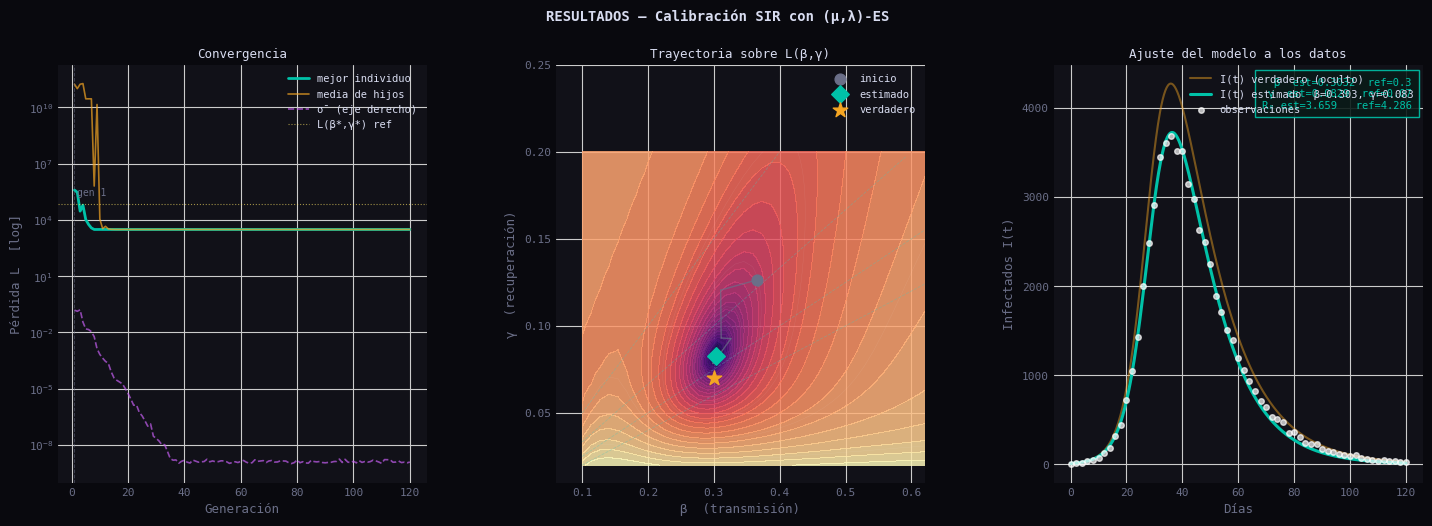


════════════════════════════════════════════════════════════
RESULTADO FINAL
════════════════════════════════════════════════════════════
  Parámetro      Estimado  Verdadero  Error %
  β               0.30325    0.30000    1.08%
  γ               0.08288    0.07000   18.40%
  R₀               3.6590     4.2857   14.62%
  Evaluaciones de L: 8,400  (120 gens × 70 hijos/gen)
  L mínimo:  3102.0504


In [12]:
# ════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE RESULTADOS
#
# Tres paneles:
#   A. Convergencia del error a lo largo de las generaciones
#   B. Trayectoria de la ES sobre el paisaje L(β,γ)
#   C. Curva SIR estimada vs. datos observados
# ════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 5.5), facecolor=CBKG)
gs  = plt.GridSpec(1, 3, figure=fig,
                   left=0.06, right=0.97,
                   top=0.88, bottom=0.12,
                   wspace=0.35)

ax_conv  = fig.add_subplot(gs[0])   # convergencia
ax_tray  = fig.add_subplot(gs[1])   # trayectoria sobre paisaje
ax_fit   = fig.add_subplot(gs[2])   # curva ajustada

for ax in [ax_conv, ax_tray, ax_fit]:
    ax.set_facecolor(CPANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2A2A3A')
    ax.tick_params(labelsize=8, colors=C_DIM)

fig.suptitle('RESULTADOS — Calibración SIR con (μ,λ)-ES',
             color=C_TXT, fontsize=10, fontweight='bold')

gens = np.arange(1, N_GEN + 1)

# ── Panel A: Convergencia ─────────────────────────────────────────────
ax_conv.semilogy(gens, hist_best_f,  color=C_CYN, lw=2,   label='mejor individuo')
ax_conv.semilogy(gens, hist_mean_f,  color=C_AMB, lw=1.2,
                 alpha=0.7, label='media de hijos')          # ← "padres" → "hijos"
ax_conv.semilogy(gens, hist_sigma,   color=C_LAV, lw=1.2,
                 ls='--', alpha=0.7, label='σ̄ (eje derecho)')

# Línea de referencia: L en el óptimo verdadero
ax_conv.axhline(L_verdadero, color='#FFE566', lw=0.8, ls=':',
                alpha=0.6, label=f'L(β*,γ*) ref')

ax_conv.set_xlabel('Generación', fontsize=9)
ax_conv.set_ylabel('Pérdida L  [log]', fontsize=9)
ax_conv.set_title('Convergencia', fontsize=9, color=C_TXT, pad=5)
ax_conv.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A', loc='upper right')

# Anotar generación donde L < 10 × L_verdadero
for i, lf in enumerate(hist_best_f):
    if lf < 10 * L_verdadero:
        ax_conv.axvline(i + 1, color=C_DIM, lw=0.7, ls='--', alpha=0.5)
        ax_conv.text(i + 2, hist_best_f[0] * 0.5,
                     f'gen {i+1}', color=C_DIM, fontsize=7)
        break

# ── Panel B: Trayectoria sobre el paisaje ────────────────────────────
# Reutilizamos LL_log del paisaje calculado en la celda 3
cf = ax_tray.contourf(BB, GG, LL_log,
                      levels=np.linspace(LL_log.min(), LL_log.max(), 35),
                      cmap='magma', alpha=0.85)
ax_tray.contour(BB, GG, LL_log,
                levels=10, colors='white', linewidths=0.3, alpha=0.1)

# Líneas iso-R₀
for r0 in [2.0, 3.0, 4.0, 5.0]:
    g_line = betas / r0
    mask = (g_line >= gammas.min()) & (g_line <= gammas.max())
    ax_tray.plot(betas[mask], g_line[mask],
                 color='#4DC7BA', lw=0.6, ls='--', alpha=0.35)

# Trayectoria de la ES
tray_b = trayectoria_es[:, 0]
tray_g = trayectoria_es[:, 1]

# Colorear por generación: del gris al cian
n = len(tray_b)
for i in range(n - 1):
    t = i / (n - 1)
    color_t = (
        int(0x6B + t * (0x00 - 0x6B)),
        int(0x6F + t * (0xC2 - 0x6F)),
        int(0x88 + t * (0xA8 - 0x88)),
    )
    hex_c = '#{:02X}{:02X}{:02X}'.format(*color_t)
    ax_tray.plot(tray_b[i:i+2], tray_g[i:i+2],
                 color=hex_c, lw=1.0, alpha=0.7)

# Inicio y fin
ax_tray.scatter(tray_b[0],  tray_g[0],  s=60, color=C_DIM,
                marker='o', zorder=8, label='inicio')
ax_tray.scatter(tray_b[-1], tray_g[-1], s=80, color=C_CYN,
                marker='D', zorder=9, label='estimado')
ax_tray.scatter(BETA_TRUE,  GAMMA_TRUE, s=120, color=C_AMB,
                marker='*', zorder=10, label='verdadero')

ax_tray.set_xlabel('β  (transmisión)', fontsize=9)
ax_tray.set_ylabel('γ  (recuperación)', fontsize=9)
ax_tray.set_title('Trayectoria sobre L(β,γ)', fontsize=9, color=C_TXT, pad=5)
ax_tray.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A', loc='upper right')

# Zoom al área relevante
margin = 0.08
ax_tray.set_xlim(max(0.05, BETA_TRUE - margin * 3),
                 min(0.70, BETA_TRUE + margin * 4))
ax_tray.set_ylim(max(0.01, GAMMA_TRUE - margin * 1.5),
                 min(0.25, GAMMA_TRUE + margin * 2.5))

# ── Panel C: Curva ajustada vs. datos ────────────────────────────────
# Simulamos con los parámetros estimados
t_c, _, I_est, _ = simular_sir(beta_est, gamma_est)

ax_fit.plot(t_cont, I_true, color=C_AMB, lw=1.5, alpha=0.45,
            label='I(t) verdadero (oculto)')
ax_fit.plot(t_c,    I_est,  color=C_CYN, lw=2.2,
            label=f'I(t) estimado  β={beta_est:.3f}, γ={gamma_est:.3f}')
ax_fit.scatter(T_OBS, I_obs, s=16, color='white', alpha=0.7, zorder=5,
               label='observaciones')

ax_fit.set_xlabel('Días', fontsize=9)
ax_fit.set_ylabel('Infectados I(t)', fontsize=9)
ax_fit.set_title('Ajuste del modelo a los datos', fontsize=9, color=C_TXT, pad=5)
ax_fit.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
              edgecolor='#2A2A3A')

# Tabla resumen
tabla = (f"β  est={beta_est:.4f}  ref={BETA_TRUE}\n"
         f"γ  est={gamma_est:.4f}  ref={GAMMA_TRUE}\n"
         f"R₀ est={R0_est:.3f}   ref={R0_TRUE:.3f}")
ax_fit.text(0.97, 0.97, tabla,
            transform=ax_fit.transAxes, ha='right', va='top',
            color=C_CYN, fontsize=7.5, family='monospace',
            bbox=dict(facecolor='#0A1A18', edgecolor=C_CYN, alpha=0.9, pad=5))

plt.show()

# ── Resumen numérico final ────────────────────────────────────────────

print("\n" + "═" * 60)
print("RESULTADO FINAL")
print("═" * 60)
print(f"  {'Parámetro':12s} {'Estimado':>10s} {'Verdadero':>10s} {'Error %':>8s}")
print(f"  {'β':12s} {beta_est:>10.5f} {BETA_TRUE:>10.5f} "
      f"{abs(beta_est-BETA_TRUE)/BETA_TRUE*100:>7.2f}%")
print(f"  {'γ':12s} {gamma_est:>10.5f} {GAMMA_TRUE:>10.5f} "
      f"{abs(gamma_est-GAMMA_TRUE)/GAMMA_TRUE*100:>7.2f}%")
print(f"  {'R₀':12s} {R0_est:>10.4f} {R0_TRUE:>10.4f} "
      f"{abs(R0_est-R0_TRUE)/R0_TRUE*100:>7.2f}%")
print(f"  Evaluaciones de L: {N_GEN * LAM:,}  "            # ← (MU + LAM) → LAM
      f"({N_GEN} gens × {LAM} hijos/gen)")
print(f"  L mínimo:  {hist_best_f[-1]:.4f}")


#### Conclusiones

En este experimento, ambas variantes de Estrategias Evolutivas, $(\mu +\lambda)$-ES y $(\mu,\lambda)$-ES, convergen al mismo punto del paisaje de pérdida prácticamente al mismo tiempo y con el mismo tamaño de paso medio final $\bar{\sigma}$.

La única diferencia observable es el costo computacional:

| | (μ+λ)-ES | (μ,λ)-ES |
|---|---:|---:|
| Evaluaciones de L | 9,600 | **8,400** |
| Ahorro | — | **12.5 %** |
| β estimado | 0.30325 | 0.30325 |
| γ estimado | 0.08288 | 0.08288 |
| L mínimo | 3102.05 | 3102.05 |

En este problema particular, **$(\mu,\lambda)$ resulta ligeramente más eficiente**, ya que alcanza la misma solución con menos evaluaciones de la función objetivo.

Esto ocurre porque la convergencia sucede muy temprano (antes de la generación 20), por lo que el elitismo de $(\mu+\lambda)$ nunca llega a desempeñar un papel relevante: en ningún momento es necesario “rescatar” una solución buena de generaciones anteriores.

Sin embargo, esto no significa que $(\mu,\lambda)$ sea siempre superior. En problemas más difíciles, el elitismo puede evitar que el algoritmo pierda accidentalmente soluciones de alta calidad.

¿Por qué, entonces, $(\mu,\lambda)$ es el esquema clásico en Estrategias Evolutivas? Históricamente, la literatura sobre Estrategias Evolutivas ha favorecido la variante $(\mu,\lambda)$ por dos razones principales.

**1. Propiedades teóricas más limpias**

Las versiones no elitistas son más fáciles de analizar matemáticamente.  En particular, el esquema $(\mu,\lambda)$ permite modelar la dinámica evolutiva como un proceso estocástico con menos dependencias entre generaciones. Esto facilita el análisis de convergencia y el estudio de propiedades de punto fijo de la adaptación del tamaño de paso [Beyer & Schwefel (2002)](https://gwern.net/doc/reinforcement-learning/model-free/2002-beyer.pdf).

**2. Mayor robustez en entornos ruidosos**

En muchos problemas reales la función objetivo no es determinista. En estos contextos, el elitismo puede ser problemático. Un individuo puede parecer excepcional simplemente por haber recibido una **evaluación ruidosa favorable**, y el esquema $(\mu+\lambda)$ puede preservar esa solución durante muchas generaciones. 

En esto ejercicios, ambos esquemas encuentran esencialmente la misma solución porque el paisaje de pérdida es relativamente suave y la población converge rápidamente hacia la región óptima.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Regla práctica:</strong> (μ+λ) es preferible cuando el paisaje es suave y la pérdida de la mejor solución encontrada sea inaceptable (por ejemplo, diseño de ingeniería con evaluaciones costosas). (μ,λ) es más valiosa cuando el paisaje es ruidoso, cambiante, o cuando exista sospechas de que puede haber convergencia prematura — el no-elitismo actúa como mecanismo de diversificación forzada.
</div>

---

### Efecto de $\lambda/\mu$ en $(\mu,\lambda)$-ES

En $(\mu,\lambda)$-ES cada generación de $\mu$ padres genera $\lambda$ descendientes. La relación 

$$
\frac{\lambda}{\mu}
$$

controla directamente cuánta presión selectiva ejerce el algoritmo: cuántos hijos compiten por un número determinado de plazas de supervivencia. En esta variante de EE, todos los padres son reemplazados en cada generación, lo que hace que la relación ${\lambda}/{\mu}$
tenga un papel cualitativamente distinto al que tendría en una estrategia $(\mu + \lambda)$: esta relación no solo funciona como sugerencia de cuántos candidatos conviene generar, sino que también define qué tan exigente es la selección sobre una población que empieza de cero en cada ciclo.

La presión selectiva del algoritmo está determinada por la fracción de individuos que sobrevive cada generación, es decir:
 
$$p_{\text{sel}} = \frac{\mu}{\lambda} = \frac{1}{\lambda/\mu}$$
 
| λ/μ | λ (con μ=5) | Fracción seleccionada | Interpretación | Comportamiento esperado | Rol evolutivo                      |
|:---:|:---:|:---:|---|---| ---------------------------------- |
| 1 | 5 | 100 % | Sin presión | Todos los descendientes sobreviven. No hay competencia evolutiva. El algoritmo se comporta como una búsqueda aleatoria local, con muy baja capacidad de mejora sistemática. | Mutación sin selección             |
| 3 | 15 | 33 % | Presión baja | Poca competencia entre descendientes. Convergencia rápida pero exploración limitada y alto riesgo de quedar atrapado en óptimos locales. | Explotación dominante              |
| 7 | 35 | 14 % | Presión moderada (valor típico) | Buen equilibrio entre exploración y explotación. Suele producir convergencia estable y buen rendimiento empírico. | Equilibrio exploración/explotación |
| 15 | 75 | 7 % | Presión alta | Gran diversidad de descendientes. Mejora la exploración global, pero el progreso puede volverse más lento debido al mayor ruido evolutivo. | Exploración dominante              |
| 30 | 150 | 3 % | Presión muy alta | Exploración muy amplia del espacio de búsqueda. El algoritmo evalúa muchos candidatos, pero la convergencia puede volverse ineficiente computacionalmente. | Exploración extrema                |

La relación **7:1** se considera clásico en la literatura de EE porque aproxima la regla del éxito 1/5 de Rechenberg: en cada generación,
aproximadamente 1 de cada 7 hijos debería mejorar al padre. Sin embargo, esa regla fue derivada para (1+1)-ES en funciones esféricas. Veamos cómo se comporta esta relación en $(\mu,\lambda)$-ES.

#### Experimento:

A continuación, probamos diferentes valores de $\lambda/\mu$ sobre la función de Rosenbrock 2D.

- fijamos $\mu = 5$
- variamos la relación $\lambda/\mu$
- medimos:
  - **convergencia del fitness**
  - **evolución del tamaño de mutación $\sigma$**
  - **distribución de las soluciones**
  - **costo vs calidad**


Dado que las Estrategias Evolutivas son algoritmos estocásticos, el rendimiento observado en una sola corrida puede no ser representativo.
Para obtener una estimación más robusta del comportamiento del algoritmo, realizaremos múltiples corridas independientes con diferentes semillas aleatorias.

En los resultados se reporta la **mediana del mejor valor de la función objetivo** a lo largo de las generaciones, para varias corridas (20 en el ejercicio). Utilizamos la mediana porque proporciona una estimación robusta del comportamiento típico del algoritmo y es menos sensible a corridas atípicas que el promedio.

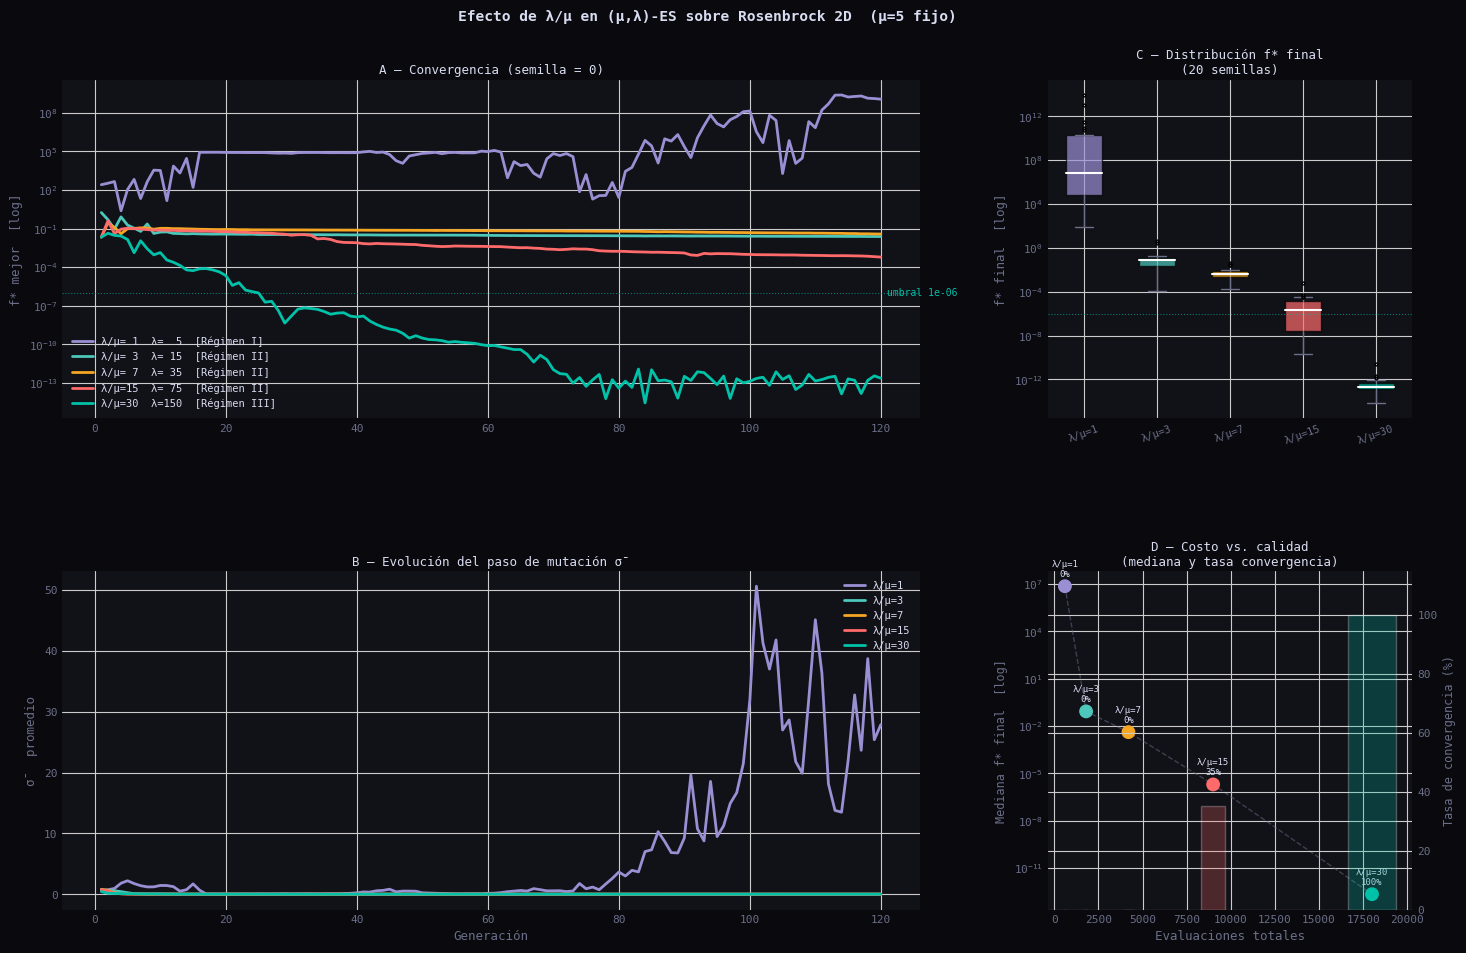


Resumen final:
 μ=5   λ/μ     λ     mediana f*    σ final    conv.   Evaluaciones
────────────────────────────────────────────────────────────────────
         1     5       7.23e+06   27.88404     0/20            600
         3    15       8.44e-02    0.00071     0/20          1,800
         7    35       4.08e-03    0.00296     0/20          4,200
        15    75       1.98e-06    0.00128     7/20          9,000
        30   150       2.20e-13    0.00000    20/20         18,000


In [13]:
# ════════════════════════════════════════════════════════════════════════
# EFECTO DEL RATIO λ/μ SOBRE CONVERGENCIA Y DIVERSIDAD
#
# Cuatro paneles:
#   A. Convergencia del fitness (seed=0)
#   B. Evolución de σ̄ (seed=0)
#   C. Distribución de f* final (20 semillas) — boxplot
#   D. Costo (evaluaciones) vs. calidad (mediana f*) + tasa de convergencia
# ════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec

MU_FIXED = 5
RATIOS   = [1, 3, 7, 15, 30]
COLORES  = ['#9B8FD4', '#4DC7BA', '#F5A623', '#FF6B6B', '#00C2A8']
REGIMEN  = ['I',       'II',      'II',      'II',      'III'     ]
N_GEN    = 120
N_SEEDS  = 20
UMBRAL   = 1e-6      # criterio de convergencia

# ── Ejecutar experimentos ─────────────────────────────────────────────
# Una corrida con seed=0 para las curvas individuales
datos_single = {}
# N_SEEDS corridas para las distribuciones
datos_multi  = {}

for ratio in RATIOS:
    lam = MU_FIXED * ratio
    f0, s0, _ = run_ee(MU_FIXED, lam, 'comma', N_GEN, seed=0)
    datos_single[ratio] = (f0, s0)
    fs = np.array([run_ee(MU_FIXED, lam, 'comma', N_GEN, seed=s)[0]
                   for s in range(N_SEEDS)])
    datos_multi[ratio] = fs

# ── Figura ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10), facecolor=CBKG)
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        left=0.07, right=0.97,
                        top=0.91, bottom=0.08,
                        wspace=0.35, hspace=0.45)

ax_f   = fig.add_subplot(gs[0, 0:2])   # A — convergencia (doble ancho)
ax_s   = fig.add_subplot(gs[1, 0:2])   # B — sigma        (doble ancho)
ax_box = fig.add_subplot(gs[0, 2])     # C — boxplot
ax_ev  = fig.add_subplot(gs[1, 2])     # D — costo vs calidad

for ax in [ax_f, ax_s, ax_box, ax_ev]:
    ax.set_facecolor(CPANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2A2A3A')
    ax.tick_params(labelsize=8, colors=C_DIM)

fig.suptitle(
    f'Efecto de λ/μ en (μ,λ)-ES sobre Rosenbrock 2D  (μ={MU_FIXED} fijo)',
    color=C_TXT, fontsize=10.5, fontweight='bold'
)

gens = np.arange(1, N_GEN + 1)

# ── Panel A: Convergencia ─────────────────────────────────────────────
for ratio, color, reg in zip(RATIOS, COLORES, REGIMEN):
    f0, _ = datos_single[ratio]
    lam   = MU_FIXED * ratio
    ax_f.semilogy(gens, np.clip(f0, 1e-15, None), color=color, lw=2,
                  label=f'λ/μ={ratio:2d}  λ={lam:3d}  [Régimen {reg}]')

ax_f.axhline(UMBRAL, color='#00C2A8', lw=0.8, ls=':', alpha=0.6)
ax_f.text(N_GEN + 1, UMBRAL, f'umbral {UMBRAL:.0e}',
          color='#00C2A8', fontsize=7, va='center')

ax_f.set_ylabel('f* mejor  [log]', fontsize=9)
ax_f.set_title('A — Convergencia (semilla = 0)', fontsize=9, color=C_TXT, pad=4)
ax_f.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
            edgecolor='#2A2A3A', loc='lower left')

# ── Panel B: Sigma ────────────────────────────────────────────────────
for ratio, color in zip(RATIOS, COLORES):
    _, s0 = datos_single[ratio]
    ax_s.plot(gens, s0, color=color, lw=2, label=f'λ/μ={ratio}')

ax_s.set_xlabel('Generación', fontsize=9)
ax_s.set_ylabel('σ̄  promedio', fontsize=9)
ax_s.set_title('B — Evolución del paso de mutación σ̄', fontsize=9, color=C_TXT, pad=4)
ax_s.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
            edgecolor='#2A2A3A', loc='upper right')

# ── Panel C: Boxplot f* final (N_SEEDS semillas) ──────────────────────
bp_data = [np.clip(datos_multi[r][:, -1], 1e-15, None) for r in RATIOS]
bp = ax_box.boxplot(
    bp_data, patch_artist=True,
    medianprops=dict(color='white', lw=1.5),
    whiskerprops=dict(color=C_DIM),
    capprops=dict(color=C_DIM),
    flierprops=dict(marker='.', color=C_DIM, ms=4)
)
for patch, color in zip(bp['boxes'], COLORES):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_box.set_yscale('log')
ax_box.set_xticks(range(1, len(RATIOS) + 1))
ax_box.set_xticklabels([f'λ/μ={r}' for r in RATIOS], fontsize=7.5, rotation=20)
ax_box.set_ylabel('f* final  [log]', fontsize=9)
ax_box.set_title(f'C — Distribución f* final\n({N_SEEDS} semillas)',
                 fontsize=9, color=C_TXT, pad=4)
ax_box.axhline(UMBRAL, color='#00C2A8', lw=0.8, ls=':', alpha=0.6)

# ── Panel D: Costo vs calidad ─────────────────────────────────────────
evals  = [N_GEN * MU_FIXED * r for r in RATIOS]
med_f  = [np.median(datos_multi[r][:, -1]) for r in RATIOS]
conv_r = [sum(datos_multi[r][:, -1] < UMBRAL) / N_SEEDS * 100 for r in RATIOS]

ax_ev2 = ax_ev.twinx()

ax_ev.scatter(evals, med_f, c=COLORES, s=80, zorder=5)
ax_ev.plot(evals, med_f, color=C_DIM, lw=1, ls='--', alpha=0.5)
ax_ev.set_yscale('log')
ax_ev.set_ylabel('Mediana f* final  [log]', fontsize=8.5)

ax_ev2.bar(evals, conv_r, width=[e * 0.15 for e in evals],
           color=COLORES, alpha=0.25)
ax_ev2.set_ylabel('Tasa de convergencia (%)', fontsize=8.5, color=C_DIM)
ax_ev2.tick_params(colors=C_DIM, labelsize=8)
ax_ev2.set_ylim(0, 115)

for e, r, m, c in zip(evals, RATIOS, med_f, conv_r):
    ax_ev.text(e, m * 4, f'λ/μ={r}\n{c:.0f}%',
               fontsize=6.5, ha='center', color=C_TXT)

ax_ev.set_xlabel('Evaluaciones totales', fontsize=9)
ax_ev.set_title('D — Costo vs. calidad\n(mediana y tasa convergencia)',
                fontsize=9, color=C_TXT, pad=4)

plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────
print('\nResumen final:')
print(f'{"μ=5   λ/μ":>10} {"λ":>5} {"mediana f*":>14} '
      f'{"σ final":>10} {"conv.":>8} {"Evaluaciones":>14}')
print('─' * 68)
for ratio, color in zip(RATIOS, COLORES):
    lam    = MU_FIXED * ratio
    _, s0  = datos_single[ratio]
    fs     = datos_multi[ratio][:, -1]
    conv   = sum(fs < UMBRAL)
    evals  = N_GEN * lam
    print(f'{ratio:>10} {lam:>5} {np.median(fs):>14.2e} '
          f'{s0[-1]:>10.5f} {conv:>5}/{N_SEEDS} {evals:>14,}')



#### Análisis de resultados

La **gráfica A** muestra la evolución del mejor valor de la función objetivo f\* a lo largo de las generaciones para distintas configuraciones de ${\lambda}/{\mu}$, para una corrida individual (semilla=0). El resultado es bastante singular, mostrando que los diferentes valores utilizados no producen variaciones
graduales sino tres regímenes cualitativamente distintos:
 
- **Régimen I — $\lambda/\mu = 1$**. La condición mínima de $(\mu, \lambda)$-ES es $\lambda>\mu$; con $\lambda=\mu$ la selección no ejerce ninguna presión. El paso de mutación $\sigma$ no recibe señal de retroalimentación útil y puede crecer sin control, lo que puede apreciarse en la **gráfica B**. 
 
- **Régimen II — $\lambda/\mu \in [3,7,15]$**. La selección ejerce presión, pero insuficiente para garantizar convergencia robusta. El sistema mejora consistentemente durante las primeras generaciones y luego se estanca en un mínimo local o en la cresta del paisaje. $\sigma$ converge a valores pequeños, lo que confirma que la autoadaptación detecta la zona del óptimo — pero la presión selectiva no es suficiente
para refinar la solución.
 
- **Régimen III — $\lambda/\mu = 30$**. La convergencia al óptimo global es robusta. Con este valor, el 100% de las corridas converge. El valor alto de $\lambda$ compensa la ausencia de elitismo: en cada generación hay suficientes hijos como para que, por probabilidad,
alguno explore la vecindad exacta del óptimo.

La **gráfica C** es particularmente interesante: aquí se muestran diagramas de caja (*boxplots*) del valor final de la función objetivo f\* después de las 20 corridas independientes del algoritmo para distintos valores de $\lambda/\mu$.

- **$\lambda/\mu=1$**: El algoritmo muestra resultados extremadamente variables y generalmente muy malos. La mediana del error es varios órdenes de magnitud mayor que en los demás casos y la dispersión es enorme. Esto confirma que cuando todos los descendientes sobreviven, el algoritmo se comporta esencialmente como una búsqueda aleatoria sin presión selectiva.
  
- **$\lambda/\mu=3$**: Presión selectiva baja. Se observa una mejora importante respecto al caso anterior. El algoritmo converge de forma más consistente, aunque el error final sigue siendo relativamente alto y existe cierta variabilidad entre corridas. Esto refleja que la exploración es limitada y el algoritmo puede quedar atrapado en regiones subóptimas.

- **$\lambda/\mu=7$**: Presión selectiva moderada. La distribución del error final mejora notablemente y la variabilidad disminuye. Alrededor de este valor suele obtenerse un buen equilibrio entre exploración y explotación.

- **$\lambda/\mu=15$**: Presión selectiva alta. La mediana del error cae por debajo del umbral de convergencia en varias corridas. Esto indica que el algoritmo logra explorar más eficientemente el espacio de búsqueda gracias al mayor número de descendientes evaluados. Se observa una mayor dispersión como consecuencia de esa exploración más extensa.

- **$\lambda/\mu=30$**: Este caso presenta los mejores resultados globales: la mediana del error es extremadamente baja y la dispersión entre corridas es mínima. El algoritmo encuentra consistentemente soluciones cercanas al óptimo, lo que sugiere que una población grande de descendientes aumenta significativamente la probabilidad de generar mutaciones altamente favorables.

La **gráfica D** muestra la relación entre costo computacional y calidad de la solución para las distintas configuraciones de $\lambda/\mu$. El eje horizontal representa el número total de evaluaciones de la función objetivo, que es la principal medida de costo. El eje vertical izquierdo muestra la mediana del error final f\* (en escala logarítmica), calculada sobre las 20 corridas independientes.
El eje vertical derecho muestra la tasa de convergencia, es decir, el porcentaje de corridas que alcanzan el umbral de error definido ($10^{-6}$). Cada punto representa una configuración distinta de $\lambda/\mu$, mientras que las barras verticales indican la tasa de convergencia correspondiente.

- **$\lambda/\mu=1$**: El costo computacional es mínimo, pero el algoritmo no logra converger en ninguna corrida. La mediana del error final es extremadamente alta, lo que confirma que sin presión selectiva el algoritmo se comporta como una búsqueda aleatoria.
  
- **$\lambda/\mu=3$**: El costo aumenta ligeramente y la calidad de las soluciones mejora significativamente respecto al caso anterior.
Sin embargo, la mediana del error sigue siendo relativamente alta y ninguna corrida alcanza el umbral de convergencia.

- **$\lambda/\mu=7$**: Se observa una mejora adicional en la calidad de las soluciones. Sin embargo, y a pesar de ser el valor clásico ninguna corrida alcanza el umbral de convergencia.

- **$\lambda/\mu=15$**: El algoritmo alcanza un nivel de error mucho menor y algunas corridas logran converger al umbral definido.
Esto indica que aumentar el número de descendientes mejora la probabilidad de generar mutaciones altamente favorables.

- **$\lambda/\mu=30$**: Este caso produce las mejores soluciones y alcanza una tasa de convergencia del 100%.
La mediana del error es varios órdenes de magnitud menor que en los demás casos. Sin embargo, esto ocurre al mayor costo computacional, ya que el número de evaluaciones es considerablemente mayor.


El costo también podemos apreciarlo en la tabla **Resumen final**. La conclusión de este ejercicio es que, para Rosenbrock, la relación $\lambda/\mu=7$ no es suficientemente buena, pero tasas mayores implican un costo computacional mayor que, para evaluaciones más complejas se puede volver prohibitivo

---

### El límite de la adaptación escalar: hacia una matriz de covarianza

La autoadaptación lognormal —tanto en su versión isótropa como anisótropa— opera
sobre una suposición implícita: que las dimensiones del espacio de búsqueda son
**independientes entre sí**. En la versión isótropa, un único $\sigma$ escala la
mutación por igual en todas las direcciones. En la versión anisótropa, cada
dimensión tiene su propio $\sigma_i$, lo que permite pasos de distinto tamaño
según el eje coordenado:

$$
\mathbf{x}' = \mathbf{x} + \boldsymbol{\sigma} \odot \mathcal{N}(\mathbf{0}, \mathbf{I}), 
\qquad \boldsymbol{\sigma} = (\sigma_1, \sigma_2, \ldots, \sigma_n)
$$

<p align="center">
  <img src="images/CMA-sigma.png" width="800">
</p>

La distribución de mutación resultante es siempre un **elipsoide alineado con
los ejes coordenados**. Esto es adecuado cuando la función objetivo también está
alineada con esos ejes. Pero en la práctica, muchas funciones presentan
**correlaciones entre variables**: el valle de menor resistencia no sigue ningún
eje en particular, sino una dirección oblicua en el espacio.

Cuando ocurre eso, ningún ajuste de $\sigma_i$ —por más fino que sea— puede orientar
la elipsoide de mutación en la dirección correcta. El algoritmo queda condenado
a explorar con una forma de mutación desalineada respecto a la geometría real
del problema.

La diferencia entre ambas aproximaciones puede expicarse geométricamente de la sigueinte manera:

| Representación | Parámetros adaptados | Forma de la nube de mutación | Limitación |
|:---|:---:|:---:|:---|
| Isótropa | $\sigma \in \mathbb{R}$ | Esfera | Tamaño, no forma |
| Anisótropa | $\boldsymbol{\sigma} \in \mathbb{R}^n$ | Elipsoide alineado con ejes | Tamaño por eje, forma por eje,  orientación discreta |

#### Experimento

A continuación evaluamos ambas representaciones sobre una versión **rotada**
de la función elíptica.

La *función elíptica rotada* es una forma cuadrática cuya geometría (un elipsoide) ha sido girada para que sus ejes principales no coincidan con los ejes coordenados. 

Su estructura general para un mínimo en el origen se define como:

$$f(\mathbf{x}) = \mathbf{x}^T \mathbf{H} \mathbf{x} = \mathbf{x}^T (\mathbf{R}^T \mathbf{D} \mathbf{R}) \mathbf{x}$$

Donde los componentes definen la geometría del valle:

1.  **Matriz de Escala ($\mathbf{D}$):** Es una matriz diagonal $\text{diag}(\alpha_1, \alpha_2, \dots, \alpha_n)$ que define la sensibilidad (curvatura) de cada eje. Por ejemplo, si $\alpha_1=1$ y $\alpha_2=100$, el segundo eje es 100 veces más "empinado" que el primero, creando un valle estrecho.
2.  **Matriz de Rotación ($\mathbf{R}$):** Determina la orientación del valle en el espacio. En 2D, para un ángulo $\theta$, se define como:
    $$\mathbf{R} = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix}$$
3.  **Matriz Hessiana ($\mathbf{H} = \mathbf{R}^T \mathbf{D} \mathbf{R}$):** Al combinar la rotación con la escala, las variables $x_i$ dejan de ser independientes. La función expandida contiene términos cruzados (como $x_1x_2$), lo que genera la **correlación** que obliga a CMA-ES a adaptar su propia matriz de covarianza para alinearse con el valle.

<p align="center">
  <img src="images/funciones_elípticas.png" width="800">
</p>

Al rotar el eje de mayor curvatura un ángulo de $45°$ respecto a los ejes coordenados se consigue que la correlación entre variables sea máxima y expone directamente el costo de asumir independencia.


- Fijamos $\mu = 10$, $\lambda = 70$, $n_{\text{gen}} = 300$
- Comparamos:
  - $(\mu,\lambda)$-ES isótropa
  - $(\mu,\lambda)$-ES anisótropa

- Visualizamos:
  - **Convergencia del fitness** en las tres variantes
  - **Geometría de la nube de mutación** en generaciones seleccionadas
  - **Orientación aprendida** de la elipsoide de CMA-ES vs. ejes reales de la función

In [14]:
# ════════════════════════════════════════════════════════════════════════
# LÍMITE DE LA ADAPTACIÓN ESCALAR: FUNCIÓN ELÍPTICA ROTADA 2D
#
# Comparamos dos representaciones de la distribución de mutación:
#   1. Isótropa      — σ escalar
#   2. Anisótropa    — σ por dimensión
#
# Función: elíptica rotada 45° — correlación máxima entre variables
# ════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse

# ── Función objetivo: elíptica rotada ────────────────────────────────
ANGULO_ROT = np.pi / 4          # 45°
CONDICION  = 100.0              # ratio de curvaturas

def rot_matrix(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [ np.sin(theta),  np.cos(theta)]])

R  = rot_matrix(ANGULO_ROT)
RT = R.T
D  = np.diag([1.0, CONDICION])

def eliptica_rotada(xy):
    """f(x) = xᵀ Rᵀ D R x — mínimo en origen, ejes a 45°."""
    v = np.asarray(xy)
    return float(v @ RT @ D @ R @ v)


# ── ES isótropa ───────────────────────────────────────────────────────
def es_isotropa(mu, lam, n_gen, sigma0=1.0, seed=0):
    rng = np.random.default_rng(seed)
    n   = 2
    tau = 1 / np.sqrt(n)
    pop_x = rng.uniform(-3, 3, (mu, n))
    pop_s = np.full(mu, sigma0)
    hist_f, hist_s = [], []

    for _ in range(n_gen):
        hx = np.zeros((lam, n));  hs = np.zeros(lam)
        for k in range(lam):
            i = rng.integers(0, mu)
            s = max(pop_s[i] * np.exp(tau * rng.standard_normal()), 1e-9)
            hx[k] = pop_x[i] + s * rng.standard_normal(n)
            hs[k] = s
        fit = np.array([eliptica_rotada(h) for h in hx])
        sel = np.argsort(fit)[:mu]
        pop_x, pop_s = hx[sel], hs[sel]
        hist_f.append(fit[sel[0]])
        hist_s.append(pop_s.mean())

    return np.array(hist_f), np.array(hist_s), pop_x


# ── ES anisótropa ─────────────────────────────────────────────────────
def es_anisotropa(mu, lam, n_gen, sigma0=1.0, seed=0):
    rng   = np.random.default_rng(seed)
    n     = 2
    tau_g = 1 / np.sqrt(2 * n)
    tau_l = 1 / np.sqrt(2 * np.sqrt(n))
    pop_x = rng.uniform(-3, 3, (mu, n))
    pop_s = np.full((mu, n), sigma0)
    hist_f, hist_s1, hist_s2 = [], [], []

    for _ in range(n_gen):
        hx = np.zeros((lam, n));  hs = np.zeros((lam, n))
        for k in range(lam):
            i  = rng.integers(0, mu)
            sg = rng.standard_normal()
            sl = rng.standard_normal(n)
            s  = np.maximum(pop_s[i] * np.exp(tau_g * sg + tau_l * sl), 1e-9)
            hx[k] = pop_x[i] + s * rng.standard_normal(n)
            hs[k] = s
        fit = np.array([eliptica_rotada(h) for h in hx])
        sel = np.argsort(fit)[:mu]
        pop_x, pop_s = hx[sel], hs[sel]
        hist_f.append(fit[sel[0]])
        hist_s1.append(pop_s[:, 0].mean())
        hist_s2.append(pop_s[:, 1].mean())

    return np.array(hist_f), np.array(hist_s1), np.array(hist_s2), pop_x


# ── Ejecutar ──────────────────────────────────────────────────────────
MU, LAM, N_GEN = 10, 70, 300

f_iso,   s_iso,  pop_iso   = es_isotropa  (MU, LAM, N_GEN)
f_aniso, s1, s2, pop_aniso = es_anisotropa(MU, LAM, N_GEN)

print(f'Isótropa  : f* = {f_iso[-1]:.6e}')
print(f'Anisótropa: f* = {f_aniso[-1]:.6e}')
print(f'Óptimo    : f* = 0.000000e+00  en [0, 0]')

Isótropa  : f* = 9.156453e-20
Anisótropa: f* = 1.830398e-19
Óptimo    : f* = 0.000000e+00  en [0, 0]


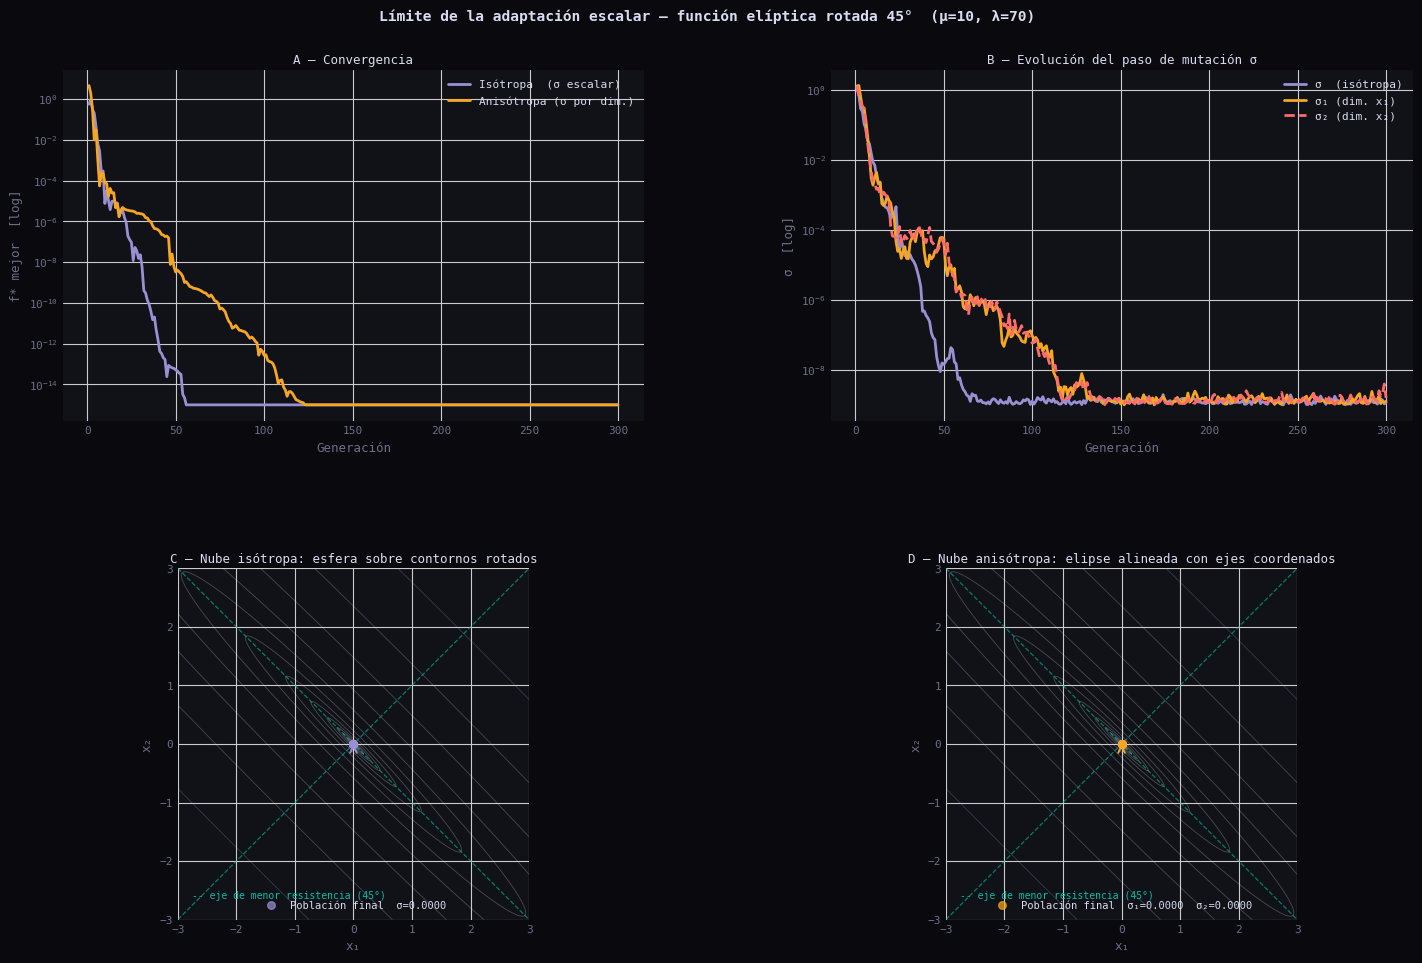


Resumen:
Algoritmo                f* final       σ final
────────────────────────────────────────────────
Isótropa                 9.16e-20  σ=0.00000
Anisótropa               1.83e-19  σ₁=0.00000  σ₂=0.00000


In [15]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA: límite de σ escalar sobre función elíptica rotada 45°
#
# Cuatro paneles:
#   A. Convergencia comparada
#   B. Evolución de σ — isótropa (escalar) vs. anisótropa (por dimensión)
#   C. Geometría de mutación — isótropa: nube circular sobre contornos
#   D. Geometría de mutación — anisótropa: nube alineada con ejes
# ════════════════════════════════════════════════════════════════════════

C_ISO   = '#9B8FD4'   # lavanda  — isótropa
C_ANISO = '#F5A623'   # ámbar    — anisótropa
C_OPT   = '#00C2A8'   # cian     — eje real / referencia

def dibujar_elipse(ax, centro, cov, color, alpha=0.30, lw=1.5,
                   n_std=2.0, label=None):
    """Elipse de confianza a n_std desviaciones de N(0, cov)."""
    vals, vecs = np.linalg.eigh(cov)
    orden = vals.argsort()[::-1]
    vals, vecs = vals[orden], vecs[:, orden]
    angulo = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w = 2 * n_std * np.sqrt(max(vals[0], 0))
    h = 2 * n_std * np.sqrt(max(vals[1], 0))
    ell = Ellipse(xy=centro, width=w, height=h, angle=angulo,
                  edgecolor=color, facecolor=color,
                  alpha=alpha, linewidth=lw, label=label)
    ax.add_patch(ell)
    # eje principal
    v0 = vecs[:, 0] * n_std * np.sqrt(vals[0])
    ax.annotate('', xy=centro + v0, xytext=centro,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4))


# ── Contornos ─────────────────────────────────────────────────────────
lim = 3.0
xx, yy = np.meshgrid(np.linspace(-lim, lim, 400),
                     np.linspace(-lim, lim, 400))
pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
zz  = np.array([eliptica_rotada(p) for p in pts]).reshape(xx.shape)
levels_log = np.logspace(-2, np.log10(zz.max()), 14)

# ── Figura ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10), facecolor=CBKG)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        left=0.07, right=0.97,
                        top=0.92, bottom=0.07,
                        wspace=0.32, hspace=0.42)

ax_conv = fig.add_subplot(gs[0, 0])
ax_sig  = fig.add_subplot(gs[0, 1])
ax_giso = fig.add_subplot(gs[1, 0])
ax_gani = fig.add_subplot(gs[1, 1])

for ax in [ax_conv, ax_sig, ax_giso, ax_gani]:
    ax.set_facecolor(CPANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2A2A3A')
    ax.tick_params(labelsize=8, colors=C_DIM)

fig.suptitle(
    'Límite de la adaptación escalar — función elíptica rotada 45°  '
    f'(μ={MU}, λ={LAM})',
    color=C_TXT, fontsize=10.5, fontweight='bold'
)

gens = np.arange(1, N_GEN + 1)

# ── Panel A: Convergencia ─────────────────────────────────────────────
ax_conv.semilogy(gens, np.clip(f_iso,   1e-15, None),
                 color=C_ISO,   lw=2, label='Isótropa  (σ escalar)')
ax_conv.semilogy(gens, np.clip(f_aniso, 1e-15, None),
                 color=C_ANISO, lw=2, label='Anisótropa (σ por dim.)')
ax_conv.set_xlabel('Generación', fontsize=9, color=C_DIM)
ax_conv.set_ylabel('f* mejor  [log]', fontsize=9, color=C_DIM)
ax_conv.set_title('A — Convergencia', fontsize=9, color=C_TXT, pad=4)
ax_conv.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A')

# ── Panel B: Evolución de σ ───────────────────────────────────────────
ax_sig.plot(gens, s_iso, color=C_ISO,   lw=2, label='σ  (isótropa)')
ax_sig.plot(gens, s1,    color=C_ANISO, lw=2, label='σ₁ (dim. x₁)')
ax_sig.plot(gens, s2,    color='#FF6B6B', lw=2, ls='--',
            label='σ₂ (dim. x₂)')
ax_sig.set_yscale('log')
ax_sig.set_xlabel('Generación', fontsize=9, color=C_DIM)
ax_sig.set_ylabel('σ  [log]', fontsize=9, color=C_DIM)
ax_sig.set_title('B — Evolución del paso de mutación σ',
                  fontsize=9, color=C_TXT, pad=4)
ax_sig.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT,
              edgecolor='#2A2A3A')

# ── Nubes de puntos finales (población de μ individuos) ───────────────
def nube_mutacion(pop, sigma_esc, ax, color, label):
    """Scatter de la población + elipse isótropa centrada en la media."""
    centro = pop.mean(axis=0)
    ax.scatter(pop[:, 0], pop[:, 1], color=color, s=30,
               alpha=0.7, zorder=4, label=label)
    cov = np.eye(2) * sigma_esc**2
    dibujar_elipse(ax, centro, cov, color, alpha=0.20, lw=1.8, n_std=2)

def nube_anisotropa(pop, s1f, s2f, ax, color, label):
    """Scatter + elipse anisótropa alineada con ejes."""
    centro = pop.mean(axis=0)
    ax.scatter(pop[:, 0], pop[:, 1], color=color, s=30,
               alpha=0.7, zorder=4, label=label)
    cov = np.diag([s1f**2, s2f**2])
    dibujar_elipse(ax, centro, cov, color, alpha=0.20, lw=1.8, n_std=2)

# ── Panel C: Isótropa ─────────────────────────────────────────────────
ax_giso.contour(xx, yy, zz, levels=levels_log, cmap='Blues',
                alpha=0.25, linewidths=0.6)
for sign in [-1, 1]:
    ax_giso.axline((0, 0), slope=sign * np.tan(ANGULO_ROT),
                   color=C_OPT, lw=0.9, ls='--', alpha=0.6)

nube_mutacion(pop_iso, float(s_iso[-1]), ax_giso, C_ISO,
              label=f'Población final  σ={s_iso[-1]:.4f}')

ax_giso.set_xlim(-lim, lim);  ax_giso.set_ylim(-lim, lim)
ax_giso.set_aspect('equal')
ax_giso.set_xlabel('x₁', fontsize=9, color=C_DIM)
ax_giso.set_ylabel('x₂', fontsize=9, color=C_DIM)
ax_giso.set_title('C — Nube isótropa: esfera sobre contornos rotados',
                   fontsize=9, color=C_TXT, pad=4)
ax_giso.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A')
ax_giso.text(0.04, 0.06, '-- eje de menor resistencia (45°)',
             transform=ax_giso.transAxes, fontsize=7, color=C_OPT)

# ── Panel D: Anisótropa ───────────────────────────────────────────────
ax_gani.contour(xx, yy, zz, levels=levels_log, cmap='Blues',
                alpha=0.25, linewidths=0.6)
for sign in [-1, 1]:
    ax_gani.axline((0, 0), slope=sign * np.tan(ANGULO_ROT),
                   color=C_OPT, lw=0.9, ls='--', alpha=0.6)

nube_anisotropa(pop_aniso, float(s1[-1]), float(s2[-1]),
                ax_gani, C_ANISO,
                label=f'Población final  σ₁={s1[-1]:.4f}  σ₂={s2[-1]:.4f}')

ax_gani.set_xlim(-lim, lim);  ax_gani.set_ylim(-lim, lim)
ax_gani.set_aspect('equal')
ax_gani.set_xlabel('x₁', fontsize=9, color=C_DIM)
ax_gani.set_ylabel('x₂', fontsize=9, color=C_DIM)
ax_gani.set_title('D — Nube anisótropa: elipse alineada con ejes coordenados',
                   fontsize=9, color=C_TXT, pad=4)
ax_gani.legend(fontsize=7.5, facecolor='#0D0D15', labelcolor=C_TXT,
               edgecolor='#2A2A3A')
ax_gani.text(0.04, 0.06, '-- eje de menor resistencia (45°)',
             transform=ax_gani.transAxes, fontsize=7, color=C_OPT)

plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────
print('\nResumen:')
print(f'{"Algoritmo":<18} {"f* final":>14}  {"σ final":>12}')
print('─' * 48)
print(f'{"Isótropa":<18} {f_iso[-1]:>14.2e}  '
      f'σ={s_iso[-1]:.5f}')
print(f'{"Anisótropa":<18} {f_aniso[-1]:>14.2e}  '
      f'σ₁={s1[-1]:.5f}  σ₂={s2[-1]:.5f}')

#### Análisis de resultados

La **gráfica A** muestra la evolución del mejor valor de la función objetivo $f^*$ a lo largo
de las generaciones para las dos variantes de autoadaptación sobre la función elíptica rotada
45°. El contraste es inmediato: ambos algoritmos mejoran durante las primeras generaciones,
pero la anisótropa se estanca antes y en un valor considerablemente peor.

La razón no está en los hiperparámetros ni en la presión selectiva — ambas variantes usan
$\mu=10$, $\lambda=70$ — sino en la **representación de la distribución de mutación**.

La **gráfica B** revela la dinámica interna de esa diferencia:

- La variante **isótropa** adapta un único $\sigma$ global. Ante una función con curvatura
  muy distinta según la dirección, el algoritmo no puede satisfacer ambas exigencias
  simultáneamente: un $\sigma$ grande explora en la dirección suave pero genera demasiado
  ruido en la dirección empinada, y viceversa. El resultado es un compromiso subóptimo que
  se refleja en la curva de convergencia prematuramente plana.

- La variante **anisótropa** adapta $\sigma_1$ y $\sigma_2$ de forma independiente. Esto
  permite ajustar el paso de mutación por eje coordenado, lo que en principio debería
  resolver el problema de curvatura diferencial. Sin embargo, la gráfica B muestra que
  $\sigma_1$ y $\sigma_2$ convergen a valores distintos pero **ambos pequeños**, señal de
  que el algoritmo detecta que los pasos grandes son perjudiciales en *todas* las
  direcciones coordenadas. El problema es que ninguna dirección coordenada coincide con
  el eje de menor resistencia de la función.

Los **paneles C y D** hacen visible la causa estructural. En el panel C, la nube de mutación
isótropa es una esfera: el mismo radio en todas las direcciones, independientemente de cómo
estén orientados los contornos de la función. En el panel D, la nube anisótropa es una
elipse, pero **alineada con los ejes coordenados** $x_1$ y $x_2$. Los contornos de la
función, en cambio, tienen sus ejes a 45°. La elipse de mutación y la geometría del problema
apuntan en direcciones distintas.

Esto expone el límite fundamental de ambas representaciones: ni $\sigma$ ni
$(\sigma_1, \sigma_2)$ tienen suficientes grados de libertad para orientar la distribución
de mutación en una dirección arbitraria. Formalmente, la distribución de mutación en ambos
casos es

$$
\mathbf{x}' = \mathbf{x} + \boldsymbol{\sigma} \odot \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

lo que equivale a muestrear de una gaussiana cuya matriz de covarianza es siempre
**diagonal**. Una matriz diagonal no puede representar correlaciones entre dimensiones
y, por tanto, no puede orientarse hacia el eje de menor resistencia cuando ese eje
es oblicuo.

| Representación | Parámetros adaptados | Forma de la nube | Puede rotar? |
|:---|:---:|:---:|:---:|
| Isótropa | $\sigma \in \mathbb{R}$ | Esfera | ✗ |
| Anisótropa | $\boldsymbol{\sigma} \in \mathbb{R}^n$ | Elipsoide alineado con ejes | ✗ |
| **?** | $\mathbf{C} \in \mathbb{R}^{n \times n}$ | Elipsoide arbitrariamente orientado | **✓** |

La pregunta que queda abierta es: ¿cómo aprender esa orientación directamente de la
historia de mutaciones exitosas, sin que el costo de mantener y actualizar una matriz
$n \times n$ haga inviable el algoritmo? Esa es exactamente la pregunta que responde
**CMA-ES** (*Covariance Matrix Adaptation Evolution Strategy*).

---

Los seis paneles ilustran los mecanismos de la autoadaptación desde distintos ángulos.

**Panel (0,0) — Convergencia isótropa vs. anisótropa:** Ambas variantes convergen, pero la anisótropa logra valores finales más bajos sobre Rosenbrock. La razón es que Rosenbrock tiene un valle estrecho y curvo: las dimensiones $x_1$ y $x_2$ requieren intensidades de exploración muy distintas, y la versión anisótropa puede aprender esa diferencia.

**Panel (0,1) — σ isótropo:** El σ medio decrece de forma autónoma durante la búsqueda, pasando de ~1.0 a valores muy pequeños al converger. La banda de variación muestra que la población mantiene diversidad en σ durante la exploración y la concentra al afinarse. Este comportamiento no fue programado: emerge de la presión selectiva.

**Panel (0,2) — σ₁ y σ₂ anisótropos:** La divergencia entre σ₁ y σ₂ es la señal más reveladora de la sección. El algoritmo aprende que las dos dimensiones de Rosenbrock tienen geometrías distintas y asigna intensidades de mutación diferentes a cada una. Este es el comportamiento que la Regla de 1/5 no puede capturar — al ser un σ escalar, no puede diferenciar entre dimensiones.

**Panel (1,0) — Efecto del orden de mutación:** El impacto de mutar σ antes o después de x es inmediato y radical en escala logarítmica. Con el orden incorrecto el algoritmo sigue mejorando, pero σ no recibe la presión selectiva correcta y la convergencia se detiene antes.

**Panel (1,1) — Distribución de σ en la población:** Los snapshots muestran cómo la nube de valores de σ en los μ mejores individuos migra hacia valores menores y más concentrados a medida que el algoritmo converge. En las primeras generaciones hay alta variabilidad; en las finales, todos los padres supervivientes llevan valores de σ similares y pequeños.

**Panel (1,2) — Efecto de τ:** El parámetro de aprendizaje τ controla la velocidad de adaptación de σ. Un τ demasiado pequeño hace que σ cambie muy lentamente — el algoritmo tarda en encontrar la escala de mutación adecuada. Un τ demasiado grande hace que σ fluctúe demasiado, desestabilizando la convergencia. El valor teórico τ = 1/√n logra el mejor balance.

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Metaoptimización implícita:</strong> Lo que hemos visto en esta sección es que la EE optimiza simultáneamente dos cosas: la calidad de la solución (a través de x) y la estrategia de búsqueda (a través de σ). No hay ningún optimizador externo que ajuste σ; es el mismo proceso evolutivo operando en dos capas. Esta propiedad — que el algoritmo se autoregule sin supervisión — es lo que distingue a las EE de los algoritmos evolutivos de primera generación.
</div>

## 7. CMA-ES: la variante moderna

La autoadaptación lognormal de la sección anterior aprende $\sigma_i$ independientes por
dimensión: puede ajustar la intensidad de exploración en cada eje coordenado, pero no puede
capturar correlaciones entre dimensiones. Si el valle óptimo está rotado respecto a los ejes
coordenados, ambas variantes —isótropa y anisótropa— siguen siendo ineficientes, porque su
distribución de mutación no tiene los grados de libertad necesarios para orientarse en una
dirección arbitraria. Consideremos, por ejemplo, este caso:

<p align="center">
  <img src="images/CMA-sigma-1.png" width="300">
</p>

En esta imagen, la distribución de mutación es una **elipsoide alineada con los ejes**. Cada dimensión se escala de forma independiente mediante $\sigma_i$, de manera que no existe ninguna forma de introducir correlación entre las variables. El algoritmo avanza en forma de **zig-zag**: Los pasos no siguen la dirección del valle, sino combinaciones de movimientos horizontales y verticales. Muchos pasos son parcialmente “desperdiciados”, ya que salen del valle y deben ser corregidos. El modelo de mutación no logra alinearse con la geometría real del problema.



**CMA-ES** (*Covariance Matrix Adaptation Evolution Strategy*) corrige esta limitante: en lugar
de aprender un vector de $\sigma$ (que correspondería a la diagonal de la matriz de covarianza), aprende una **matriz de covarianza completa**. 

<p align="center">
  <img src="images/CMA-sigma-2.png" width="300">
</p>

Esta forma de modular la mutación, le permite a CMA-ES definir simultáneamente:
- **Orientación**: El elipsoide ya no está anclado a los ejes y ahora puede rotar para alinearse con la dirección del valle (la correlación entre variables).
- **Forma** y **Tamaño**: La distribución se "estira" en las direcciones de mayor mejora y se "contrae" donde el terreno es más empinado, optimizando cada paso de búsqueda.
  
Gracias a esta capacidad de aprendizaje de la curvatura local, CMA-ES evita el ineficiente avance en zig-zag, convirtiéndose en el referente estándar para optimización de caja negra en espacios continuos y el punto de comparación habitual para los métodos modernos sin gradiente. 


### La idea central

CMA-ES genera hijos muestreando con una gaussiana multivariada cuya forma se adapta
generación a generación:

$$
\mathbf{x}^{(k)} = \mathbf{m} + \sigma \cdot \mathbf{z}^{(k)},
\qquad \mathbf{z}^{(k)} \sim \mathcal{N}(\mathbf{0},\, \mathbf{C})
$$

donde:

- $\mathbf{m} \in \mathbb{R}^n$ — media de la distribución (centro de la búsqueda)
- $\sigma > 0$ — tamaño global del paso (*step size*)
- $\mathbf{C} \in \mathbb{R}^{n \times n}$ — matriz de covarianza que codifica la forma y orientación del elipsoide

En la práctica, el muestreo se implementa mediante la descomposición eigenvalor
$\mathbf{C} = \mathbf{B}\mathbf{D}^2\mathbf{B}^\top$, donde $\mathbf{B}$ es la matriz de
vectores propios (orientación) y $\mathbf{D}$ es diagonal (escalas por eje). Esto permite
muestrear eficientemente como:

$$
\mathbf{z}^{(k)} = \mathbf{B}\mathbf{D}\,\mathcal{N}(\mathbf{0}, \mathbf{I})
$$

Esta descomposición aparecerá explícitamente en el código de la siguiente sección.

En cada generación, CMA-ES actualiza los tres parámetros: $\mathbf{m}$ se desplaza hacia los
mejores hijos mediante recombinación ponderada; $\mathbf{C}$ aprende qué direcciones del
espacio producen mejoras consistentes; y $\sigma$ se regula mediante un mecanismo propio
llamado **adaptación acumulativa del tamaño de paso** (CSA, por sus siglas en inglés, *Cumulative Step-size Adaptation*), que monitorea la longitud acumulada del camino evolutivo y ajusta el paso global para mantener un progreso sostenido.

La actualización de $\mathbf{C}$ combina dos mecanismos complementarios:

| Mecanismo | Qué aprende | Horizonte temporal |
|:---|:---|:---:|
| **Rank-$\mu$ update** | Direcciones exitosas en la generación actual ($\mu$ mejores hijos) | Corto plazo |
| **Rank-1 update** (*evolution path*) | Acumulación de pasos exitosos a lo largo del tiempo | Largo plazo |

La combinación de ambos permite que CMA-ES aprenda tanto la geometría local del paisaje
como las correlaciones que persisten a lo largo de generaciones, sin necesidad de calcular
ni estimar gradientes.

### Parámetros por defecto

Una de las virtudes prácticas de CMA-ES es que sus parámetros se estiman en base a la dimensión $n$ del problema:

$$
\lambda = 4 + \lfloor 3 \ln n \rfloor \qquad \text{(tamaño de población)}
\qquad\qquad
\mu = \left\lfloor \lambda / 2 \right\rfloor \qquad \text{(número de padres)}
$$

Aunque estas estimaciones siguen siendo heurísticas, tienen una base más sólida que las reglas de 1/5 o 
$\lambda/\mu \approx 7$. A diferencia de aquellas, estas no son constantes genéricas, sino que escalan con la dimensionalidad del problema y fueron diseñadas para resolver un subproblema técnico crítico: garantizar la estabilidad de la matriz de covarianza y la invarianza del algoritmo ante rotaciones o cambios de escala en el espacio de búsqueda.

Los pesos de recombinación favorecen exponencialmente a los mejores individuos, y las tasas
de aprendizaje para $\mathbf{C}$ y $\sigma$ también se derivan de $n$. En la práctica,
CMA-ES funciona razonablemente bien con estos valores por defecto en una amplia variedad de
problemas, lo que reduce el ajuste manual respecto al AGS o a la EE estándar con
autoadaptación lognormal.

### Experimento sobre la función Cigar

Para analizar como funciona la EE CMA, utilizaremos la función Cigar. 

La función *Bent Cigar* es un problema de prueba unimodal utilizado para evaluar algoritmos de optimización. Se caracteriza por un *mal condicionamiento* extremo, ya que es muy sensible a cambios en la primera dimensión y muy plana en las demás.

<p align="center">
  <img src="images/Cigar.png" width="500">
</p>

Para un vector $x$ de $n$ dimensiones, la función Cigar se define como:

$$f(\mathbf{x}) = x_1^2 + 10^6 \sum_{i=2}^{d} x_i^2$$

**Propiedades**
*   **Mínimo Global:** $f(\mathbf{x}^*) = 0$ en $\mathbf{x}^* = (0, \dots, 0)$.
*   **Rango de búsqueda sugerido:** $[-100, 100]^d$.
*   **Dificultad:** Su forma de "cigarro" (un valle largo y estrecho) pone a prueba la capacidad del algoritmo para converger cuando las escalas de las dimensiones son radicalmente distintas.



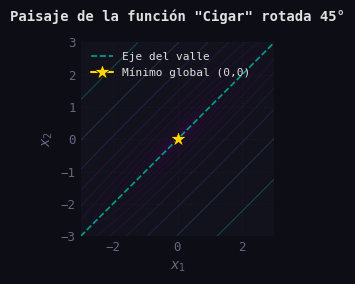

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ── Configuración Estética ────────────────────────────────────────────
CBKG   = '#0D0D15'  
CPANEL = '#12121D'  
C_DIM  = '#666680'  
C_TXT  = '#E0E0E0'  
C_OPT  = '#00C2A8'  

def cigar_rotada(x, angle=45):
    """Función Cigar: eje sensible rotado."""
    rad = np.radians(angle)
    c, s = np.cos(rad), np.sin(rad)
    R = np.array([[c, -s], [s, c]])
    y = R.T @ x
    # Sensibilidad 100x en el eje perpendicular a la rotación
    return y[0]**2 + 100 * y[1]**2

# ── Preparación de la Figura ──────────────────────────────────────────
lim = 3.0
xx, yy = np.meshgrid(np.linspace(-lim, lim, 400),
                     np.linspace(-lim, lim, 400))
pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
zz  = np.array([cigar_rotada(p) for p in pts]).reshape(xx.shape)
levels_log = np.logspace(-1, np.log10(zz.max()), 15)

fig, ax = plt.subplots(figsize=(3, 3), facecolor=CBKG) # Aumentado un poco para legibilidad
ax.set_facecolor(CPANEL)

# ── Contornos ─────────────────────────────────────────────────────────
ax.contour(xx, yy, zz, levels=levels_log, cmap='viridis', 
           alpha=0.4, linewidths=0.8)

# ── Eje de menor resistencia ──────────────────────────────────────────
ax.axline((0, 0), slope=np.tan(np.radians(45)), 
           color=C_OPT, lw=1.2, ls='--', alpha=0.8, 
           label='Eje del valle')

# ── Mínimo Global (Estrella) ──────────────────────────────────────────
ax.plot(0, 0, marker='*', color='#FFD700', markersize=12, 
        markeredgecolor='black', markeredgewidth=0.5, 
        label='Mínimo global (0,0)', zorder=5)

# ── Detalles Visuales ─────────────────────────────────────────────────
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.tick_params(labelsize=9, colors=C_DIM)
for sp in ax.spines.values():
    sp.set_edgecolor('#2A2A3A')

ax.set_title('Paisaje de la función "Cigar" rotada 45°', 
             color=C_TXT, fontsize=10, fontweight='bold', pad=15)
ax.set_xlabel('$x_1$', color=C_DIM, fontsize=10)
ax.set_ylabel('$x_2$', color=C_DIM, fontsize=10)

ax.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT, 
          edgecolor='#2A2A3A', loc='upper left')
ax.grid(True, linestyle=':', alpha=0.1, color=C_DIM)

plt.tight_layout()
plt.show()


In [17]:
# ── Configuración de la ejecución ─────────────────────────────────────
N_DIM = 2
X0 = np.array([-2.0, 1.5])
SIGMA0 = 0.8

# Ejecutamos el algoritmo corregido
xbest, fbest, hist_cma = cma_es_fixed(
    lambda x: cigar_rotada(x, angle=45), 
    n=N_DIM, x0=X0, sigma0=SIGMA0, max_gen=100
)

# ── Visualización de la Adaptación ────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5), facecolor=CBKG)
ax.set_facecolor(CPANEL)

# 1. Contornos del Cigarro
ax.contour(xx, yy, zz, levels=levels_log, cmap='viridis', alpha=0.2, linewidths=0.8)

# 2. Trayectoria de la media (m)
m_path = np.array([h['m'] for h in hist_cma])
ax.plot(m_path[:, 0], m_path[:, 1], color=C_TXT, lw=1, ls='--', alpha=0.5, label='Trayectoria de la media $m$')

# 3. Dibujar elipses en momentos clave (inicio, medio, final)
pasos = [0, 5, 15, 30, len(hist_cma)-1]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(pasos)))

for i, idx in enumerate(pasos):
    h = hist_cma[idx]
    # Matriz de covarianza escalada por sigma^2
    cov_rescaled = (h['sigma']**2) * h['C']
    
    label = f'Gen {idx}' if idx < len(hist_cma)-1 else 'Convergencia'
    dibujar_elipse(ax, h['m'], cov_rescaled, color=colors[i], 
                   alpha=0.25, lw=2, n_std=2.0, label=label)

# 4. Eje de referencia
ax.axline((0, 0), slope=np.tan(np.radians(45)), color=C_OPT, lw=1, ls=':', alpha=0.6)

# ── Estética final ────────────────────────────────────────────────────
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.tick_params(labelsize=9, colors=C_DIM)
for sp in ax.spines.values():
    sp.set_edgecolor('#2A2A3A')

ax.set_title('CMA-ES: Adaptación de la Matriz de Covarianza en "Cigar" 45°', 
             color=C_TXT, fontsize=10, fontweight='bold', pad=20)
ax.legend(fontsize=8, facecolor='#0D0D15', labelcolor=C_TXT, edgecolor='#2A2A3A', loc='upper left')

plt.tight_layout()
plt.show()

# Usamos el mejor fitness registrado en la última entrada del historial
f_final = np.atleast_1d(hist_cma[-1]['fbest'])[0]

print(f"Convergencia lograda en {len(hist_cma)} generaciones.")
print(f"Error final (mejor individuo): {f_final:.2e}")


NameError: name 'cma_es_fixed' is not defined

La figura resume la dinámica de búsqueda del algoritmo:

- **Línea punteada blanca:** trayectoria de la media poblacional $\mathbf{m}$.
- **Elipses:** distribución de mutación en distintas generaciones.
  - Tamaño → escala de exploración
  - Forma → anisotropía
  - Orientación → estructura de covarianza
- **Colores:** evolución temporal (de exploración amplia a convergencia).
- **Línea diagonal punteada (turquesa):** dirección real del valle (óptimo estructural del problema).

---

#### Dinámica observada

1. **Inicio (Gen 0): exploración desalineada**
   - La distribución inicial es aproximadamente **isotrópica** o débilmente anisotrópica.
   - La elipse es grande y **no está alineada con el valle**.
   - La trayectoria de la media muestra movimientos erráticos.

2. **Fase intermedia (Gen 5–15): adaptación parcial**
   - La elipse comienza a **deformarse** (anisotropía).
   - Sin embargo, todavía **no rota correctamente** hacia la dirección del valle.
   - La trayectoria mejora, pero sigue siendo ineficiente (zig-zag).

3. **Fase avanzada (Gen 30): alineación**
   - La distribución de mutación **se alinea progresivamente con el valle**.
   - La exploración se concentra en la dirección relevante.
   - La trayectoria se vuelve más directa.

4. **Convergencia**
   - La elipse se vuelve **pequeña y altamente elongada**.
   - La media $\mathbf{m}$ sigue la dirección óptima.
   - El algoritmo explota eficientemente la geometría del problema.

---

----

---

<p align="center">
  <img src="images/exhausted.png" width="500">
</p>

## 6. ¿Cuándo usar EE y cuándo no?

Las secciones anteriores presentaron las EE en sus mejores condiciones: Rosenbrock, Schwefel, Rastrigin. Pero ningún algoritmo es superior en todos los escenarios. Esta sección responde la pregunta práctica: **¿cuándo vale la pena usar una EE, y cuándo es mejor optar por algo distinto?**

### 6.1 El mapa de decisión

La elección del optimizador depende de tres características del problema:

| Característica del problema | EE (recomendada) | Alternativa recomendada |
|---|---|---|
| **¿Existen gradientes?** | No — función de caja negra, discontinua, ruidosa | Sí → gradient descent, Adam, BFGS |
| **¿El espacio es continuo?** | Sí, $\mathbb{R}^n$ con $3 \leq n \leq 200$ | Discreto/combinatorio → AG, recocido simulado |
| **¿Hay correlaciones entre variables?** | Sí → CMA-ES aprende la estructura | Variables separables → Evolución diferencial, PSO |
| **¿El paisaje es multimodal severo?** | Moderado — funciona con reinicios | Muy rugoso → búsqueda tabú, BBOB con reinicios |
| **¿Las evaluaciones son costosas?** | Sí — pocas evaluaciones de alta calidad | Evaluaciones baratas → métodos más rápidos |
| **¿Alta dimensión ($n > 200$)?** | Costoso — usar sep-CMA-ES o LM-CMA | n > 1000 → métodos basados en subgradiente |

### 6.2 El caso de uso central: optimización de caja negra

Las EE —y en particular CMA-ES— brillan cuando la función objetivo es una **caja negra**: solo se puede evaluar $f(x)$, sin acceso a $\nabla f$ ni a ninguna estructura analítica. Esto ocurre en:

- **Calibración de modelos de simulación** (CFD, MEF, dinámica molecular): el modelo es un ejecutable; el gradiente no existe.
- **Optimización de hiperparámetros** de modelos de ML: la función de validación no es diferenciable respecto a hiperparámetros discretos o de arquitectura.
- **Diseño de ingeniería** (forma aerodinámica, estructura de materiales): la función objetivo involucra simulaciones físicas.
- **Ajuste de políticas** en robótica y control: la recompensa acumulada no es diferenciable respecto a los parámetros de la política.

<div style="background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 5px solid #e65100; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Cuándo NO usar EE:</strong> Si el gradiente existe y es barato de calcular (funciones analíticas, redes neuronales con backprop), los métodos basados en gradiente son habitualmente 10–1000× más eficientes por evaluación. Las EE no compiten con Adam o BFGS en problemas donde el gradiente está disponible.
</div>

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# BENCHMARKS COMPARATIVOS: EE vs. métodos alternativos
#
# Cuatro escenarios que ilustran cuándo las EE ganan y cuándo pierden:
#   A) Función con gradiente disponible → gradient descent gana
#   B) Caja negra continua con correlaciones → CMA-ES gana
#   C) Función separable de alta dimensión → otros métodos son mejores
#   D) Función muy ruidosa → CMA-ES es robusto
# ════════════════════════════════════════════════════════════════════════

# ── Funciones y utilidades ────────────────────────────────────────────
def rosenbrock(xy):  x,y=xy; return (1-x)**2 + 100*(y-x**2)**2
def esfera(x):       return np.dot(x, x)
def rastrigin(x):    return 10*len(x) + np.sum(x**2 - 10*np.cos(2*np.pi*x))
def noisy_sphere(x, noise_std=2.0, seed_n=None):
    rng_n = np.random.default_rng(seed_n)
    return np.dot(x, x) + noise_std * rng_n.standard_normal()

# ── Gradient descent en Rosenbrock (como baseline) ────────────────────
def gradient_descent_rosenbrock(n_steps=300, lr=0.001, seed=0):
    rng_l = np.random.default_rng(seed)
    x = np.array(rng_l.uniform(-2, 2, 2))
    hist = []
    for _ in range(n_steps):
        # Gradiente analítico de Rosenbrock
        gx = -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2)
        gy = 200*(x[1]-x[0]**2)
        x = x - lr * np.array([gx, gy])
        hist.append(rosenbrock(x))
    return np.array(hist)

# ── CMA-ES wrapper (de la sección anterior) ───────────────────────────
def run_cma(f, n, x0, s0, n_gen, seed=0):
    _, _, hist = cma_es(f, n=n, x0=x0.copy(), sigma0=s0, max_gen=n_gen, seed=seed)
    fh = np.array([h['fbest'] for h in hist])
    if len(fh) < n_gen:
        fh = np.concatenate([fh, np.full(n_gen-len(fh), fh[-1])])
    return fh

# ── EE anisótropa (sección 4) ─────────────────────────────────────────
def run_ee(f, n, x0, s0, xlim, mu=10, lam=70, n_gen=300, seed=0):
    rng_l = np.random.default_rng(seed)
    tau_p = 1/np.sqrt(2*n); tau = 1/np.sqrt(2*np.sqrt(n))
    pop_x = rng_l.uniform(xlim[0], xlim[1], (mu, n))
    pop_s = np.full((mu, n), s0)
    hist_f = []
    for _ in range(n_gen):
        hx = np.zeros((lam, n)); hs = np.zeros((lam, n))
        for k in range(lam):
            idx = rng_l.integers(0, mu)
            rg = rng_l.standard_normal(); rl = rng_l.standard_normal(n)
            sn = np.maximum(pop_s[idx]*np.exp(tau_p*rg + tau*rl), 1e-8)
            xn = np.clip(pop_x[idx] + sn*rng_l.standard_normal(n), xlim[0], xlim[1])
            hs[k]=sn; hx[k]=xn
        fit = np.array([f(x) for x in hx])
        idx_s = np.argsort(fit)[:mu]
        pop_x=hx[idx_s]; pop_s=hs[idx_s]
        hist_f.append(fit[idx_s[0]])
    return np.array(hist_f)

# ── Evolución diferencial simple (para comparar en separable) ─────────
def run_de(f, n, xlim, n_gen=300, pop_size=50, F=0.8, CR=0.9, seed=0):
    """Differential Evolution canónico (DE/rand/1/bin)."""
    rng_l = np.random.default_rng(seed)
    pop = rng_l.uniform(xlim[0], xlim[1], (pop_size, n))
    fit = np.array([f(x) for x in pop])
    hist_f = [np.min(fit)]
    for _ in range(n_gen-1):
        for i in range(pop_size):
            idxs = [j for j in range(pop_size) if j != i]
            a, b, c = pop[rng_l.choice(idxs, 3, replace=False)]
            mutant = np.clip(a + F*(b-c), xlim[0], xlim[1])
            cross  = rng_l.random(n) < CR
            if not cross.any(): cross[rng_l.integers(n)] = True
            trial = np.where(cross, mutant, pop[i])
            f_trial = f(trial)
            if f_trial < fit[i]:
                pop[i] = trial; fit[i] = f_trial
        hist_f.append(np.min(fit))
    return np.array(hist_f)

N_GEN = 300
gens  = np.arange(1, N_GEN+1)

# Ejecutar todos los escenarios
f_gd   = gradient_descent_rosenbrock(N_GEN)
f_cma_rosen = run_cma(rosenbrock, 2, np.array([-1.5, 2.0]), 1.0, N_GEN)
f_ee_rosen  = run_ee(rosenbrock, 2, np.array([-1.5, 2.0]), 1.0, [-2,2], n_gen=N_GEN)

# Separable de alta dimensión (n=30)
n_sep = 30
x0_sep = np.random.default_rng(0).uniform(-5, 5, n_sep)
f_cma_sep = run_cma(esfera, n_sep, x0_sep, 1.0, N_GEN)
f_de_sep  = run_de(esfera, n_sep, [-5, 5], N_GEN)
f_ee_sep  = run_ee(esfera, n_sep, x0_sep, 1.0, [-5,5], n_gen=N_GEN)

# Función ruidosa (n=2)
noise_evals = 0
def noisy_rosen(xy):
    global noise_evals
    noise_evals += 1
    return rosenbrock(xy) + np.random.default_rng(noise_evals).normal(0, 3)

f_cma_noisy = run_cma(noisy_rosen, 2, np.array([-1.5, 2.0]), 1.0, N_GEN)
f_ee_noisy  = run_ee(noisy_rosen, 2, np.array([-1.5, 2.0]), 1.0, [-2,2], n_gen=N_GEN)

print('Experimentos completos.')
print(f'Rosen — GD: {f_gd[-1]:.4f}  EE: {f_ee_rosen[-1]:.4f}  CMA: {f_cma_rosen[-1]:.6f}')
print(f'Esfera n=30 — EE: {f_ee_sep[-1]:.4f}  DE: {f_de_sep[-1]:.4f}  CMA: {f_cma_sep[-1]:.4f}')
print(f'Ruidosa — EE: {f_ee_noisy[-1]:.4f}  CMA: {f_cma_noisy[-1]:.4f}')

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA: cuatro escenarios de uso — ¿cuándo usar EE?
# ════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('¿Cuándo usar Estrategias Evolutivas? — Análisis por escenario',
             fontsize=13, fontweight='bold')

# ── Escenario 1: Gradiente disponible — GD gana ───────────────────────
ax = axes[0]
ax.semilogy(gens, f_gd       + 1e-14, color='#4CAF50', linewidth=2.5,
            label='Gradient Descent (gradiente analítico)')
ax.semilogy(gens, f_ee_rosen + 1e-14, color='#FF9800', linewidth=2,
            label='EE anisótropa')
ax.semilogy(gens, f_cma_rosen+ 1e-14, color='#1565c0', linewidth=2,
            label='CMA-ES')
ax.set_title('Escenario A: Gradiente disponible\n→ GD supera a las EE', fontsize=10, fontweight='bold')
ax.set_xlabel('Generación / Paso')
ax.set_ylabel('f(x) — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '✅ Usar gradient descent\n   cuando ∇f existe',
        transform=ax.transAxes, ha='right', fontsize=9, color='#4CAF50',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#4CAF50'))

# ── Escenario 2: Alta dimensión separable — DE y EE compiten ──────────
ax = axes[1]
ax.semilogy(gens, f_ee_sep  + 1e-14, color='#FF9800', linewidth=2,   label='EE anisótropa')
ax.semilogy(gens, f_de_sep  + 1e-14, color='#E91E63', linewidth=2.5, label='Evolución Diferencial')
ax.semilogy(gens, f_cma_sep + 1e-14, color='#1565c0', linewidth=2,   label='CMA-ES')
ax.set_title(f'Escenario B: Función separable n={n_sep}\n→ EE competitiva; DE comparable',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Generación')
ax.set_ylabel('f(x) — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '⚠️ En separable, DE puede\n   ser más eficiente que CMA',
        transform=ax.transAxes, ha='right', fontsize=9, color='#E91E63',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#E91E63'))

# ── Escenario 3: Función ruidosa — CMA-ES robusto ────────────────────
ax = axes[2]
ax.semilogy(np.abs(f_ee_noisy)  + 1e-6, color='#FF9800', linewidth=2,   label='EE anisótropa')
ax.semilogy(np.abs(f_cma_noisy) + 1e-6, color='#1565c0', linewidth=2.5, label='CMA-ES')
ax.set_title('Escenario C: Función ruidosa (σ_ruido=3)\n→ CMA-ES más robusto al ruido',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Generación')
ax.set_ylabel('|f(x)| — escala log')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)
ax.text(0.97, 0.55, '✅ CMA-ES es robusto\n   en presencia de ruido',
        transform=ax.transAxes, ha='right', fontsize=9, color='#1565c0',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#1565c0'))

plt.tight_layout()
plt.show()

### Qué observar en esta figura

Los tres paneles ilustran los escenarios clave del mapa de decisión.

**Escenario A — Gradiente disponible:** El descenso por gradiente domina con claridad cuando $\nabla f$ existe y es barato de calcular. Con el mismo número de evaluaciones, GD avanza órdenes de magnitud más que cualquier EE. La lección es directa: las EE no son competitivas cuando el gradiente está disponible — son una alternativa para cuando *no* lo está.

**Escenario B — Separable alta dimensión:** En una función separable (esfera en $\mathbb{R}^{30}$), la Evolución Diferencial es competitiva con CMA-ES y en algunos casos más eficiente en evaluaciones. Esto ilustra la vulnerabilidad de CMA-ES en funciones sin correlaciones entre variables: aprender la matriz de covarianza es costoso y la información obtenida es redundante cuando las variables son independientes.

**Escenario C — Ruido:** CMA-ES muestra mayor estabilidad que la EE anisótropa frente a ruido en la evaluación. El mecanismo de evolution path acumula información a lo largo de generaciones, amortiguando las fluctuaciones de evaluaciones individuales. La EE anisótropa, sin ese mecanismo, es más sensible al ruido puntual.

### 6.3 Las EE en productos reales: una revisión

Las Estrategias Evolutivas han dejado el laboratorio académico y hoy alimentan productos y sistemas en varias industrias. La siguiente revisión cubre los casos mejor documentados, organizados por dominio de aplicación.

---

#### Robótica y control: OpenAI ES (2017)

El caso más influyente de EE en producción reciente es el de OpenAI. En 2017, investigadores de OpenAI descubrieron que las estrategias evolutivas rivalizan con técnicas estándar de aprendizaje por refuerzo en benchmarks modernos como Atari y MuJoCo, superando muchas inconveniencias del RL: no requieren backpropagation, escalan mejor en entornos distribuidos, no sufren con recompensas dispersas y tienen menos hiperparámetros.

El resultado práctico fue notable: gracias a la paralelización, fue posible resolver la tarea de caminata humanoide 3D en solo diez minutos utilizando 1440 núcleos de CPU. La arquitectura de OpenAI ES —una EE isótropa con perturbaciones gaussianas en los parámetros de la red neuronal— es esencialmente una versión distribuida de la (μ,λ)-ES que hemos estudiado, donde la función objetivo es la recompensa acumulada de un episodio completo.

---

#### Optimización de hiperparámetros: Optuna + CMA-ES

Optuna es hoy uno de los frameworks de optimización de hiperparámetros más utilizados en ciencia de datos. Optuna soporta métodos evolutivos como CMA-ES, y sus samplers pueden mezclarse o intercambiarse entre fases — por ejemplo, muestreo aleatorio seguido de TPE, o integrando CMA-ES para espacios continuos densos.

La librería `cmaes` para Python, diseñada para ser simple y práctica, incorpora desarrollos recientes como adaptación de la tasa de aprendizaje para escenarios difíciles, transfer learning, optimización de variables mixtas y capacidades multiobjetivo. Esta librería es utilizada internamente por Optuna como sampler de CMA-ES y se actualiza activamente (última versión en enero 2026).

---

#### Diseño automotriz: Stellantis (PSA Group)

En ingeniería automotriz, el grupo PSA (ahora Stellantis) utiliza CMA-ES para la optimización estructural ligera en diseño automotriz. El escenario es el clásico de caja negra costosa: cada evaluación implica una simulación de elementos finitos que puede tardar horas, y el espacio de diseño (grosores de paneles, posición de refuerzos) tiene correlaciones fuertes entre variables — exactamente el tipo de problema donde CMA-ES supera a los métodos sin adaptación de covarianza.

---

#### Benchmark estándar de la industria: BBOB

CMA-ES ha influido en los estándares de benchmarking, con adopción en el Black-Box Optimization Benchmarking (BBOB) desde 2009 para evaluación estandarizada y rigurosa del rendimiento en diversas funciones de prueba. El BBOB es el estándar de facto para comparar optimizadores de caja negra en la conferencia GECCO, y CMA-ES actúa en él como el **baseline de referencia** — cualquier nuevo método de optimización se compara con él.

---

#### Búsqueda de arquitecturas neuronales (NAS)

Desarrollos recientes hasta 2025 han expandido CMA-ES hacia aplicaciones híbridas, notablemente su integración con aprendizaje automático para Neural Architecture Search, como se demuestra en frameworks como CMANAS que aprovechan la velocidad de convergencia de CMA-ES para la optimización eficiente de arquitecturas. En NAS, el espacio de búsqueda es un vector de decisiones de arquitectura (número de capas, canales, skip connections) que es continuo en su relajación, y cada evaluación implica entrenar una red — exactamente la combinación de caja negra costosa y correlaciones estructurales que favorece a CMA-ES.

---

#### Calibración científica: física, biología computacional, finanzas

Las aplicaciones más comunes de CMA-ES son la calibración de modelos (como ajuste de curvas) y la optimización de formas. En la práctica esto incluye:

- **Física de partículas** — calibración de parámetros de detectores en el CERN.
- **Dinámica molecular** — ajuste de campos de fuerza en simulaciones de proteínas.
- **Modelos epidemiológicos** — calibración de parámetros SIR/SEIR a datos observados.
- **Finanzas cuantitativas** — calibración de modelos estocásticos de volatilidad (Heston, SABR) a precios de opciones.

En todos estos casos el denominador común es el mismo: función de costo sin gradiente, evaluaciones costosas, y correlaciones entre parámetros del modelo.

---

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Patrón común en todos los casos de uso:</strong> Las EE y CMA-ES no compiten con el gradiente — son la herramienta de elección cuando el gradiente no existe o no es práctico. Cada caso anterior involucra (1) una función objetivo que solo puede evaluarse empíricamente, (2) un espacio de búsqueda continuo con estructura de correlación, y (3) un costo de evaluación suficientemente alto como para justificar un algoritmo que extraiga el máximo de información de pocas evaluaciones de alta calidad.
</div>

### 6.4 Guía práctica de selección de algoritmo

La siguiente celda presenta un árbol de decisión ejecutable que sintetiza todo lo anterior en recomendaciones concretas.

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# ÁRBOL DE DECISIÓN VISUAL: ¿qué optimizador usar?
# ════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 16); ax.set_ylim(0, 12)
ax.axis('off')

def caja(ax, x, y, texto, color, ancho=2.8, alto=0.75, fontsize=9):
    rect = plt.FancyBboxPatch((x - ancho/2, y - alto/2), ancho, alto,
                               boxstyle='round,pad=0.12',
                               facecolor=color, edgecolor='#444',
                               linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, texto, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', zorder=4, wrap=True,
            multialignment='center')

def flecha(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.12, my, label, fontsize=8, color=color, style='italic')

# Nodo raíz
caja(ax, 8, 11, '¿Tienes gradiente\n∇f disponible?', '#37474f', ancho=3.2, alto=0.9, fontsize=10)

# Rama SÍ
flecha(ax, 8, 10.55, 3.5, 9.8, 'Sí')
caja(ax, 3.5, 9.3, 'Usar métodos\nbased en gradiente', '#2e7d32', ancho=3.2)
caja(ax, 1.2, 7.7, 'Convexo o\nbien condicionado\n→ L-BFGS, SLSQP', '#388e3c', ancho=2.8, fontsize=8)
caja(ax, 4.5, 7.7, 'Red neuronal\n→ Adam, SGD\n(backprop)', '#388e3c', ancho=2.8, fontsize=8)
flecha(ax, 3.5, 8.95, 1.2, 8.1)
flecha(ax, 3.5, 8.95, 4.5, 8.1)

# Rama NO
flecha(ax, 8, 10.55, 12.5, 9.8, 'No (caja negra)')
caja(ax, 12.5, 9.3, '¿El espacio es\ncontinuo?', '#37474f', ancho=3.0, fontsize=10)

# Continuo → SÍ
flecha(ax, 12.5, 8.95, 12.5, 8.1, 'Sí')
caja(ax, 12.5, 7.6, '¿Dimensión n?', '#5d4037', ancho=2.8, fontsize=10)

# n pequeño
flecha(ax, 11.1, 7.6, 9.2, 6.5, 'n < 5')
caja(ax, 8.7, 6.0, 'Nelder-Mead\no surrogates\n(Kriging)', '#6a1b9a', ancho=2.8, fontsize=8)

# n medio
flecha(ax, 12.5, 7.25, 12.5, 6.3, '5 ≤ n ≤ 200')
caja(ax, 12.5, 5.8, '¿Correlaciones\nentre variables?', '#37474f', ancho=3.0, fontsize=10)
flecha(ax, 12.5, 5.45, 14.5, 4.5, 'Sí')
caja(ax, 14.5, 4.0, '✅ CMA-ES', '#1565c0', ancho=2.2, fontsize=10)
flecha(ax, 12.5, 5.45, 10.5, 4.5, 'No/desconocido')
caja(ax, 10.3, 4.0, 'EE anisótropa\no DE', '#0277bd', ancho=2.5, fontsize=8)

# n grande
flecha(ax, 13.8, 7.6, 15.2, 6.4, 'n > 200')
caja(ax, 15.3, 5.9, 'sep-CMA-ES\nLM-CMA\nDEFO', '#1565c0', ancho=2.3, fontsize=8)

# Discreto → NO continuo
flecha(ax, 12.5, 8.95, 12.5, 9.3)  # reuse arrow up
flecha(ax, 11.1, 9.3, 8.5, 8.1, 'No (discreto)')
caja(ax, 8.0, 7.6, '¿Combinatorio\no permutacional?', '#37474f', ancho=3.2, fontsize=9)
flecha(ax, 8.0, 7.25, 6.2, 6.3, 'Sí')
caja(ax, 5.8, 5.8, 'AG, Recocido\nSimulado,\nBúsqueda Tabú', '#c62828', ancho=2.6, fontsize=8)
flecha(ax, 8.0, 7.25, 9.8, 6.3, 'Discreto continuo')
caja(ax, 10.0, 5.8, 'EE con\nmanejo mixto\n(CMA-ES ext.)', '#e65100', ancho=2.6, fontsize=8)

# Evaluaciones muy costosas
caja(ax, 8, 2.5,
     'Evaluaciones muy costosas (< 100 totales):\nconsiderar métodos basados en surrogates\n(Bayesian Optimization, Kriging)',
     '#4a148c', ancho=9, alto=1.0, fontsize=9)

ax.set_title('Árbol de decisión: selección de optimizador', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Qué observar en este árbol

El árbol de decisión captura las dos preguntas más importantes para seleccionar un optimizador: si el gradiente existe, y si el espacio es continuo. Las EE ocupan el cuadrante de caja negra continua, y dentro de ese cuadrante la elección entre variantes depende de la dimensión y de si hay correlaciones entre variables.

El recuadro inferior es la advertencia más importante en la práctica: cuando las evaluaciones de la función objetivo son extremadamente costosas (decenas en lugar de miles), los métodos basados en surrogates —optimización bayesiana con procesos gaussianos— suelen superar a las EE porque construyen un modelo aproximado de la función y explotan esa aproximación entre evaluaciones. CMA-ES requiere típicamente $O(10n)$ a $O(100n)$ evaluaciones para converger, lo que puede ser prohibitivo si cada evaluación toma horas.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>Las EE son optimizadores de caja negra</strong> — su ventaja sobre el gradiente existe solo cuando ∇f no está disponible o es impracticable.</li>
<li><strong>CMA-ES en producción</strong> — OpenAI ES (RL paralelo), Optuna CMA-ES sampler (hiperparámetros), Stellantis (diseño automotriz), CERN y biología computacional (calibración).</li>
<li><strong>Cuándo DE es mejor que CMA-ES</strong> — funciones separables (sin correlaciones entre variables) donde aprender C es costoso y no aporta información útil.</li>
<li><strong>Cuándo surrogates son mejor que EE</strong> — presupuesto de evaluaciones muy bajo (< 100), donde la construcción del modelo gaussiano es más eficiente que la exploración poblacional.</li>
<li><strong>La EE como backbone paralelo</strong> — su ventaja de escalado lineal en CPUs distribuidos la hace relevante incluso cuando alternativas como el gradiente estocástico existen, en tareas donde la paralelización de episodios es el cuello de botella.</li>
</ul>
</div>

## 7. Ejercicio integrador: EE de juguete paso a paso

En la lección anterior resolvimos el problema más simple posible con el AGS: encontrar la raíz de

$$f(x) = -(x-2)^2 + 10$$

cuyas raíces son $x^* = 2 \pm \sqrt{10} \approx \{-1.162,\ 5.162\}$. Allí usamos codificación binaria de 8 bits, selección por torneo, cruza y mutación por flip.

Ahora resolvemos el **mismo problema** con una **(1+1)-ES** — la EE más simple posible — para ver de forma completamente explícita qué cambia:

| Elemento | AGS (lección 03) | (1+1)-ES (esta lección) |
|---|---|---|
| Individuo | Cadena de 8 bits | Un valor real $x \in \mathbb{R}$ |
| Parámetros de estrategia | Ninguno | $\sigma$ que muta junto con $x$ |
| Mutación | Flip de bits aleatorio | $x' = x + \sigma' \cdot \mathcal{N}(0,1)$ |
| Adaptación | No | $\sigma' = \sigma \cdot e^{\tau \cdot \mathcal{N}(0,1)}$ |
| Selección | Torneo entre población | El mejor de padre e hijo |
| Población | 6 individuos | 1 padre + 1 hijo por generación |

El individuo de la EE tiene dos componentes: $(x, \sigma)$. El $\sigma$ no es un parámetro externo — **vive dentro del cromosoma** y evoluciona junto con $x$.

Vamos paso a paso, generación a generación, mostrando exactamente qué ocurre en cada una.

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL PROBLEMA
# ════════════════════════════════════════════════════════════════════════

# Función objetivo: buscamos x* tal que f(x*) = 0
def f(x):
    return -(x - 2)**2 + 10

# Fitness: queremos minimizar |f(x)| → buscar la raíz
def fitness(x):
    return abs(f(x))

# Raíces exactas
import numpy as np
X_OPT_1 = 2 - np.sqrt(10)  # ≈ -1.162
X_OPT_2 = 2 + np.sqrt(10)  # ≈  5.162

# Parámetro de aprendizaje lognormal (n=1 → τ = 1)
TAU = 1.0

# Estado inicial del individuo: (x, σ)
np.random.seed(7)
x0    = 0.0    # punto de inicio
sig0  = 2.0    # σ inicial: exploración amplia

print(f'Función objetivo: f(x) = -(x-2)² + 10')
print(f'Raíces exactas  : x* ≈ {X_OPT_1:.4f}  ó  x* ≈ {X_OPT_2:.4f}')
print(f'Individuo inicial: x = {x0},  σ = {sig0}')
print(f'Fitness inicial  : |f({x0})| = {fitness(x0):.4f}')
print(f'Parámetro τ      : {TAU}')

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FUNCIÓN: una generación de (1+1)-ES, mostrada en detalle
# ════════════════════════════════════════════════════════════════════════

def una_generacion(x, sigma, gen, verbose=True):
    """
    Ejecuta UNA generación de (1+1)-ES y muestra cada sub-paso.
    Devuelve (x_nuevo, sigma_nuevo, aceptado)
    """
    # ── Paso 1: mutar σ PRIMERO (lognormal) ──────────────────────────
    z_global   = np.random.standard_normal()
    sigma_hijo = sigma * np.exp(TAU * z_global)
    sigma_hijo = max(sigma_hijo, 1e-6)  # límite técnico

    # ── Paso 2: mutar x con σ_hijo ────────────────────────────────────
    z_local = np.random.standard_normal()
    x_hijo  = x + sigma_hijo * z_local

    # ── Paso 3: evaluar fitness de padre e hijo ────────────────────────
    fit_padre = fitness(x)
    fit_hijo  = fitness(x_hijo)

    # ── Paso 4: selección (1+1) — el mejor de los dos ─────────────────
    aceptado = fit_hijo < fit_padre
    x_nuevo     = x_hijo  if aceptado else x
    sigma_nuevo = sigma_hijo if aceptado else sigma

    if verbose:
        print(f'\n── Generación {gen:3d} ────────────────────────────────────')
        print(f'  PADRE  : x = {x:+8.4f}   σ = {sigma:.5f}   |f| = {fit_padre:.5f}')
        print(f'  z_glob = {z_global:+.4f}   →  σ_hijo = {sigma:.5f} · exp({TAU}·{z_global:+.4f}) = {sigma_hijo:.5f}')
        print(f'  z_local= {z_local:+.4f}   →  x_hijo = {x:+.4f} + {sigma_hijo:.5f}·{z_local:+.4f} = {x_hijo:+.4f}')
        print(f'  HIJO   : x = {x_hijo:+8.4f}   σ = {sigma_hijo:.5f}   |f| = {fit_hijo:.5f}')
        result = '✅ ACEPTADO' if aceptado else '❌ RECHAZADO'
        print(f'  Selección: {fit_hijo:.5f} < {fit_padre:.5f} ? {result}')
        print(f'  SUPERVIVIENTE: x = {x_nuevo:+.4f}   σ = {sigma_nuevo:.5f}')

    return x_nuevo, sigma_nuevo, aceptado, x_hijo, sigma_hijo


# Ejecutar las primeras 5 generaciones de forma explícita
x, sigma = x0, sig0
historial = [{'gen':0, 'x':x, 'sigma':sigma, 'fit':fitness(x), 'aceptado':None}]

print('EJECUCIÓN EXPLÍCITA — primeras 5 generaciones')
print('=' * 60)

for gen in range(1, 6):
    x, sigma, acept, x_h, s_h = una_generacion(x, sigma, gen, verbose=True)
    historial.append({'gen':gen, 'x':x, 'sigma':sigma,
                      'fit':fitness(x), 'aceptado':acept})

### Lectura del log generación a generación

Cada bloque del log muestra los cuatro pasos de una generación tal como ocurren internamente:

1. **Padre** — estado actual $(x, \sigma)$ con su fitness $|f(x)|$.
2. **Mutación de σ** — se genera un ruido $z_{\text{glob}} \sim \mathcal{N}(0,1)$ y se aplica la regla lognormal. Si $z_{\text{glob}} > 0$, σ crece (más exploración); si $z_{\text{glob}} < 0$, σ decrece (más explotación).
3. **Mutación de x** — se genera un ruido $z_{\text{loc}} \sim \mathcal{N}(0,1)$ y se desplaza $x$ en $\sigma_{\text{hijo}} \cdot z_{\text{loc}}$. El desplazamiento usa el σ recién mutado.
4. **Selección** — el hijo sobrevive si y solo si mejora el fitness. Si sobrevive, su $(x', \sigma')$ pasan a la siguiente generación; si no, el padre conserva también su σ — el σ que no produjo un buen hijo **no se hereda**.

Este último punto es el mecanismo de autoadaptación en acción: los σ que generan hijos exitosos se propagan; los que no, desaparecen.

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CORRIDA COMPLETA Y TABLA DE HISTORIAL
# ════════════════════════════════════════════════════════════════════════

# Reiniciar y correr 40 generaciones en silencio
np.random.seed(7)
x, sigma = x0, sig0
historial = [{'gen':0, 'x':x, 'sigma':sigma, 'fit':fitness(x), 'aceptado':None,
              'x_hijo':None, 'sigma_hijo':None}]

N_GEN = 40
for gen in range(1, N_GEN + 1):
    x, sigma, acept, x_h, s_h = una_generacion(x, sigma, gen, verbose=False)
    historial.append({'gen':gen, 'x':x, 'sigma':sigma, 'fit':fitness(x),
                      'aceptado':acept, 'x_hijo':x_h, 'sigma_hijo':s_h})

# Tabla resumen de las primeras 15 generaciones
import pandas as pd
df = pd.DataFrame(historial)
df_muestra = df.head(16).copy()
df_muestra['aceptado'] = df_muestra['aceptado'].map({True:'✅', False:'❌', None:'—'})
df_muestra = df_muestra.rename(columns={
    'gen':'Gen', 'x':'x (superviviente)', 'sigma':'σ (superviviente)',
    'fit':'|f(x)|', 'aceptado':'Hijo aceptado',
    'x_hijo':'x hijo', 'sigma_hijo':'σ hijo'
})

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_columns', 10)
print('Historial de las primeras 15 generaciones:')
print(df_muestra[['Gen','x (superviviente)','σ (superviviente)','|f(x)|','Hijo aceptado']].to_string(index=False))
print(f'\nResultado final (generación {N_GEN}):')
print(f'  x*     = {historial[-1]["x"]:.6f}')
print(f'  σ final= {historial[-1]["sigma"]:.6f}')
print(f'  |f(x*)| = {historial[-1]["fit"]:.6f}')
print(f'  Raíz más cercana: x = {X_OPT_2:.6f}  (error = {abs(historial[-1]["x"] - X_OPT_2):.6f})')

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FIGURA PRINCIPAL: Visualización completa del ejercicio
#
# Panel 1: La función f(x) con snapshots del individuo en varias gens
# Panel 2: Trayectoria de x a lo largo de las generaciones
# Panel 3: Evolución de σ — la autoadaptación en acción
# Panel 4: Fitness |f(x)| — convergencia hacia la raíz
# ════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

gens_hist  = [h['gen']   for h in historial]
x_hist     = [h['x']     for h in historial]
sig_hist   = [h['sigma'] for h in historial]
fit_hist   = [h['fit']   for h in historial]
acept_hist = [h['aceptado'] for h in historial]

# Snapshots para el panel de la función
snap_gens = [1, 3, 7, 15, 30, 40]
colores_snap = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_gens)))

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel 1: f(x) con snapshots del individuo ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x_plot = np.linspace(-3, 8, 400)
ax1.plot(x_plot, f(x_plot), color='#37474f', linewidth=2.5, label='f(x)')
ax1.axhline(0, color='#888', linewidth=1, linestyle=':')

# Raíces
ax1.axvline(X_OPT_1, color='gold', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axvline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Raíces x*≈{X_OPT_1:.2f}, {X_OPT_2:.2f}')
ax1.plot([X_OPT_1, X_OPT_2], [0, 0], '*', color='gold', markersize=14, zorder=6)

# Snapshots del individuo
for i, (g, col) in enumerate(zip(snap_gens, colores_snap)):
    xi = x_hist[g]
    si = sig_hist[g]
    fi = f(xi)
    # Individuo
    ax1.plot(xi, fi, 'o', color=col, markersize=11, zorder=5,
             markeredgecolor='white', markeredgewidth=1.5)
    # Barra de σ (indica rango de mutación ±σ en x)
    ax1.annotate('', xy=(xi + si, fi), xytext=(xi - si, fi),
                 arrowprops=dict(arrowstyle='<->', color=col,
                                  lw=1.8, mutation_scale=12))
    # Etiqueta
    offset_y = 0.8 if i % 2 == 0 else -1.2
    ax1.annotate(f'g={g}\nσ={si:.2f}', xy=(xi, fi),
                 xytext=(xi + 0.3, fi + offset_y),
                 fontsize=7.5, color=col,
                 arrowprops=dict(arrowstyle='-', color=col, lw=0.8))

ax1.set_xlim(-3, 8); ax1.set_ylim(-15, 12)
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.set_title('f(x) = -(x-2)² +10 con snapshots del individuo\n(la barra doble indica ±σ)', 
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

# ── Panel 2: Trayectoria de x ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
g_arr = np.array(gens_hist)
x_arr = np.array(x_hist)
a_arr = np.array([False if a is None else a for a in acept_hist])

# Línea de trayectoria
ax2.plot(g_arr, x_arr, color='#37474f', linewidth=1.5, alpha=0.5, zorder=2)

# Puntos aceptados vs. rechazados
ax2.scatter(g_arr[a_arr], x_arr[a_arr], color='#4CAF50', s=60, zorder=4,
            label='Generación con cambio (hijo aceptado)')
ax2.scatter(g_arr[~a_arr], x_arr[~a_arr], color='#F44336', s=30, zorder=3,
            marker='x', linewidths=1.5, label='Sin cambio (hijo rechazado)')

ax2.axhline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5,
            label=f'Raíz x*≈{X_OPT_2:.3f}')
ax2.axhline(X_OPT_1, color='gold', linestyle=':', linewidth=1, alpha=0.6)

# Punto inicial
ax2.plot(0, x0, 's', color='cyan', markersize=10, zorder=6,
         markeredgecolor='#37474f', label=f'Inicio x₀={x0}')

ax2.set_xlabel('Generación'); ax2.set_ylabel('x (superviviente)')
ax2.set_title('Trayectoria de x — cada punto es una generación', 
              fontweight='bold', fontsize=11)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

# ── Panel 3: Evolución de σ ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
s_arr = np.array(sig_hist)

# Área bajo la curva de σ
ax3.fill_between(g_arr, 0, s_arr, alpha=0.15, color='#9C27B0')
ax3.plot(g_arr, s_arr, color='#9C27B0', linewidth=2.5, label='σ (superviviente)')

# Marcar generaciones con cambio
ax3.scatter(g_arr[a_arr], s_arr[a_arr], color='#4CAF50', s=60, zorder=4,
            label='σ actualizado (hijo aceptado)')

# Anotaciones de σ en snapshots
for g, col in zip(snap_gens, colores_snap):
    ax3.annotate(f'{sig_hist[g]:.3f}',
                 xy=(g, sig_hist[g]),
                 xytext=(g + 0.5, sig_hist[g] + 0.1),
                 fontsize=8, color=col, fontweight='bold')
    ax3.plot(g, sig_hist[g], 'o', color=col, markersize=8, zorder=5)

ax3.set_xlabel('Generación'); ax3.set_ylabel('σ')
ax3.set_title('Autoadaptación de σ — decrece al converger', 
              fontweight='bold', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)

# ── Panel 4: Convergencia del fitness ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
f_arr = np.array(fit_hist)

# Escala log del fitness
ax4.semilogy(g_arr, f_arr + 1e-8, color='#1565c0', linewidth=2.5,
             label='|f(x)| fitness')

# Hitos de convergencia
umbrales = [1.0, 0.1, 0.01, 0.001]
for u in umbrales:
    idx = np.where(f_arr < u)[0]
    if len(idx):
        g_hit = idx[0]
        ax4.axhline(u, color='#ccc', linestyle=':', linewidth=1)
        ax4.annotate(f'|f|<{u}\ng={g_hit}',
                     xy=(g_hit, u), xytext=(g_hit + 1.5, u * 1.8),
                     fontsize=7.5, color='#555',
                     arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

# Colores en la curva según si fue generación de cambio
for i in range(1, len(g_arr)):
    color = '#4CAF50' if a_arr[i] else '#F44336'
    ax4.plot(g_arr[i-1:i+1], f_arr[i-1:i+1] + 1e-8, color=color, linewidth=2.5)

patch_acept   = mpatches.Patch(color='#4CAF50', label='Hijo aceptado (fitness mejoró)')
patch_rechaz  = mpatches.Patch(color='#F44336', label='Hijo rechazado (fitness igual)')
ax4.legend(handles=[patch_acept, patch_rechaz], fontsize=8)

ax4.set_xlabel('Generación'); ax4.set_ylabel('|f(x)| — escala log')
ax4.set_title('Convergencia del fitness — verde=mejora, rojo=estancamiento', 
              fontweight='bold', fontsize=11)
ax4.grid(True, alpha=0.3)

fig.suptitle('(1+1)-ES paso a paso: búsqueda de la raíz de f(x) = -(x-2)²+10',
             fontsize=14, fontweight='bold', y=1.01)

plt.show()

### Lectura de la figura

Los cuatro paneles juntos cuentan la historia completa del algoritmo.

**Panel superior izquierdo — f(x) con snapshots:** Los círculos de colores muestran dónde está el individuo en distintas generaciones. La barra doble horizontal en cada punto indica el radio de mutación $\pm\sigma$ vigente en ese momento: al principio es amplia (exploración), al final es estrecha (explotación). Las líneas punteadas doradas marcan las dos raíces; el individuo converge hacia la más cercana a su punto de partida.

**Panel superior derecho — Trayectoria de x:** Los puntos verdes son generaciones donde el hijo fue aceptado y x cambió; los puntos rojos (×) son generaciones donde el hijo fue rechazado y x permaneció igual. Se puede ver que las primeras generaciones tienen muchos cambios (exploración activa) y las últimas tienen pocos (el individuo se asienta cerca de la raíz).

**Panel inferior izquierdo — Evolución de σ:** Este es el panel más revelador. σ no decrece monotónicamente — fluctúa porque cada generación aplica un ruido lognormal distinto. Sin embargo, el **efecto neto** es una tendencia descendente: los σ que producen hijos malos (y son rechazados) desaparecen; solo los σ que producen hijos buenos sobreviven. Este es exactamente el mecanismo de autoadaptación: nadie programó la reducción de σ, emerge de la presión selectiva.

**Panel inferior derecho — Fitness:** La curva alterna entre verde (mejora) y rojo (estancamiento). Los segmentos rojos no son fallos del algoritmo — son generaciones donde el hijo propuesto era peor y fue correctamente rechazado. El fitness solo puede mejorar o mantenerse, nunca empeorar: esta monotonía es la garantía del esquema (1+1).

<div style="background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 5px solid #2e7d32; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Comparación directa con el AGS de la lección anterior:</strong> El AGS necesitaba 8 bits por variable, selección por torneo entre 6 individuos, operadores de cruza y mutación por flip, y ningún mecanismo para ajustar la intensidad de búsqueda. La (1+1)-ES resuelve el mismo problema con un individuo, dos números reales $(x, \sigma)$, y tres líneas de operadores. La representación continua elimina la traducción genotipo→fenotipo y permite precisión arbitraria sin aumentar el tamaño del cromosoma.
</div>

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# BONUS: Comparativa directa AGS (lección 03) vs. (1+1)-ES
# Mismo problema, mismo número de evaluaciones de f, resultados distintos
# ════════════════════════════════════════════════════════════════════════

# ── AGS binario (adaptado de la lección 03) ───────────────────────────
N_BITS = 8
X_MIN, X_MAX = 0, 6
POP_SIZE = 6
N_GEN_AGS = 40

def decode(bits):
    """Decodifica cromosoma binario a fenotipo real en [X_MIN, X_MAX]."""
    entero = int(''.join(str(b) for b in bits), 2)
    return X_MIN + entero * (X_MAX - X_MIN) / (2**N_BITS - 1)

def fitness_ags(bits):
    return -abs(f(decode(bits)))

def run_ags_binario(n_gen=40, pop_size=6, seed=7):
    rng_a = np.random.default_rng(seed)
    pop = rng_a.integers(0, 2, (pop_size, N_BITS))
    hist_best_x = []
    hist_best_fit = []
    for _ in range(n_gen):
        fits = np.array([fitness_ags(ind) for ind in pop])
        best = pop[np.argmax(fits)]
        hist_best_x.append(decode(best))
        hist_best_fit.append(abs(f(decode(best))))
        # Selección por torneo k=2
        new_pop = []
        for _ in range(pop_size):
            i1, i2 = rng_a.choice(pop_size, 2, replace=False)
            padre = pop[i1] if fits[i1] > fits[i2] else pop[i2]
            # Cruza de un punto con el mejor
            pt = rng_a.integers(1, N_BITS)
            hijo = np.concatenate([best[:pt], padre[pt:]])
            # Mutación por flip
            mask = rng_a.random(N_BITS) < 0.05
            hijo = np.where(mask, 1 - hijo, hijo)
            new_pop.append(hijo)
        pop = np.array(new_pop)
    return np.array(hist_best_x), np.array(hist_best_fit)


# Correr los dos algoritmos
np.random.seed(7)
x_ee, s_ee = x0, sig0
hist_ee_x, hist_ee_fit = [x_ee], [fitness(x_ee)]
for _ in range(N_GEN_AGS):
    x_ee, s_ee, _, _, _ = una_generacion(x_ee, s_ee, 0, verbose=False)
    hist_ee_x.append(x_ee)
    hist_ee_fit.append(fitness(x_ee))

x_ags, fit_ags = run_ags_binario(N_GEN_AGS)

# ── Figura comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AGS binario (Lección 03) vs. (1+1)-ES (Lección 04) — mismo problema',
             fontsize=13, fontweight='bold')

gens_plot = np.arange(N_GEN_AGS + 1)

# Panel 1: trayectoria de x
ax = axes[0]
ax.plot(gens_plot, hist_ee_x, color='#1565c0', linewidth=2.5, label='(1+1)-ES  (continuo)')
ax.plot(np.arange(1, N_GEN_AGS+1), x_ags, color='#c62828', linewidth=2.5,
        linestyle='--', label='AGS binario  (discreto)')
ax.axhline(X_OPT_2, color='gold', linestyle='--', linewidth=1.5, label=f'Raíz x*≈{X_OPT_2:.3f}')
ax.axhline(X_OPT_1, color='gold', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Generación'); ax.set_ylabel('Mejor x')
ax.set_title('Trayectoria de x', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: fitness en escala log
ax = axes[1]
ax.semilogy(gens_plot, np.array(hist_ee_fit) + 1e-9,
            color='#1565c0', linewidth=2.5, label='(1+1)-ES')
ax.semilogy(np.arange(1, N_GEN_AGS+1), fit_ags + 1e-9,
            color='#c62828', linewidth=2.5, linestyle='--', label='AGS binario')
ax.set_xlabel('Generación'); ax.set_ylabel('|f(x)| — escala log')
ax.set_title('Convergencia del fitness', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: diferencias estructurales como tabla visual
ax = axes[2]
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.text(5, 9.5, 'Diferencias estructurales', ha='center',
        fontsize=12, fontweight='bold', color='#24398A')

filas = [
    ('Representación', '8 bits (discreto)', 'Real (continuo)'),
    ('Individuo', 'solo x', '(x, σ)'),
    ('Población', f'{POP_SIZE} individuos', '1 individuo'),
    ('Operadores', 'cruza + flip', 'N(0,1) lognormal'),
    ('Adapta σ?', 'No', 'Sí (automático)'),
    ('Precisión', '1/(2⁸-1) ≈ 0.024', 'Arbitraria'),
    ('Evaluaciones/gen', str(POP_SIZE), '1'),
]
col_w = [3.0, 3.0, 3.2]
headers = ['Aspecto', 'AGS', '(1+1)-ES']
col_colors = ['#37474f', '#c62828', '#1565c0']

y_start = 8.8
for j, (hdr, col, ccolor) in enumerate(zip(headers, [0, 3.3, 6.5], col_colors)):
    bg = plt.FancyBboxPatch((col+0.05, y_start-0.3), col_w[j]-0.15, 0.6,
                             boxstyle='round,pad=0.05', facecolor=ccolor, alpha=0.85)
    ax.add_patch(bg)
    ax.text(col + col_w[j]/2, y_start, hdr, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

for i, (aspecto, val_ags, val_ee) in enumerate(filas):
    y = y_start - 0.85 * (i + 1)
    bg_color = '#f5f5f5' if i % 2 == 0 else '#eeeeee'
    for col, w in zip([0, 3.3, 6.5], col_w):
        bg = plt.FancyBboxPatch((col+0.05, y-0.32), w-0.15, 0.62,
                                 boxstyle='round,pad=0.04', facecolor=bg_color, alpha=0.9)
        ax.add_patch(bg)
    ax.text(0 + col_w[0]/2, y, aspecto, ha='center', va='center', fontsize=8.5, color='#333')
    ax.text(3.3 + col_w[1]/2, y, val_ags, ha='center', va='center',
            fontsize=8.5, color='#c62828', fontweight='bold')
    ax.text(6.5 + col_w[2]/2, y, val_ee, ha='center', va='center',
            fontsize=8.5, color='#1565c0', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Error final AGS    : {fit_ags[-1]:.5f}')
print(f'Error final (1+1)-ES: {hist_ee_fit[-1]:.5f}')

### Lectura de la comparativa

Los dos paneles izquierdos muestran que ambos algoritmos convergen al mismo problema, pero con trayectorias y precisiones distintas.

La trayectoria de x del AGS es **escalerizada**: solo puede tomar los 256 valores discretos que permite la codificación de 8 bits en el dominio $[0, 6]$. La resolución máxima es $6/255 \approx 0.024$ — el algoritmo no puede acercarse más a la raíz que eso, sin importar cuántas generaciones se ejecuten.

La (1+1)-ES trabaja directamente en $\mathbb{R}$: su trayectoria es continua y puede acercarse a la raíz con precisión arbitraria, limitada solo por el σ que el algoritmo logra alcanzar y por el ruido de la autoadaptación en las últimas generaciones.

El panel de fitness en escala logarítmica cuantifica la diferencia: la (1+1)-ES alcanza valores de $|f(x)|$ varios órdenes de magnitud menores que el AGS con el mismo número de generaciones. El AGS llega a un piso determinado por su resolución de codificación; la EE no tiene ese piso.

La tabla de diferencias estructurales sintetiza todo: la EE usa un individuo en lugar de seis, no necesita operadores de cruza, y aprende σ automáticamente. La aparente "simplicidad" de la (1+1)-ES es engañosa — hace más con menos porque su representación continua es naturalmente adecuada para el problema.

--

## Más allá de CMA-ES: líneas abiertas y conexiones con trabajo propio
### Rompiendo la cuerta pared: referencias a mi propio trabajo
---

### El punto de llegada

El recorrido del curso trazó una progresión coherente:

```
(1+1)-ES  →  (μ+λ)-ES  →  geometría de mutación  →  CMA-ES
```

CMA-ES aprende la matriz de covarianza completa del paisaje sin
información de gradiente. Es el estado del arte para optimización
de caja negra en espacios continuos de dimensión moderada (n ≲ 200).

Lo que sigue no es un único sucesor, sino varias líneas que parten
de limitaciones distintas. Las organizamos en tres grupos: lo que
ya está establecido, lo que conecta con trabajo propio, y lo que
permanece abierto.

---

## I. Extensiones conocidas y accesibles

### Estructura de población: del individuo a la comunidad

La discusión de la última clase convergió hacia algo que la
literatura ya ha formalizado: las **ES con estructura de población**.

La jerarquía natural es:

```
ES estándar  →  Island Model ES  →  Cellular ES  →  ES multinivel
```

En el **Island Model**, cada isla corre su propia (μ+λ)-ES o CMA-ES
localmente. Cada cierto número de generaciones, los mejores individuos
emigran a islas vecinas. La topología de migración — anillo, grafo
completo, aleatoria — afecta el balance exploración/explotación de
manera análoga a como σ lo hace dentro de una isla. La tasa de
migración tiene un tradeoff bien estudiado: demasiada migración
colapsa la diversidad; demasiado poca aísla las islas y bloquea el
intercambio de descubrimientos.

En los **Cellular EA**, no hay islas explícitas: cada individuo vive
en una celda de una rejilla y compite solo con sus vecinos inmediatos.
Es más granular y mantiene diversidad geográfica de manera natural.

La cruza dentro de la isla — mencionada en clase — es inusual en ES
pura (que históricamente la rechazó), pero en variantes modernas como
CMA-ES con recombinación de covarianza es perfectamente válida.

### Escalabilidad: cuando n > 200

CMA-ES requiere O(n²) memoria y tiempo por generación. Las respuestas
actuales sacrifican precisión a cambio de escala:

- **sep-CMA-ES**: solo la diagonal de la covarianza — O(n), pierde correlaciones.
- **LM-CMA / VD-CMA**: aproximaciones de rango bajo, capturan las *k*
  direcciones más importantes — O(kn).

### Multiobjetivo

Cuando hay más de una función objetivo en conflicto, la solución es
una frontera de Pareto. Las ES se generalizan naturalmente:

- **SMS-EMOA**: selección por contribución al hipervolumen dominado.
  Es una (μ+1)-ES multiobjetivo con garantías sobre la distribución
  de la frontera.
- **MO-CMA-ES**: matriz de covarianza por individuo, selección por
  ranking de Pareto + crowding distance.

Ambos están disponibles en `pymoo` y son implementables en el semestre.

### Evolución + aprendizaje: algoritmos meméticos

La ES actúa como optimizador global (exploración entre generaciones)
y un optimizador local — gradiente, Nelder-Mead, backpropagation —
refina cada individuo antes de la selección. La conexión moderna más
visible es la **neuroevolución**: OpenAI y DeepMind han usado
(μ+λ)-ES con perturbación gaussiana de pesos de redes neuronales para
aprender políticas de control, sin backpropagation. El algoritmo es
casi idéntico al del curso; lo que cambia es que el individuo es un
vector de millones de parámetros.

---

## II. Conexiones con trabajo propio — y lo que puede enriquecer a EE

### El principio de valuación colectiva

En ES estándar — incluyendo CMA-ES — la selección es completamente
individual: $f(\mathbf{x})$ no depende de quién más está en la
población. El mejor individuo gana independientemente de si su
presencia ayuda o perjudica al conjunto. Esto simplifica el análisis
teórico, pero tiene un costo: **la ES no puede valorar la diversidad
funcional**.

Un individuo que explora una región del paisaje que ningún otro cubre
tiene $f(\mathbf{x})$ mediocre — y es eliminado, aunque su presencia
evitara que todos convergieran al mismo mínimo local.

En la **tesis** este problema se resolvió con una función de aptitud
descompuesta en dos términos:

$$E_j = f\!\left(\,e_j,\;\tilde{e}_j\right)$$

donde $e_j$ es el error directo del agente y $\tilde{e}_j$ mide
cuánto empeora el sistema colectivo si se elimina a $j$:

$$\tilde{e}_j = \varepsilon(\text{sistema sin }j) - \varepsilon(\text{sistema con }j)$$

Un agente individualmente mediocre puede sobrevivir si su contribución
marginal al conjunto es positiva. La selección deja de ser una carrera
individual y se convierte en **coevolución cooperativa**.

En teoría de juegos esto tiene nombre: es una aproximación al
**valor de Shapley**, que asigna a cada jugador su contribución
marginal promediada sobre todas las coaliciones posibles. La versión
de la tesis es computacionalmente tratable porque compara el colectivo
completo contra el colectivo sin $j$ — un contrafactual de costo
lineal dado que la función colectiva (predicción del SMA) tiene
estructura conocida.

La analogía más directa para comunicarlo: el **WAR** en béisbol
(*Wins Above Replacement*) — no cuenta los home runs del jugador,
sino cuántas victorias adicionales tiene el equipo por tenerlo a él
en lugar de un reemplazo promedio.

### Por qué trasladar esto a EE no es inmediato

En ES la función objetivo es una caja negra. Calcular $\tilde{e}_j$
requiere evaluar $f$ sobre el mejor subconjunto de tamaño $\mu$ que
no incluye a $j$ — en principio $\binom{\mu+\lambda-1}{\mu}$
evaluaciones por individuo, lo cual es prohibitivo.

Las aproximaciones posibles son:

- **Estimación por muestreo**: calcular $\tilde{e}_j$ solo para los
  individuos en el borde de la selección, no para toda la población.
- **Memoria de contribución acumulada**: registrar a lo largo de
  generaciones cuántas veces un individuo habría sido valioso si se
  le hubiera retirado — requiere mantener linajes, lo cual conecta
  con la idea de *parental credit* discutida en clase.
- **Nicho como proxy**: el *fitness sharing* clásico penaliza
  individuos similares entre sí. Es una aproximación burda al mismo
  principio: un individuo único tiene implícitamente mayor
  contribución marginal que uno redundante.

Ninguna de estas soluciones es completamente satisfactoria.

### Lo que la tesis puede recibir de EE

La dirección inversa también existe. En la tesis la estructura
equipo-generación-era define tres escalas de tiempo para la
evolución, con especies heterogéneas que evolucionan a tasas
distintas. En EE estándar solo existe una escala.

La pregunta que la teoría de ES podría responder: **¿cuántas
generaciones locales deben ocurrir entre dos sincronizaciones
globales para que el sistema no converja prematuramente?** Hay
resultados de convergencia para island models homogéneos que
podrían extenderse al caso heterogéneo.

Del mismo modo, el mecanismo de actualización adaptativa del
parámetro de pericia colectiva $\gamma$ en trabajos posteriores
— que ajusta el peso de los grupos según su desempeño relativo —
es formalmente análogo a la autoadaptación lognormal de $\sigma$
en ES: ambos ajustan un parámetro global usando la diferencia de
desempeño entre subgrupos. La teoría de convergencia de ES podría
informar el diseño de ese mecanismo.

---

## III. Frontera abierta

### La pregunta que articula todo

> *¿La estructura de comunidades es un hiperparámetro fijo,*
> *o puede ella misma evolucionar?*

Si la topología de migración, el tamaño de las islas y los criterios
de eliminación de comunidades son también variables de decisión, la
ES se convierte en un **meta-optimizador de sí misma**. Eso lleva a
los algoritmos de *self-adaptation* de segundo orden y, en el límite,
a la pregunta de si existe una ES que aprenda a aprender a optimizar.

### Mapa de accesibilidad

```
IMPLEMENTABLE EN EL SEMESTRE          TESIS / ARTÍCULO
──────────────────────────────────────────────────────
Island Model ES                       Aptitud colectiva en ES
MO-CMA-ES / SMS-EMOA                  Memoria de linaje / parental credit
Neuroevolución simple                 ES con selección multinivel
sep/LM-CMA-ES                         Estructura de comunidades autoevolutiva
```

### Una observación de fondo

Las ideas de estructura de población, evaluación colectiva y
evolución heterogénea emergieron en la tesis de manera independiente
a la tradición de EE — por la presión del problema, no por
conocimiento de esa literatura. Que las mismas soluciones aparezcan
en ambos lados sugiere que no son accidentales: **responden a
presiones de diseño genuinas que reaparecen cada vez que se intenta
escalar la optimización evolutiva a sistemas reales complejos**.

La EE estándar resolvió la mitad del problema — cómo adaptar la
geometría de la búsqueda. La otra mitad — cómo valorar la
contribución de un individuo al colectivo — sigue abierta.

---

<div style="background: #f8f9fa; padding: 18px; border-radius: 8px; border: 1px solid #dee2e6; margin: 20px 0;">
<h4 style="color: #24398A; margin-top: 0;">Conceptos clave de esta sección</h4>
<ul style="line-height: 2.0; color: #333;">
<li><strong>El individuo de la EE</strong> — un par (x, σ): las variables del problema y las instrucciones para mutarlas. Ambas evolucionan juntas.</li>
<li><strong>Orden de operaciones</strong> — σ primero (lognormal), luego x (gaussiana). El orden no es arbitrario: garantiza que la selección presione sobre el σ correcto.</li>
<li><strong>σ decrece por emergencia</strong> — nadie programa la reducción de σ. Los valores de σ que producen hijos malos son eliminados; los que producen hijos buenos sobreviven.</li>
<li><strong>Precisión continua</strong> — sin límite de resolución. A diferencia del AGS binario, la EE puede alcanzar la raíz con precisión arbitraria.</li>
<li><strong>Escalabilidad</strong> — el mismo esquema (x, σ) se extiende directamente a n dimensiones añadiendo σᵢ por variable, y luego a CMA-ES añadiendo la matriz C.</li>
</ul>
</div>